# Clustering Track — Airplane Customer Satisfaction Segmentation

**Dataset:** Airplane Customer Satisfaction (`data/raw/airplane customer satisfaction.csv` → processed artifacts in `data/processed/clustering/`)
**Scope:** Merged end-to-end unsupervised pipeline — **(I) preprocessing & EDA**, **(II) clustering modelling**, **(III) evaluation & visualisation**
**Algorithm:** K-Means (`k` selected from a four-criterion sweep)
**Evaluation Metrics:** Silhouette Score, Davies-Bouldin Index, Calinski-Harabasz Index (+ inertia)
**Random State:** 42 (enforced throughout for complete reproducibility)
**Output Directory:** `results/clustering/`

> This notebook merges the previously separate `clustering_preprocessing.ipynb` and `clustering.ipynb` into a single
> self-contained pipeline, mirroring the structure of the Classification (`src/classification/classification.ipynb`)
> and Regression (`src/regression/regression1.ipynb`) tracks.
>
> The clustering family is **extensible**: every algorithm is scored through the shared
> `evaluate_clustering()` benchmark helper (Section 13), so an additional algorithm (Agglomerative, DBSCAN, Gaussian
> Mixture, …) only needs to produce a label vector to receive the full metric + visualisation treatment.

### Notebook Map

| Part | Sections | Contents |
|---|---|---|
| **I — Preprocessing & EDA** | 1 – 11 | Environment, raw audit, data-quality audit, feature typing, EDA (6 figures, each with inference & commentary), cleaning, skewness/outlier treatment, one-hot encoding, scaling, validation, artifact export |
| **II — Clustering Modelling** | 12 – 16 | Artifact re-load & verification, metric infrastructure, K-Means `k = 2…10` sweep, model-selection curves, optimal-`k` decision |
| **III — Evaluation & Visualisation** | 17 – 21 | Final model & cluster distribution, cluster profiling, post-hoc satisfaction analysis, PCA-reduced 2D scatter, t-SNE embedding, benchmark export |

### How to Run

The notebook resolves the repository root automatically, so it executes either from `src/clustering/`
(the convention used by the Regression track) or from the repository root:

```bash
python -m jupyter nbconvert --to notebook --execute --inplace src/clustering/clustering.ipynb
```


---
## 1. Environment Setup & Library Imports

We import the scientific-computing, preprocessing, clustering and visualisation libraries, fix the global random seed
for complete reproducibility, and configure the output directories required by the repository architecture.

Paths are resolved dynamically against the repository root so the notebook is robust to the working directory it is
launched from.

In [1]:
import os
import warnings
warnings.filterwarnings("ignore")

# Keep notebook output clean: without this, joblib's physical-core probe can emit a harmless
# stderr warning on Windows when the CPU-count subprocess is unavailable (same fix used by the
# Regression track for HistGradientBoosting).
os.environ.setdefault("LOKY_MAX_CPU_COUNT", "4")

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch

# Preprocessing
from sklearn.preprocessing import StandardScaler

# Clustering, dimensionality reduction & validation metrics (Parts II - III)
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.manifold import TSNE
from sklearn.metrics import (silhouette_score, silhouette_samples,
                             davies_bouldin_score, calinski_harabasz_score)

# Visual styling (consistent with the Classification track)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.figsize"] = (10, 6)
plt.rcParams["font.size"] = 10
pd.set_option("display.max_columns", 40)

# Reproducibility
RANDOM_STATE = 42
np.random.seed(RANDOM_STATE)


def _resolve_repo_root():
    """Locate the repository root so the notebook runs from src/clustering/ or from the root."""
    probe = os.path.join("data", "raw", "airplane customer satisfaction.csv")
    candidates = [
        os.path.join("..", ".."),        # executed from src/clustering/
        ".",                             # executed from the repository root
        os.path.join("src", "clustering"),
        os.path.join("..", "..", ".."),
    ]
    for base in candidates:
        if os.path.exists(os.path.join(base, probe)):
            return os.path.abspath(base)
    raise FileNotFoundError(
        "Could not locate 'data/raw/airplane customer satisfaction.csv'. "
        "Run the notebook from 'src/clustering/' or from the repository root."
    )


REPO_ROOT = _resolve_repo_root()
RAW_DATA_PATH = os.path.join(REPO_ROOT, "data", "raw", "airplane customer satisfaction.csv")
PROCESSED_DIR = os.path.join(REPO_ROOT, "data", "processed", "clustering")
RESULTS_DIR = os.path.join(REPO_ROOT, "results", "clustering")
os.makedirs(PROCESSED_DIR, exist_ok=True)
os.makedirs(RESULTS_DIR, exist_ok=True)

X_CSV_PATH = os.path.join(PROCESSED_DIR, "X.csv")
LABEL_CSV_PATH = os.path.join(PROCESSED_DIR, "satisfaction.csv")

print("Libraries imported successfully.")
print(f"Random state        : {RANDOM_STATE} (enforced throughout)")
print(f"Repository root     : {REPO_ROOT}")
print(f"Raw dataset         : {RAW_DATA_PATH}")
print(f"Processed artifacts : {PROCESSED_DIR}")
print(f"Figures & reports   : {RESULTS_DIR}")

Libraries imported successfully.
Random state        : 42 (enforced throughout)
Repository root     : D:\Studies\projects\Machine-Learning-CaseStudy
Raw dataset         : D:\Studies\projects\Machine-Learning-CaseStudy\data\raw\airplane customer satisfaction.csv
Processed artifacts : D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering
Figures & reports   : D:\Studies\projects\Machine-Learning-CaseStudy\results\clustering


---
## 2. Section A — Dataset Loading & Raw Audit

The pipeline begins with a full audit of the raw file: shape, memory footprint, column dtypes, a preview of the records
and descriptive statistics. This establishes what the data actually contains *before* any transformation is applied —
an audit trail that later preprocessing decisions are justified against.

In [2]:
df_raw = pd.read_csv(RAW_DATA_PATH)

print("=== SECTION 2: RAW DATASET AUDIT ===")
print(f"Shape        : {df_raw.shape[0]:,} rows x {df_raw.shape[1]} columns")
print(f"Memory usage : {df_raw.memory_usage(deep=True).sum() / 1024**2:,.1f} MB")

print("\nFirst 5 rows:")
display(df_raw.head())

print("\nColumn dtypes:")
print(df_raw.dtypes.to_string())

print("\nDescriptive statistics (all columns):")
display(df_raw.describe(include="all").T)

=== SECTION 2: RAW DATASET AUDIT ===
Shape        : 103,904 rows x 25 columns
Memory usage : 45.8 MB

First 5 rows:


,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,3,1,5,3,5,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,3,3,1,3,1,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,2,2,5,5,5,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,5,5,2,2,2,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,3,3,4,5,5,3,3,4,4,3,3,3,0,0.0,satisfied



Column dtypes:
Unnamed: 0                             int64
id                                     int64
Gender                                   str
Customer Type                            str
Age                                    int64
Type of Travel                           str
Class                                    str
Flight Distance                        int64
Inflight wifi service                  int64
Departure/Arrival time convenient      int64
Ease of Online booking                 int64
Gate location                          int64
Food and drink                         int64
Online boarding                        int64
Seat comfort                           int64
Inflight entertainment                 int64
On-board service                       int64
Leg room service                       int64
Baggage handling                       int64
Checkin service                        int64
Inflight service                       int64
Cleanliness                            

,count,unique,top,freq,mean,std,min,25%,50%,75%,max
Unnamed: 0,103904.0,NaN,NaN,NaN,51951.5,29994.645522,0.0,25975.75,51951.5,77927.25,103903.0
id,103904.0,NaN,NaN,NaN,64924.210502,37463.812252,1.0,32533.75,64856.5,97368.25,129880.0
Gender,103904,2,Female,52727,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Customer Type,103904,2,Loyal Customer,84923,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Age,103904.0,NaN,NaN,NaN,39.379706,15.114964,7.0,27.0,40.0,51.0,85.0
Type of Travel,103904,2,Business travel,71655,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Class,103904,3,Business,49665,NaN,NaN,NaN,NaN,NaN,NaN,NaN
Flight Distance,103904.0,NaN,NaN,NaN,1189.448375,997.147281,31.0,414.0,843.0,1743.0,4983.0
Inflight wifi service,103904.0,NaN,NaN,NaN,2.729683,1.327829,0.0,2.0,3.0,4.0,5.0
Departure/Arrival time convenient,103904.0,NaN,NaN,NaN,3.060296,1.525075,0.0,2.0,3.0,4.0,5.0


### Loading Audit — Inference, Insight & Commentary

**Inference.** The raw file holds **103,904 passenger records** across **25 columns** — 19 integer, 5 string and 1
float — consuming roughly **46 MB** in memory (deep measurement, including the string payload). `Unnamed: 0` is an exported row index and `id` is a surrogate passenger key;
neither encodes behaviour. Sixteen of the 25 columns are bounded 0–5 survey ratings, four are unbounded continuous
measurements and four are nominal descriptors of the traveller or the itinerary.

**Insight.** The dataset mixes three fundamentally different measurement scales in one table: bounded ordinal ratings
(0–5), unbounded continuous quantities (`Flight Distance` 31–4,983; delays up to 1,592 minutes) and nominal categories.
Under a raw Euclidean distance this is a serious problem — a single 1,500-minute delay would contribute ~2.25 million to
squared distance while the entire passenger-satisfaction survey contributes at most a few hundred. Distance-based
clustering on unscaled data would therefore segment *flight delays*, not *customers*.

**Commentary.** Two consequences drive the rest of Part I: (i) nominal columns must be encoded, and (ii) **all** features
must be standardised before any centroid- or distance-based algorithm is fitted. The audit also confirms the dataset is
a binary-satisfaction survey, so `satisfaction` is set aside as a **post-hoc validation label** rather than a feature.

---
## 3. Section B — Data Quality Audit

Next we quantify data defects: missing values, exact duplicate rows, zero-variance columns, row-unique (identifier)
columns and per-column cardinality. Any issue found here determines the cleaning strategy applied in Section 6.

=== SECTION 3: DATA QUALITY AUDIT ===
Columns containing missing values:
                          Missing Count  Missing %
Arrival Delay in Minutes            310      0.298

Total missing cells       : 310 (0.012% of all cells)
Duplicate rows            : 0
Constant (zero-variance)  : none
Row-unique (identifier)   : ['Unnamed: 0', 'id']
Columns excluding identifiers      : 23 (of which 1 is the 'satisfaction' target)
Columns to be modelled             : 22 (identifiers and target excluded)

Cardinality profile (unique values per column):
Customer Type                             2
Gender                                    2
Type of Travel                            2
satisfaction                              2
Class                                     3
Baggage handling                          5
Gate location                             6
Ease of Online booking                    6
Food and drink                            6
Online boarding                           6
Seat comfort 

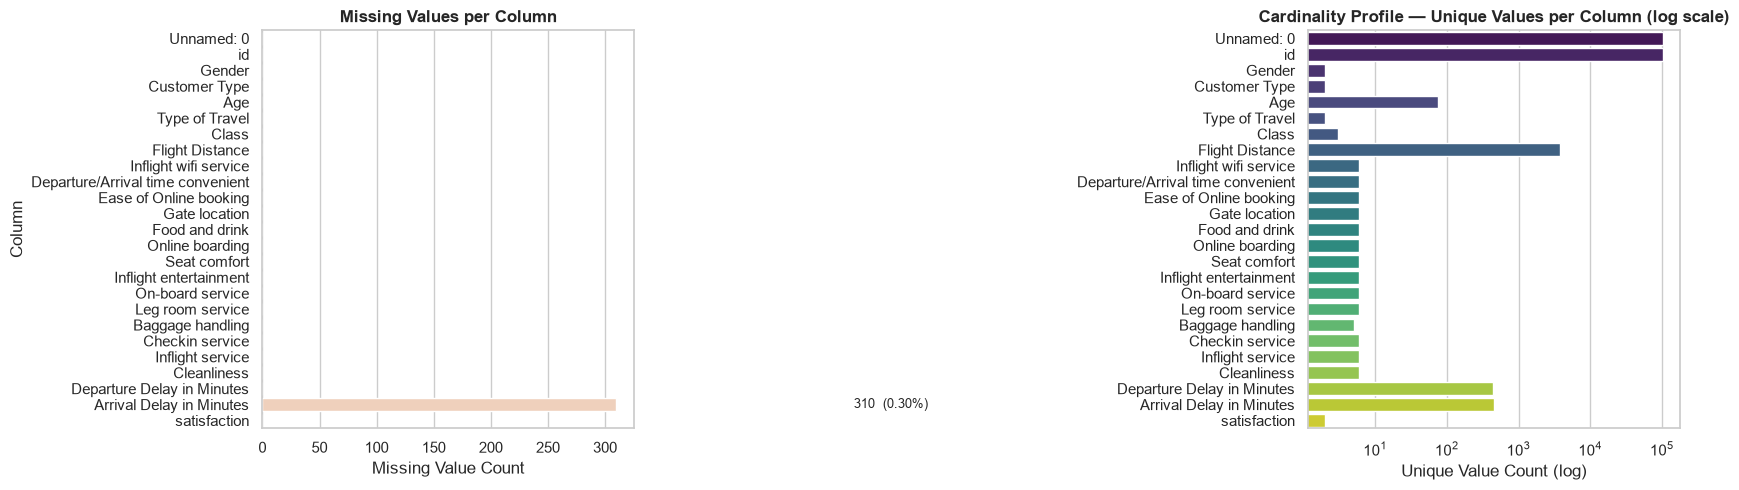

In [3]:
missing = df_raw.isnull().sum()
missing_cols = missing[missing > 0]
missing_pct = (missing_cols / len(df_raw) * 100).round(3)
duplicate_count = int(df_raw.duplicated().sum())
unique_counts = df_raw.nunique()
constant_cols = [c for c in df_raw.columns if df_raw[c].nunique() <= 1]
id_like_cols = [c for c in df_raw.columns if df_raw[c].nunique() == len(df_raw)]

print("=== SECTION 3: DATA QUALITY AUDIT ===")
if len(missing_cols) > 0:
    print("Columns containing missing values:")
    print(pd.DataFrame({"Missing Count": missing_cols, "Missing %": missing_pct}).to_string())
else:
    print("No missing values found.")

print(f"\nTotal missing cells       : {missing.sum():,} ({missing.sum() / df_raw.size * 100:.3f}% of all cells)")
print(f"Duplicate rows            : {duplicate_count}")
print(f"Constant (zero-variance)  : {constant_cols if constant_cols else 'none'}")
print(f"Row-unique (identifier)   : {id_like_cols}")
print(f"Columns excluding identifiers      : {df_raw.shape[1] - len(id_like_cols)} (of which 1 is the 'satisfaction' target)")
print(f"Columns to be modelled             : {df_raw.shape[1] - len(id_like_cols) - 1} (identifiers and target excluded)")

print("\nCardinality profile (unique values per column):")
print(unique_counts.sort_values().to_string())

# --- Audit visualisation: missing-value profile + cardinality profile ---
fig, axes = plt.subplots(1, 2, figsize=(17, 5))

sns.barplot(
    x=missing.values, y=missing.index, hue=missing.index,
    palette="rocket", legend=False, ax=axes[0]
)
axes[0].set_title("Missing Values per Column", fontweight="bold")
axes[0].set_xlabel("Missing Value Count")
axes[0].set_ylabel("Column")
for i, v in enumerate(missing.values):
    if v > 0:
        axes[0].text(v + len(df_raw) * 0.002, i, f"{v}  ({v / len(df_raw) * 100:.2f}%)", va="center", fontsize=9)

sns.barplot(
    x=unique_counts.values, y=unique_counts.index, hue=unique_counts.index,
    palette="viridis", legend=False, ax=axes[1]
)
axes[1].set_xscale("log")
axes[1].set_title("Cardinality Profile — Unique Values per Column (log scale)", fontweight="bold")
axes[1].set_xlabel("Unique Value Count (log)")
axes[1].set_ylabel("")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "data_quality_audit.png"), dpi=300, bbox_inches="tight")
plt.show()

### Data Quality Audit — Inference, Insight & Commentary

**Inference.** Exactly one column is incomplete: `Arrival Delay in Minutes` with **310 missing cells (0.298%** of the
dataset). There are **0 duplicate rows**, **no constant/zero-variance columns**, and precisely two row-unique
identifier columns (`Unnamed: 0`, `id`) that must be dropped. Cardinality splits cleanly into four groups: binary
nominal (2 values), multi-class nominal (`Class`, 3), bounded survey ratings (5–6 values), and high-cardinality
continuums (`Flight Distance` 3,802; `Departure Delay` 446; `Arrival Delay` 455).

**Insight.** With only 0.3% of cells missing, no row can be justified as undroppable to the contrary — but dropping
rows is still unnecessary: median imputation preserves **all 103,904 customers** for segmentation while introducing
negligible distortion. Crucially, `Arrival Delay in Minutes` is missing for a *specific* operational reason (legs that
were cancelled or never departed) rather than at random, which is worth flagging: imputed delays are a conservative
lower bound on disruption for those 310 passengers.

**Commentary.** The missing values are structural rather than informative, so the imputation strategy is kept
deliberately simple and isolated in one documented step (Section 6) instead of being spread across the pipeline. The
high-cardinality continuous columns confirm that a `StandardScaler` — not a categorical encoder — is the appropriate
treatment for them.

---
## 4. Section C — Feature Type Identification & Target Exclusion

With the data audited, we (a) remove identifier columns, (b) **exclude the supervised target** `satisfaction` from the
feature space (retained separately as an optional post-hoc label), and (c) classify every remaining feature by
measurement type, since the correct encoding treatment follows from the measurement scale itself.

In [4]:
df = df_raw.copy()

# --- (a) Remove index / identifier columns: they encode row ordering, not customer behaviour ---
id_cols = ["Unnamed: 0", "id"]
dropped_id_cols = [c for c in id_cols if c in df.columns]
df = df.drop(columns=dropped_id_cols)

# --- (b) Exclude the target label from the clustering feature matrix ---
TARGET_COL = "satisfaction"
if TARGET_COL in df.columns:
    y_optional = df.pop(TARGET_COL).copy()
else:
    y_optional = None

# --- (c) Classify the remaining features by measurement type ---
nominal_categorical_cols = ["Gender", "Customer Type", "Type of Travel", "Class"]
ordinal_survey_cols = [
    "Inflight wifi service", "Departure/Arrival time convenient", "Ease of Online booking",
    "Gate location", "Food and drink", "Online boarding", "Seat comfort",
    "Inflight entertainment", "On-board service", "Leg room service",
    "Baggage handling", "Checkin service", "Inflight service", "Cleanliness",
]
continuous_num_cols = ["Age", "Flight Distance", "Departure Delay in Minutes", "Arrival Delay in Minutes"]

print("=== SECTION 4: FEATURE TYPE IDENTIFICATION ===")
print(f"Dropped identifier columns            : {dropped_id_cols}")
print(f"Excluded target (post-hoc label only) : '{TARGET_COL}' -> {len(y_optional):,} labels retained")
print(f"Working feature table shape           : {df.shape}")
print(f"\nNominal categorical ({len(nominal_categorical_cols):2d}) : {nominal_categorical_cols}")
print(f"Ordinal survey 0-5  ({len(ordinal_survey_cols):2d}) : {ordinal_survey_cols}")
print(f"Continuous numeric  ({len(continuous_num_cols):2d}) : {continuous_num_cols}")
print(f"\nTotal features to be modelled         : {len(nominal_categorical_cols) + len(ordinal_survey_cols) + len(continuous_num_cols)}")

=== SECTION 4: FEATURE TYPE IDENTIFICATION ===
Dropped identifier columns            : ['Unnamed: 0', 'id']
Excluded target (post-hoc label only) : 'satisfaction' -> 103,904 labels retained
Working feature table shape           : (103904, 22)

Nominal categorical ( 4) : ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Ordinal survey 0-5  (14) : ['Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness']
Continuous numeric  ( 4) : ['Age', 'Flight Distance', 'Departure Delay in Minutes', 'Arrival Delay in Minutes']

Total features to be modelled         : 22


### Feature Typing — Inference, Insight & Commentary

**Inference.** After removing the two identifier columns, the 22 candidate features split into **4 nominal**
(`Gender`, `Customer Type`, `Type of Travel`, `Class`), **14 ordinal 0–5 survey ratings** and **4 continuous** numeric
variables. The 43.3% `/` 56.7% satisfaction split is retained as a label vector aligned row-for-row with the feature
table.

**Insight.** The three groups require three different treatments, and applying the wrong one is a common source of
silent clustering failure: (i) nominal variables have no order, so one-hot encoding is required — ordinal encoding
would falsely assert `Eco Plus > Eco`; (ii) the 14 ratings are *already* on a shared, interpretable 0–5 ordinal scale,
so they need no encoding at all; (iii) the 4 continuous variables have wildly different units (years, miles, minutes)
and must be standardised.

**Commentary.** `satisfaction` is explicitly **excluded** from the feature matrix. Had it been included, the clustering
would simply rediscover the supervised label (data leakage into an unsupervised task) and every downstream metric would
be inflated and meaningless. Keeping it in `y_optional` lets us perform a genuine *post-hoc* external validation in
Section 18: "do the clusters we discovered without the label happen to separate satisfied from dissatisfied
passengers?"

---
## 5. Section D — Exploratory Data Analysis (EDA)

Six diagnostic visualisations are produced, each followed by its own inference, insight and commentary:

1. **Target balance & nominal-category satisfaction profiles** — is the label degenerate, and which traveller attributes matter?
2. **Continuous feature distributions** (raw vs `log1p`) and **IQR outlier screening** — scale, skew and defect risk.
3. **The 14 ordinal service-rating distributions** split by satisfaction — the primary clustering signal.
4. **Service-rating satisfaction gaps** and the **feature correlation structure** — which dimensions discriminate, and which are redundant.

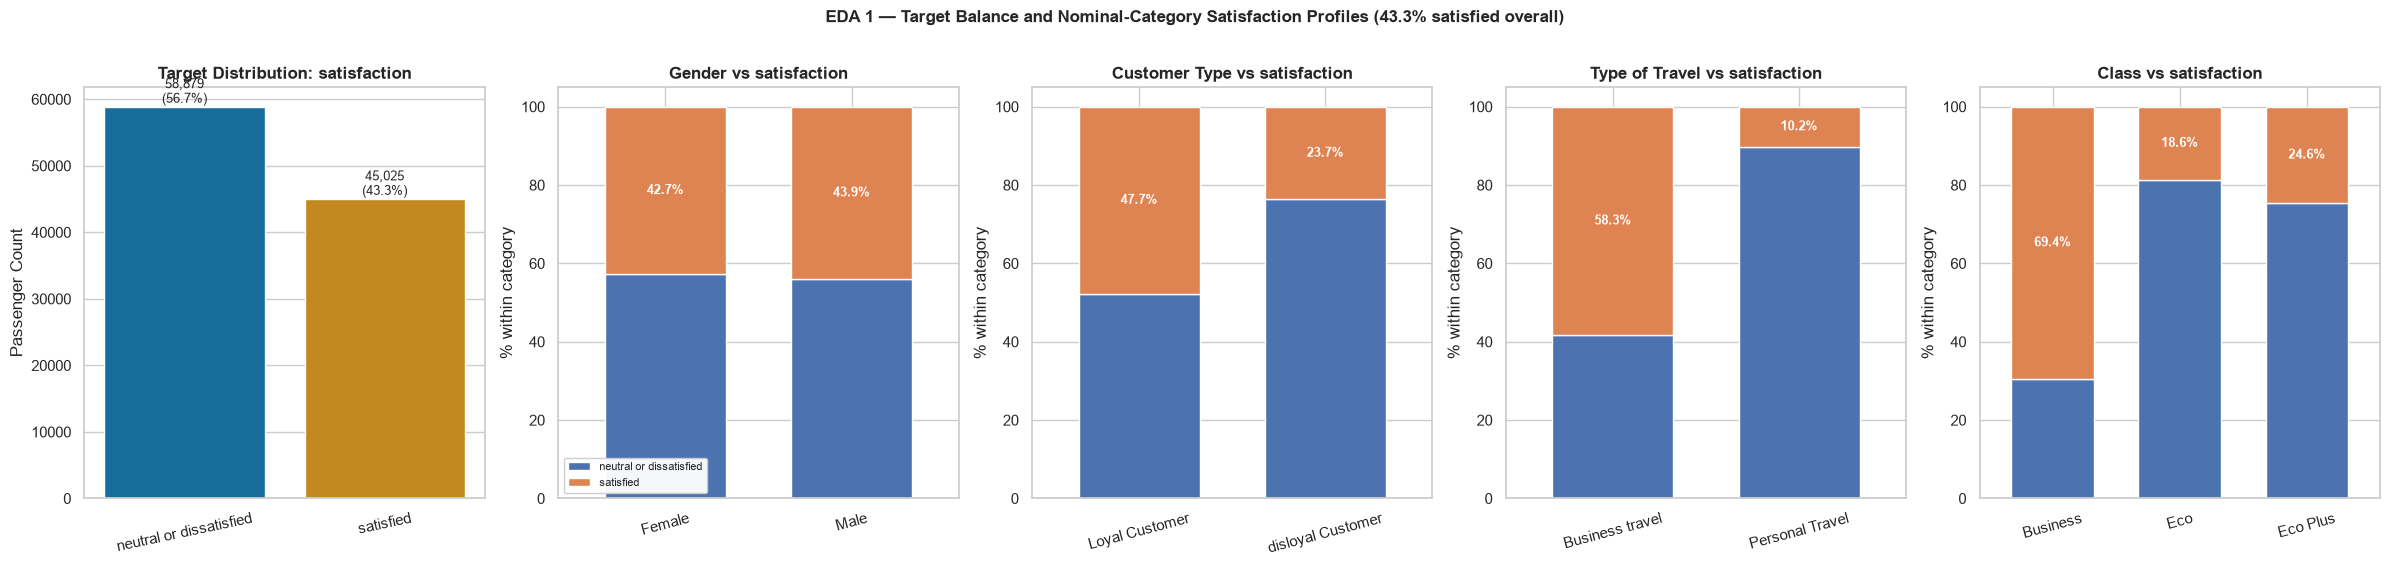

In [5]:
# =====================================================================================
# EDA FIGURE 1 - Target balance and nominal-category satisfaction profiles
# =====================================================================================
fig, axes = plt.subplots(1, 5, figsize=(24, 5.5))

# Panel 1: target class balance
sat_counts = y_optional.value_counts()
sns.barplot(x=sat_counts.index, y=sat_counts.values, hue=sat_counts.index,
            palette="colorblind", legend=False, ax=axes[0])
axes[0].set_title("Target Distribution: satisfaction", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Passenger Count")
axes[0].tick_params(axis="x", rotation=12)
for p, v in zip(axes[0].patches, sat_counts.values):
    axes[0].annotate(f"{v:,}\n({v / len(y_optional) * 100:.1f}%)",
                     (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=9)

# Panels 2-5: each nominal feature split by satisfaction (row-normalised)
for ax, col in zip(axes[1:], nominal_categorical_cols):
    ct = pd.crosstab(df[col], y_optional, normalize="index") * 100
    ct.plot(kind="bar", stacked=True, ax=ax, rot=15,
            color=["#4c72b0", "#dd8452"], legend=False, width=0.65)
    ax.set_title(f"{col} vs satisfaction", fontweight="bold")
    ax.set_xlabel("")
    ax.set_ylabel("% within category")
    for i, cat in enumerate(ct.index):
        r = ct.loc[cat, "satisfied"]
        ax.text(i, 100 - r / 2, f"{r:.1f}%", ha="center", va="center",
                fontsize=9, color="white", fontweight="bold")

axes[1].legend(["neutral or dissatisfied", "satisfied"], loc="lower left", fontsize=8, framealpha=0.95)
fig.suptitle("EDA 1 — Target Balance and Nominal-Category Satisfaction Profiles (43.3% satisfied overall)",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "target_and_categorical_profile.png"), dpi=300, bbox_inches="tight")
plt.show()

### EDA 1 — Inference, Insight & Commentary

**Inference.** The label is mildly imbalanced: **58,879 (56.7%) neutral-or-dissatisfied** versus **45,025 (43.3%)
satisfied** — a healthy split for evaluation, with no degenerate class. Satisfaction varies enormously with itinerary
context: **Business travel 58.3% satisfied vs Personal travel 10.2%**; **Business class 69.4% vs Eco 18.6%**
(Eco Plus 24.6%); **loyal customers 47.7% vs disloyal 23.7%**. `Gender` is essentially inert (Male 44.0% vs
Female 42.7% — a 1.2 pp difference).

**Insight.** The dominant satisfaction axis in this dataset is **itinerary context (travel purpose and cabin class),
not demographics**. Personal travellers in Economy are dissatisfied roughly 4-in-5 of the time, while the proportion
inverts for Business-class business travellers. A segmentation of this population must therefore be driven mainly by
the 14 service ratings and the travel descriptors; gender contributes almost no discriminative signal and can be
expected to load near-zero on the cluster profiles.

**Commentary.** These are *marginal*, one-variable views — they show association, not structure, and they say nothing
about how attributes combine. That is precisely why clustering is applied: to expose the **joint** structure of the
23-dimensional space (e.g. whether a coherent "premium business traveller" profile emerges independently of the
one-variable rankings above). Note also the class imbalance in `Class` (Business 49,665 / Eco 46,745 / Eco Plus 7,494):
one-hot encoding will produce a rare `Class_Eco Plus` dummy, which the scaling step must handle proportionately.

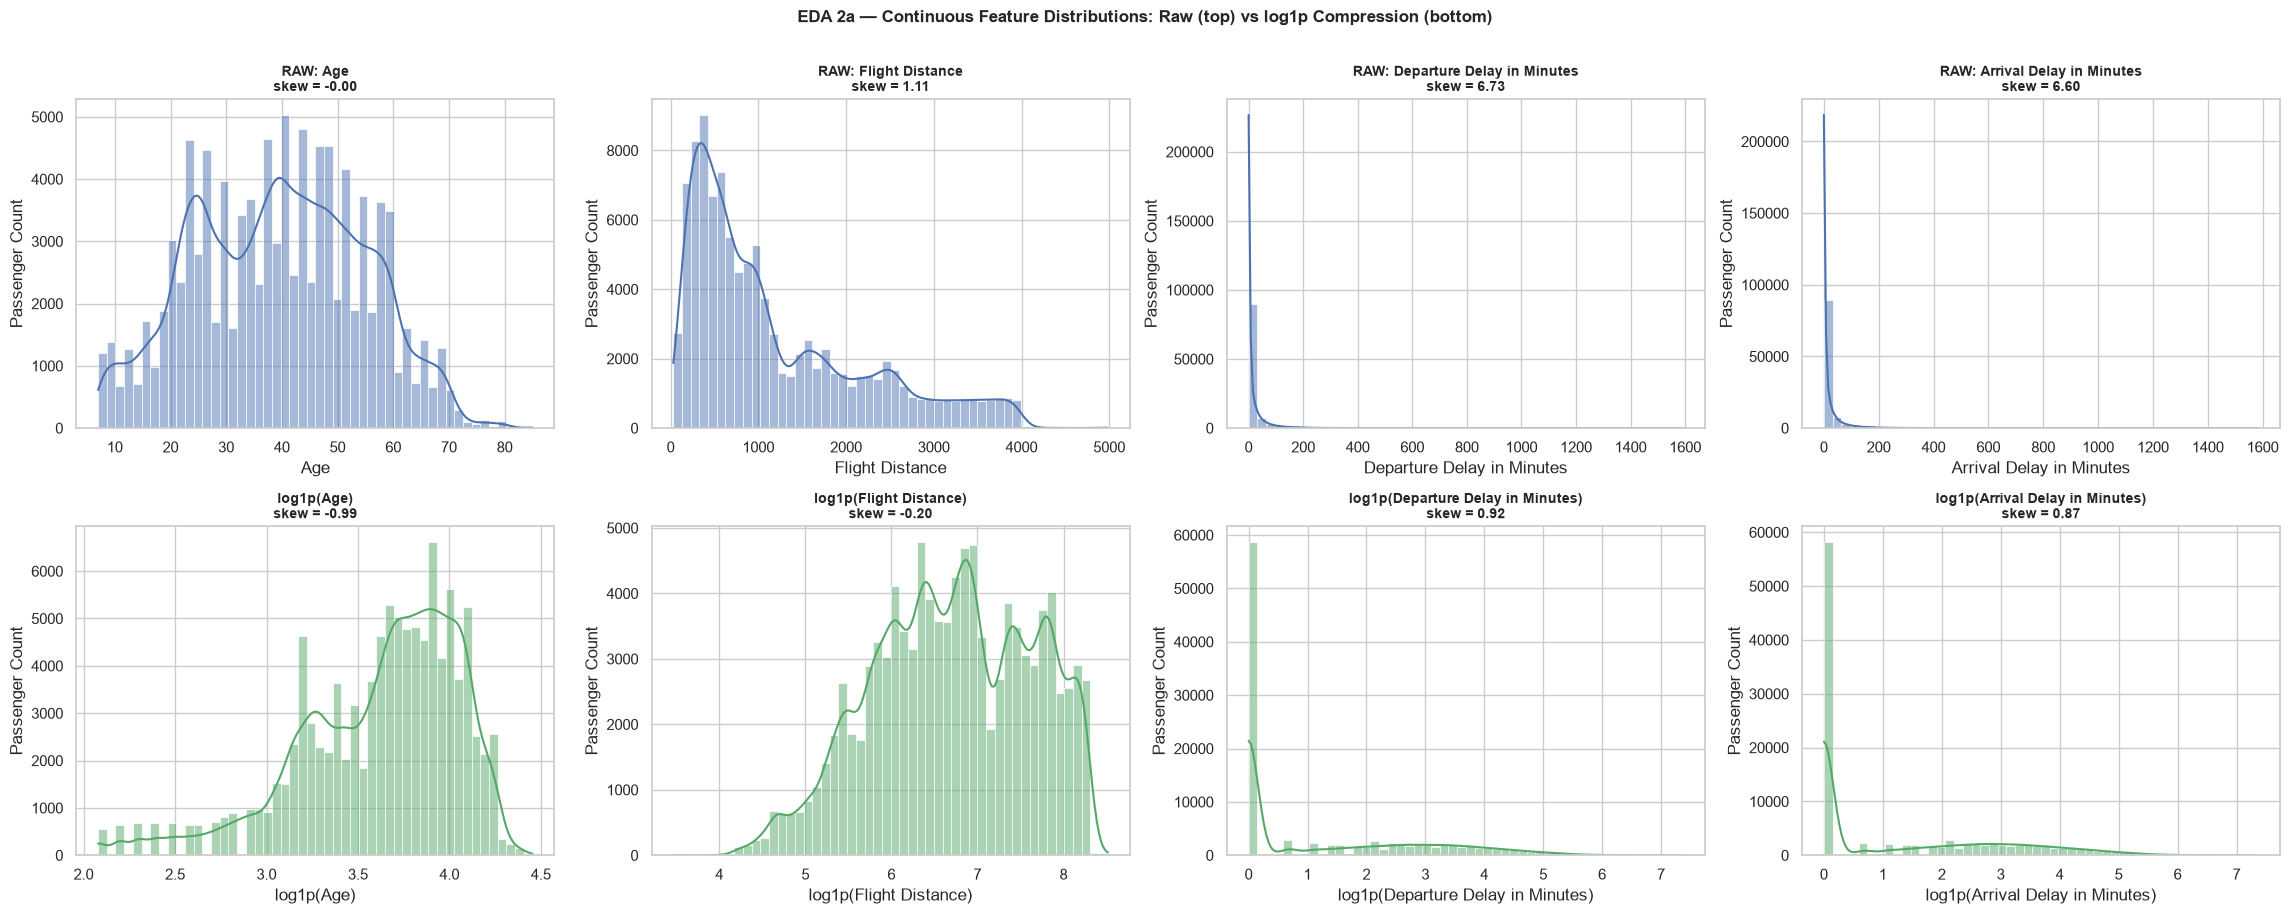

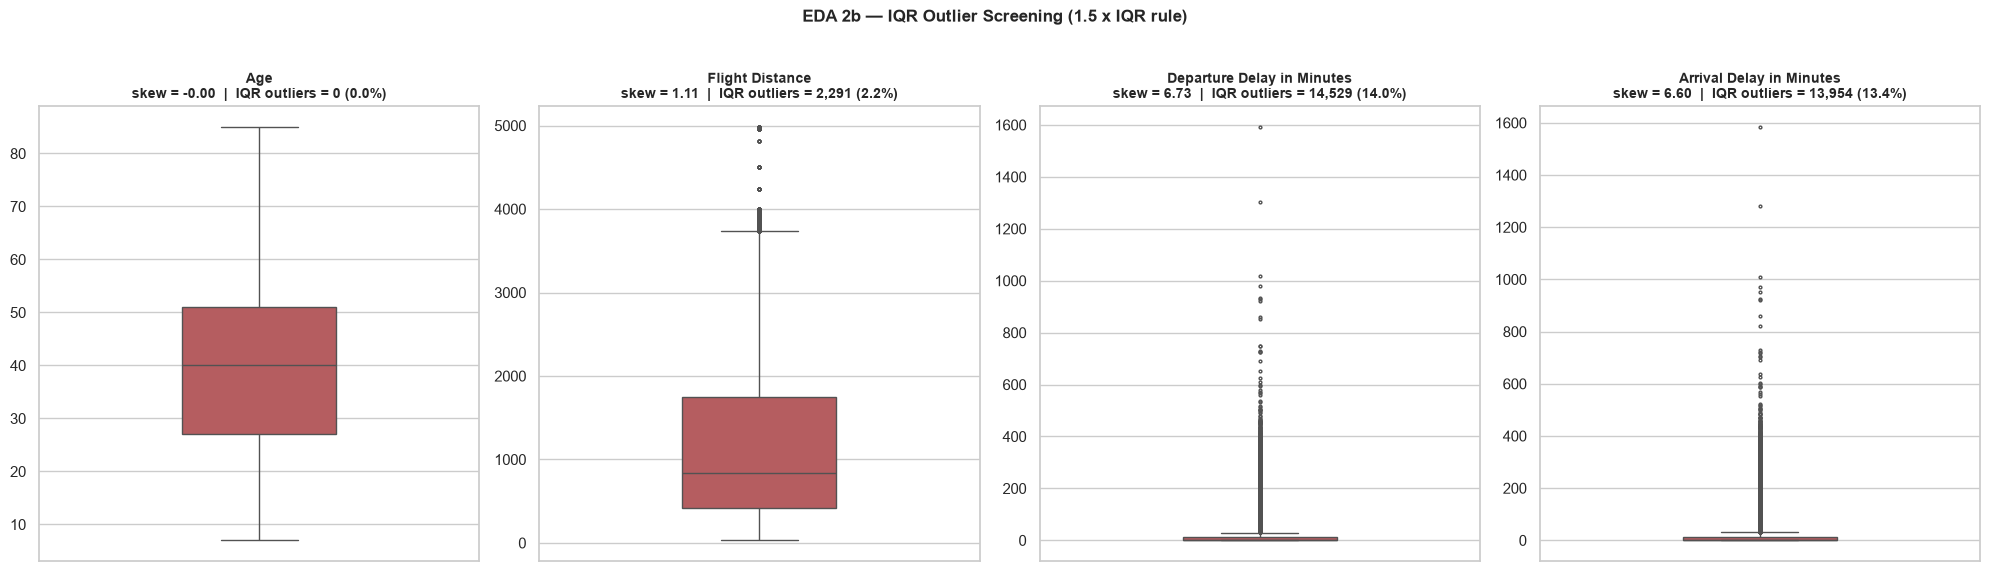

=== CONTINUOUS FEATURE DISTRIBUTION & OUTLIER SUMMARY ===


,Feature,Min,Median,Max,Skewness,IQR Outliers,Outlier %
0,Age,7.0,40.0,85.0,-0.00,0,0.00
1,Flight Distance,31.0,843.0,4983.0,1.11,2291,2.20
2,Departure Delay in Minutes,0.0,0.0,1592.0,6.73,14529,13.98
3,Arrival Delay in Minutes,0.0,0.0,1584.0,6.60,13954,13.43


In [6]:
# =====================================================================================
# EDA FIGURE 2 - Continuous feature distributions (raw vs log1p compressed)
# =====================================================================================
fig, axes = plt.subplots(2, 4, figsize=(23, 9))

for ax, col in zip(axes[0], continuous_num_cols):
    sns.histplot(df[col].dropna(), bins=50, kde=True, color="#4c72b0", ax=ax)
    ax.set_title(f"RAW: {col}\nskew = {df[col].skew():.2f}", fontweight="bold", fontsize=10)
    ax.set_xlabel(col)
    ax.set_ylabel("Passenger Count")

for ax, col in zip(axes[1], continuous_num_cols):
    sns.histplot(np.log1p(df[col].dropna()), bins=50, kde=True, color="#55a868", ax=ax)
    ax.set_title(f"log1p({col})\nskew = {np.log1p(df[col]).skew():.2f}", fontweight="bold", fontsize=10)
    ax.set_xlabel(f"log1p({col})")
    ax.set_ylabel("Passenger Count")

fig.suptitle("EDA 2a — Continuous Feature Distributions: Raw (top) vs log1p Compression (bottom)",
             fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "numerical_feature_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

# =====================================================================================
# EDA FIGURE 3 - IQR outlier screening on the continuous features
# =====================================================================================
fig, axes = plt.subplots(1, 4, figsize=(20, 5.5))
for ax, col in zip(axes, continuous_num_cols):
    sns.boxplot(y=df[col].dropna(), ax=ax, color="#c44e52", width=0.35, fliersize=2)
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    ax.set_title(f"{col}\nskew = {df[col].skew():.2f}  |  IQR outliers = {n_out:,} ({n_out / len(df) * 100:.1f}%)",
                 fontweight="bold", fontsize=10)
    ax.set_ylabel("")

fig.suptitle("EDA 2b — IQR Outlier Screening (1.5 x IQR rule)", fontweight="bold", y=1.03)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "delay_outlier_boxplots.png"), dpi=300, bbox_inches="tight")
plt.show()

# IQR outlier summary table
outlier_rows = []
for col in continuous_num_cols:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    n_out = int(((df[col] < q1 - 1.5 * iqr) | (df[col] > q3 + 1.5 * iqr)).sum())
    outlier_rows.append({
        "Feature": col, "Min": df[col].min(), "Median": df[col].median(), "Max": df[col].max(),
        "Skewness": round(df[col].skew(), 2), "IQR Outliers": n_out,
        "Outlier %": round(n_out / len(df) * 100, 2),
    })
print("=== CONTINUOUS FEATURE DISTRIBUTION & OUTLIER SUMMARY ===")
display(pd.DataFrame(outlier_rows))

### EDA 2 — Inference, Insight & Commentary

**Inference.** `Age` is near-symmetric (skew 0.00, range 7–85, median 40). `Flight Distance` is right-skewed
(skew 1.11, 31–4,983 miles, median 843). Both delay variables are **extremely** right-skewed (skew 6.73 departure /
6.60 arrival; median 0 minutes; maxima 1,592 and 1,584 minutes): more than half of all flights depart perfectly on
time, and a long thin tail carries the disruption. IQR screening flags **13.98%** of records on departure delay,
**13.43%** on arrival delay, **2.20%** on flight distance and **0%** on age. `log1p` compresses the delay skew from
6.73 → 0.92 and 6.60 → 0.88, and flight distance from 1.11 → −0.20.

**Insight.** The "outliers" are **not data-entry errors** — they are genuine long-haul and severely delayed flights
with values that are extreme but physically valid. Deleting the ~14% of passengers flagged on delays would
systematically strip out the most disrupted customers, biasing the segmentation towards on-time travel and destroying
the very segment that is most operationally interesting. Meanwhile, leaving the raw tail in place would let a single
1,592-minute delay dominate the Euclidean distance metric. There is also a redundancy signal here: departure and
arrival delay correlate at **r = 0.966**, i.e. they largely encode the same disruption.

**Commentary.** **Decision: retain every outlier record and compress the tails instead of trimming them.** `log1p` is
monotone, so it preserves the ordering of every observation while bringing skew below the conventional |1.0| threshold —
which keeps the geometry well-behaved for centroid-based clustering without discarding a single customer. This mirrors
the Regression track's treatment of the long-tailed `critical_temp` target. Both delay columns are retained (rather
than de-duplicating the pair) because they measure distinct legs of the journey, and the redundancy is flagged for the
PCA interpretation in Section 19.

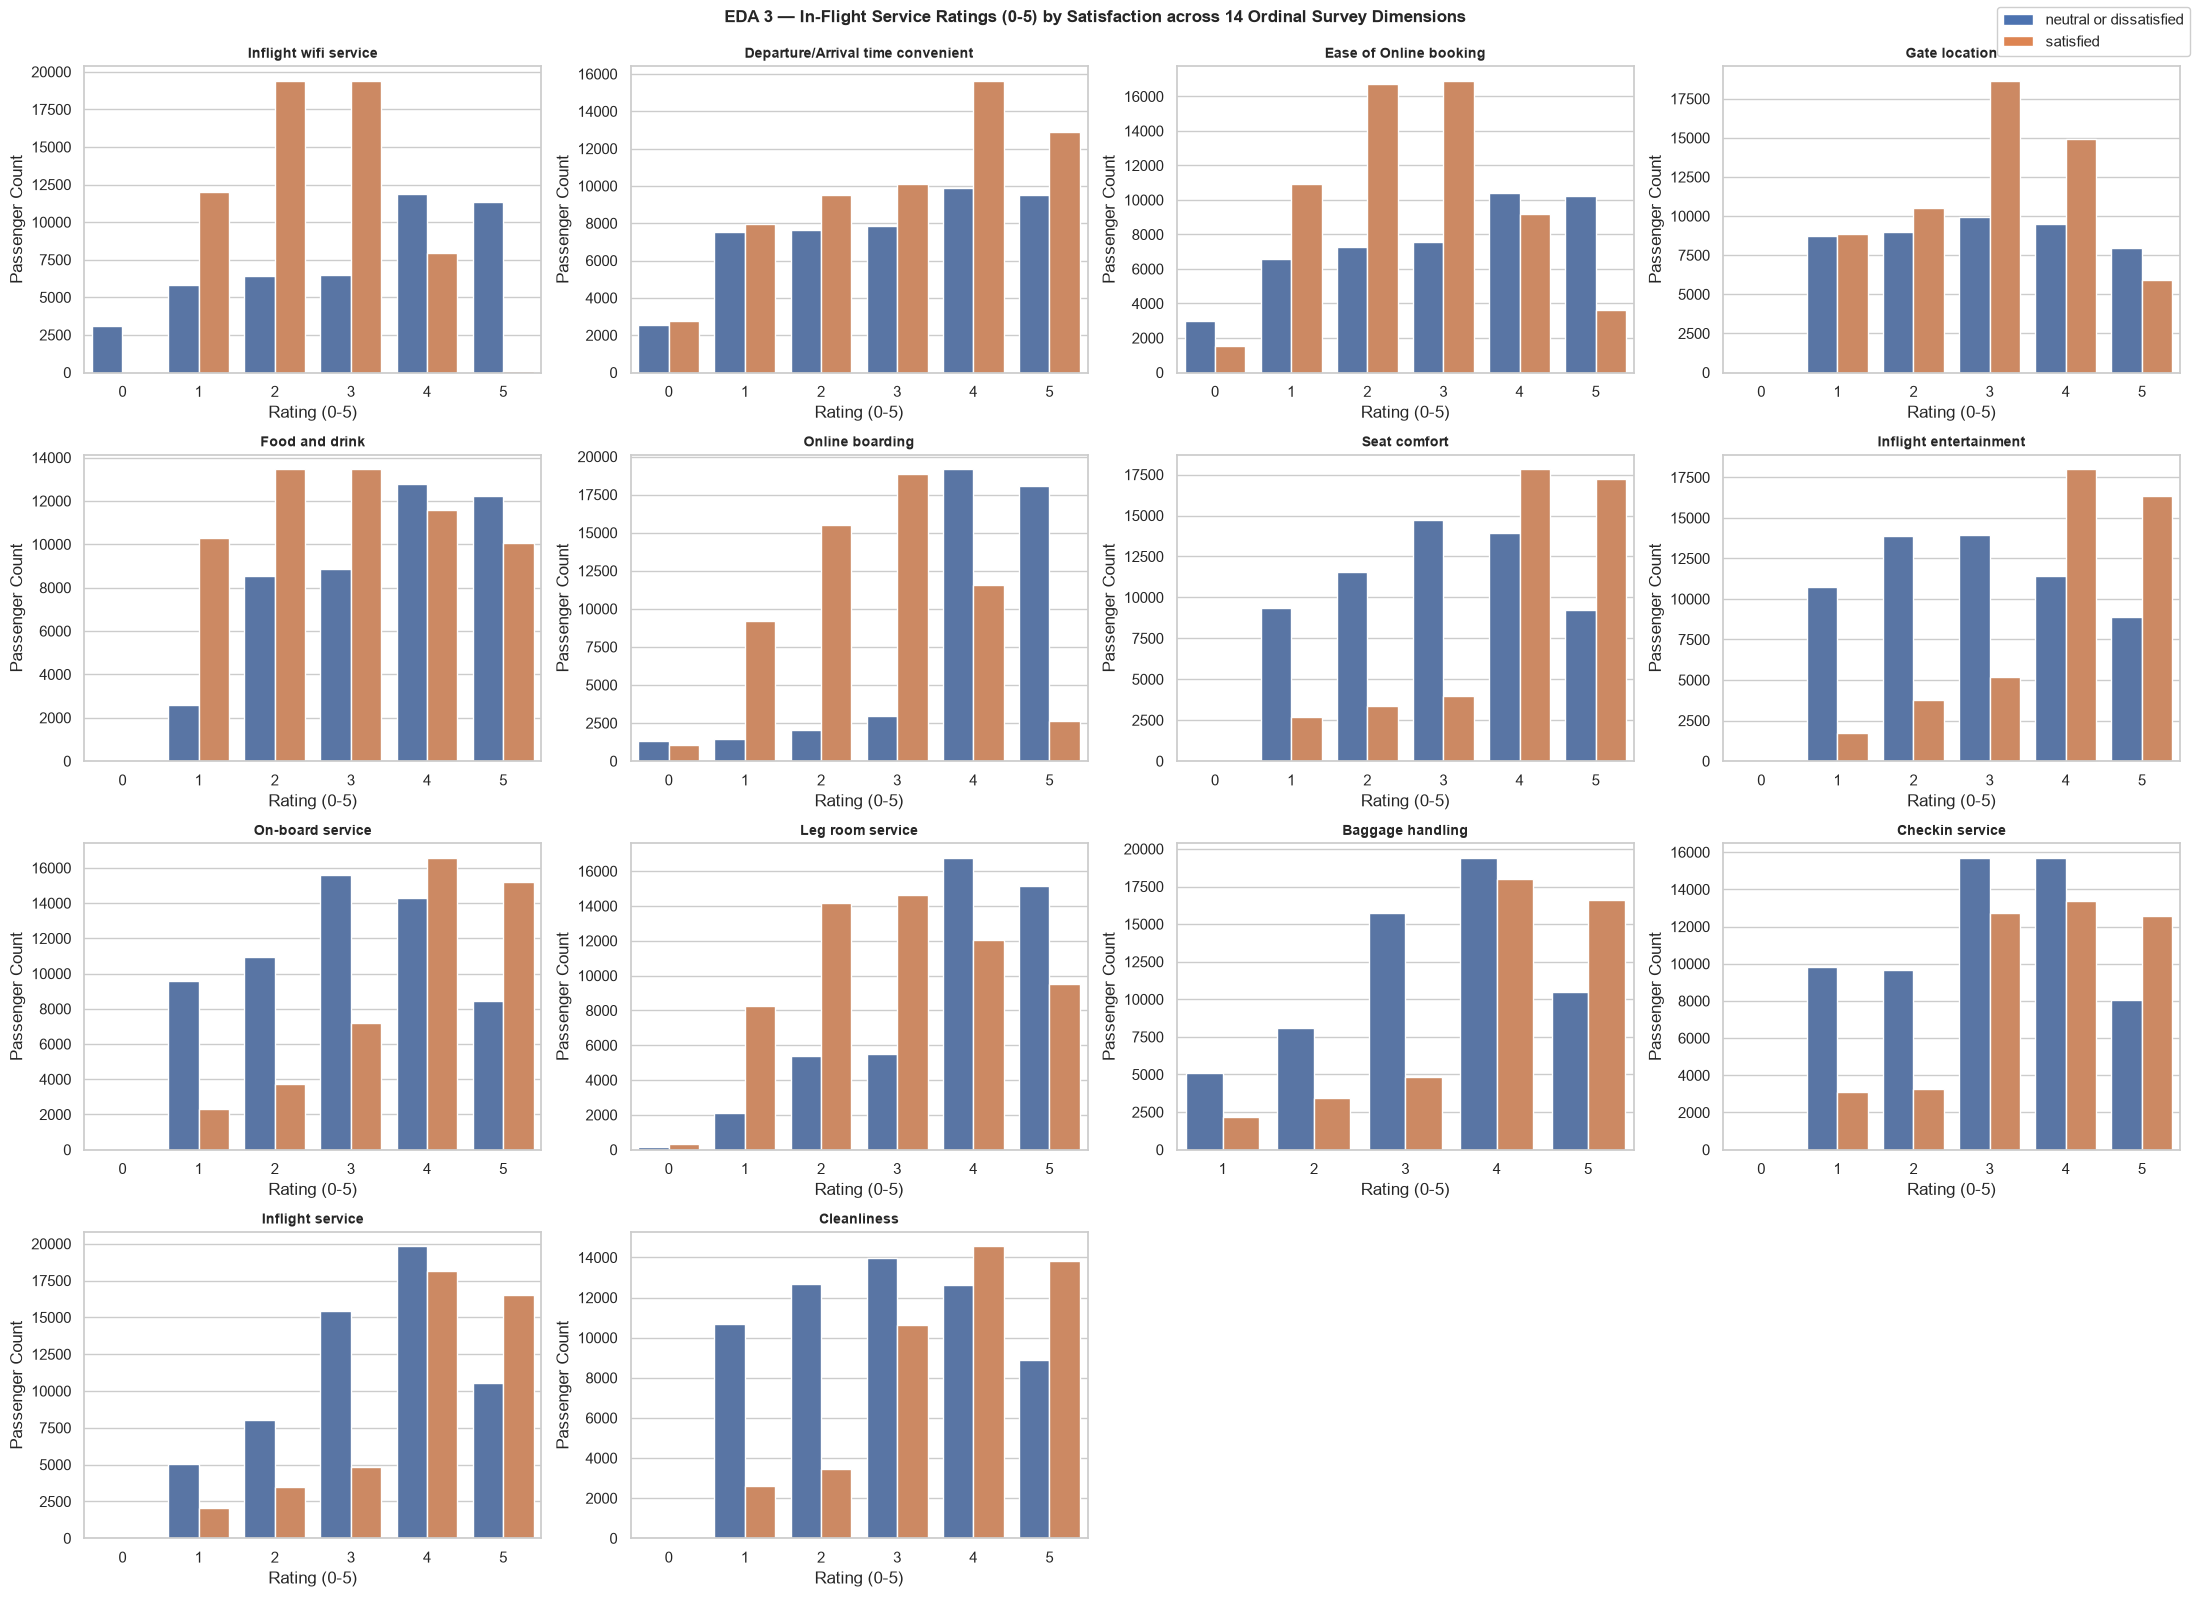

=== SHARE OF PASSENGERS RATING EACH SERVICE DIMENSION <= 2 ===
Inflight wifi service                45.0
Ease of Online booking               44.3
Departure/Arrival time convenient    36.6
Gate location                        35.6
Food and drink                       33.6
Online boarding                      29.5
Leg room service                     29.2
Inflight entertainment               29.0
Cleanliness                          28.4
Seat comfort                         26.0
On-board service                     25.6
Checkin service                      24.8
Baggage handling                     18.1
Inflight service                     17.8


In [7]:
# =====================================================================================
# EDA FIGURE 4 - The 14 ordinal service-rating distributions, split by satisfaction
# =====================================================================================
fig, axes = plt.subplots(4, 4, figsize=(22, 16))
for ax, col in zip(axes.flatten(), ordinal_survey_cols):
    sns.countplot(data=df, x=col, hue=y_optional, palette=["#4c72b0", "#dd8452"], ax=ax)
    ax.set_title(col, fontweight="bold", fontsize=10)
    ax.set_xlabel("Rating (0-5)")
    ax.set_ylabel("Passenger Count")
    if ax.get_legend() is not None:
        ax.get_legend().remove()
for ax in axes.flatten()[len(ordinal_survey_cols):]:
    ax.axis("off")

fig.legend(handles=[Patch(facecolor="#4c72b0", label="neutral or dissatisfied"),
                    Patch(facecolor="#dd8452", label="satisfied")],
           loc="upper right", fontsize=11, framealpha=0.95)
fig.suptitle("EDA 3 — In-Flight Service Ratings (0-5) by Satisfaction across 14 Ordinal Survey Dimensions",
             fontweight="bold", y=0.995)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "service_rating_distributions.png"), dpi=300, bbox_inches="tight")
plt.show()

# Low-rating (<=2) share per service dimension
low_rating = (df[ordinal_survey_cols] <= 2).mean().mul(100).round(1).sort_values(ascending=False)
print("=== SHARE OF PASSENGERS RATING EACH SERVICE DIMENSION <= 2 ===")
print(low_rating.to_string())

### EDA 3 — Inference, Insight & Commentary

**Inference.** Every one of the 14 service dimensions is **multi-modal and heavily massed at the top of the scale for
satisfied passengers**, while dissatisfied passengers spread across the 0–3 range with pronounced low-end spikes. The
worst-rated dimensions are `Inflight wifi service` (**45.0%** of passengers rate it ≤ 2) and `Ease of Online booking`
(44.3%), ahead of `Departure/Arrival time convenient` (36.6%), `Gate location` (35.6%) and `Food and drink` (33.6%).
The best-rated are `Inflight service` (17.8% ≤ 2) and `Baggage handling` (18.1%).

**Insight.** The rating distributions are **discrete, bounded and multimodal — not Gaussian**. This is an important
assumption audit for K-Means, which implicitly assumes roughly spherical, similar-variance clusters: on this kind of
bounded ordinal data, clusters are expected to be weakly separated blobs rather than clean islands. Practical
implication — **silhouette scores should be interpreted on a different scale here**: modest values (< 0.2) are
expected and normal, and the meaningful question is not "is silhouette high in absolute terms?" but "which `k`
maximises it, and does the resulting partition stay stable and interpretable when a second and third criterion
(Davies-Bouldin, Calinski-Harabasz) are consulted?" This expectation is stated here, *before* the metrics are computed,
to avoid post-hoc rationalisation in Part II.

**Commentary.** Because all 14 dimensions share an identical 0–5 scale, they enter the distance metric with comparable
weight once standardised — no rescaling or re-weighting is needed. The scale homogeneity also means no single service
dimension can dominate the geometry by construction, unlike the continuous columns.

=== SECTION 5: MEAN SERVICE RATING BY SATISFACTION LABEL (0-5 SCALE) ===


satisfaction,neutral or dissatisfied,satisfied,Gap (satisfied - dissatisfied)
Online boarding,2.656,4.027,1.371
Inflight entertainment,2.894,3.965,1.071
Seat comfort,3.036,3.967,0.930
On-board service,3.019,3.857,0.838
Leg room service,2.991,3.822,0.831
Cleanliness,2.936,3.744,0.808
Inflight wifi service,2.400,3.161,0.762
Checkin service,3.043,3.646,0.603
Baggage handling,3.376,3.966,0.590
Inflight service,3.389,3.969,0.581


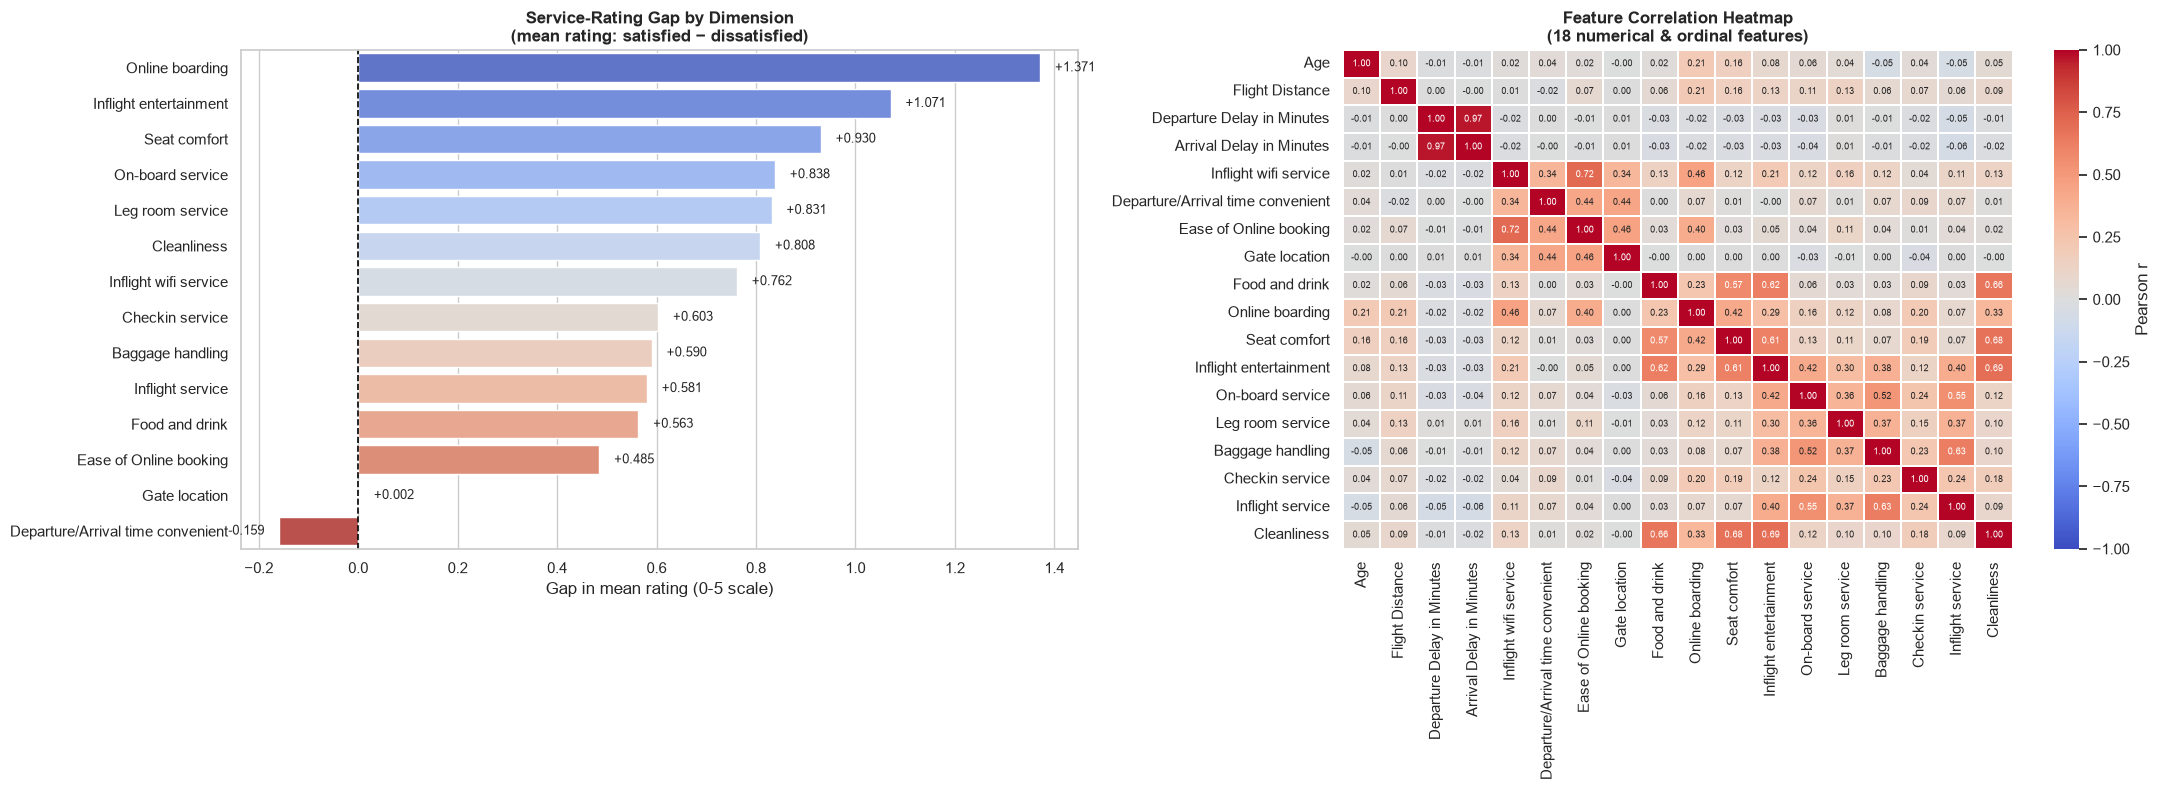


=== STRONGEST FEATURE CORRELATIONS (|r|) ===
Arrival Delay in Minutes  Departure Delay in Minutes    0.9655
Inflight wifi service     Ease of Online booking        0.7159
Inflight entertainment    Cleanliness                   0.6918
Cleanliness               Seat comfort                  0.6785
Food and drink            Cleanliness                   0.6578
Baggage handling          Inflight service              0.6286


In [8]:
# =====================================================================================
# EDA FIGURE 5 - Service-rating satisfaction gap  +  feature correlation structure
# =====================================================================================
ratings_by_label = df[ordinal_survey_cols].assign(satisfaction=y_optional).groupby("satisfaction").mean().T
ratings_by_label["Gap (satisfied - dissatisfied)"] = (
    ratings_by_label["satisfied"] - ratings_by_label["neutral or dissatisfied"]
)
ratings_by_label = ratings_by_label.sort_values("Gap (satisfied - dissatisfied)", ascending=False)

print("=== SECTION 5: MEAN SERVICE RATING BY SATISFACTION LABEL (0-5 SCALE) ===")
display(ratings_by_label.round(3))

fig, axes = plt.subplots(1, 2, figsize=(22, 8))

sns.barplot(x=ratings_by_label["Gap (satisfied - dissatisfied)"], y=ratings_by_label.index,
            hue=ratings_by_label.index, palette="coolwarm", legend=False, ax=axes[0])
axes[0].axvline(0, color="black", linestyle="--", linewidth=1.2)
axes[0].set_title("Service-Rating Gap by Dimension\n(mean rating: satisfied − dissatisfied)",
                  fontweight="bold")
axes[0].set_xlabel("Gap in mean rating (0-5 scale)")
axes[0].set_ylabel("")
for i, v in enumerate(ratings_by_label["Gap (satisfied - dissatisfied)"].values):
    axes[0].text(v + (0.03 if v >= 0 else -0.03), i, f"{v:+.3f}",
                 va="center", ha="left" if v >= 0 else "right", fontsize=9)

corr_features = continuous_num_cols + ordinal_survey_cols
corr_matrix_eda = df[corr_features].corr()
sns.heatmap(corr_matrix_eda, cmap="coolwarm", center=0, vmin=-1, vmax=1, annot=True, fmt=".2f",
            annot_kws={"size": 6.5}, ax=axes[1], cbar_kws={"label": "Pearson r"}, linewidths=0.3)
axes[1].set_title("Feature Correlation Heatmap\n(18 numerical & ordinal features)", fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_correlation_heatmap.png"), dpi=300, bbox_inches="tight")
plt.show()

# Strongest correlation pairs (excluding self-correlation)
corr_abs = corr_matrix_eda.abs().to_numpy(copy=True)
np.fill_diagonal(corr_abs, 0)
corr_pairs = (pd.DataFrame(corr_abs, index=corr_features, columns=corr_features)
              .unstack().sort_values(ascending=False).drop_duplicates())
print("\n=== STRONGEST FEATURE CORRELATIONS (|r|) ===")
print(corr_pairs.head(6).round(4).to_string())

### EDA 4 — Inference, Insight & Commentary

**Inference.** Ranked by the satisfied-minus-dissatisfied rating gap, `Online boarding` (**+1.371**) and
`Inflight entertainment` (**+1.071**) separate the two groups most sharply, followed by `Seat comfort` (+0.930),
`On-board service` (+0.838), `Leg room service` (+0.831), `Cleanliness` (+0.808) and `Inflight wifi service` (+0.762).
At the other end, `Gate location` is effectively inert (**+0.002**) and `Departure/Arrival time convenient` is
*negatively* associated (**−0.159**). In the correlation matrix the only strong pair is the delay redundancy already
identified (`r = 0.966`); the strongest *non-delay* pair is `Inflight wifi service` ↔ `Ease of Online booking`
(r = 0.716), followed by `Inflight entertainment` ↔ `Cleanliness` (r = 0.692).

**Insight.** A small subset of service dimensions carries almost all of the separable satisfaction signal. Two
consequences: (i) the discriminating clusters should be defined predominantly by boarding, entertainment, seat comfort
and the onboard/legroom dimensions, with `Gate location` loading near-zero; (ii) "convenient" departure/arrival times
do **not** buy satisfaction — that dimension behaves like a hygiene factor. The moderate wifi/online-booking and
entertainment/cleanliness correlations mean those dimensions will partially double-count in the distance metric, which
is the second reason (after the delays) to inspect a PCA projection of the cluster structure in Section 19.

**Commentary.** Nothing in the correlation structure is strong enough to justify a feature-deletion step (all non-delay
pairs are |r| < 0.72, comfortably below the |r| > 0.95 collinearity threshold used in the Regression track), so all 23
encoded features are carried forward to clustering. This section completes the EDA: **six figures, each with a
documented inference, insight and commentary**. The findings directly prescribe the cleaning, transformation and
scaling steps that follow — and they pre-register the expectation that silhouette values on this data will be modest.

---
## 6. Section E — Data Cleaning

Three cleaning operations are applied, each traceable to a specific audit finding in Section 3:

1. **De-duplication** — exact duplicate rows would double-weight identical customers.
2. **Median imputation** of the 310 missing `Arrival Delay in Minutes` cells.
3. **Identifier/target removal** — completed in Section 4 (audited again in the final validation in Section 10).

In [9]:
print("=== SECTION 6: DATA CLEANING ===")

# --- (1) De-duplication ---------------------------------------------------------------
rows_before = len(df)
dup_mask = df.duplicated()
print(f"Duplicate rows detected : {int(dup_mask.sum())}")
if dup_mask.any():
    df = df.loc[~dup_mask].reset_index(drop=True)
    y_optional = y_optional.loc[~dup_mask].reset_index(drop=True)
    print(f"Dropped {rows_before - len(df)} duplicate rows -> {len(df):,} rows remain")
else:
    print("No duplicate rows: dataset kept intact (no rows dropped).")

# --- (2) Missing value imputation -----------------------------------------------------
missing_before = df.isnull().sum()
missing_before = missing_before[missing_before > 0]
print(f"\nMissing cells before imputation:")
print(pd.DataFrame({"Missing Count": missing_before,
                    "Missing %": (missing_before / len(df) * 100).round(3)}).to_string())

# Median is chosen over mean: delay distributions are severely right-skewed (skew ~6.7)
# and the median (0.0 min) is robust to the 1,500-minute tail, whereas the mean (15.18 min)
# would systematically overstate the delay experienced by the 310 affected passengers.
median_arrival_delay = df["Arrival Delay in Minutes"].median()
mean_arrival_delay = df["Arrival Delay in Minutes"].mean()   # measured BEFORE imputation
df["Arrival Delay in Minutes"] = df["Arrival Delay in Minutes"].fillna(median_arrival_delay)

print(f"\nImputation strategy                : median of 'Arrival Delay in Minutes' = {median_arrival_delay:.1f} minutes")
print(f"Mean of the column (pre-imputation) : {mean_arrival_delay:.2f} minutes (rejected as imputation value)")
print(f"Cells imputed       : {int(missing_before['Arrival Delay in Minutes'])} "
      f"({missing_before['Arrival Delay in Minutes'] / len(df) * 100:.3f}% of rows)")

remaining_missing = df.isnull().sum().sum()
assert remaining_missing == 0, f"Error: {remaining_missing} missing values remain after imputation."
print(f"\nVerification: remaining missing cells = {remaining_missing}  ->  cleaning PASSED")
print(f"Final working shape: {df.shape}")

=== SECTION 6: DATA CLEANING ===
Duplicate rows detected : 0
No duplicate rows: dataset kept intact (no rows dropped).



Missing cells before imputation:
                          Missing Count  Missing %
Arrival Delay in Minutes            310      0.298



Imputation strategy                : median of 'Arrival Delay in Minutes' = 0.0 minutes
Mean of the column (pre-imputation) : 15.18 minutes (rejected as imputation value)
Cells imputed       : 310 (0.298% of rows)

Verification: remaining missing cells = 0  ->  cleaning PASSED
Final working shape: (103904, 22)


### Cleaning — Inference, Insight & Commentary

**Inference.** The dataset contains **0 duplicate rows**, so the de-duplication step is a verified no-op — nothing is
dropped and all 103,904 customers are retained. The only cleaning action with a material effect is median imputation of
the 310 missing `Arrival Delay in Minutes` values (**0.298%** of rows) with the column median of **0.0 minutes**
(the column mean of 15.18 minutes was rejected). Post-cleaning verification reports **zero** remaining missing cells.

**Insight.** Median imputation is the correct choice here precisely *because* of the skew diagnosed in EDA 2: with a
distribution whose mean sits 15 minutes above its median and whose tail reaches 1,584 minutes, imputing the mean would
inject a systematic 15-minute delay into 310 passengers who, by their own departure timing, most plausibly experienced
none. Using the median keeps those records on-time and therefore keeps them interpretable as ordinary customers
rather than manufacturing artificial "delayed traveller" records that would distort the delay features.

**Commentary.** Cleaning is deliberately minimal and entirely defect-driven: no outlier rows are removed (justified in
EDA 2 and handled by `log1p` in Section 7), no rows are dropped for missingness, and no feature is dropped for
cardinality. The resulting matrix is a faithful, full-population representation of the customer base — an important
property for customer segmentation, where silently discarding 14% of the population would make the segments
unrepresentative of the actual traveller mix.

---
## 7. Section F — Skewness & Outlier Treatment (Transformations)

The EDA flagged severe right-skew in the delay and distance features. Rather than deleting high-delay passengers, we
apply a monotone `log1p` compression to every feature whose skewness exceeds the **|1.0|** convention, and record the
before/after skew so the transformation is auditable rather than assumed.

=== SECTION 7: SKEWNESS ANALYSIS & TRANSFORMATION ===
=== TRANSFORMATION SUMMARY ===


,Feature,Skewness Before,Transformation,Skewness After,Reason
0,Age,-0.00,None,-0.00,Unskewed / moderately skewed (skew = -0.00 <= ...
1,Flight Distance,1.11,log1p,-0.20,Right-skewed (skew = 1.11 > 1.0): compress lon...
2,Departure Delay in Minutes,6.73,log1p,0.92,Right-skewed (skew = 6.73 > 1.0): compress lon...
3,Arrival Delay in Minutes,6.61,log1p,0.88,Right-skewed (skew = 6.61 > 1.0): compress lon...


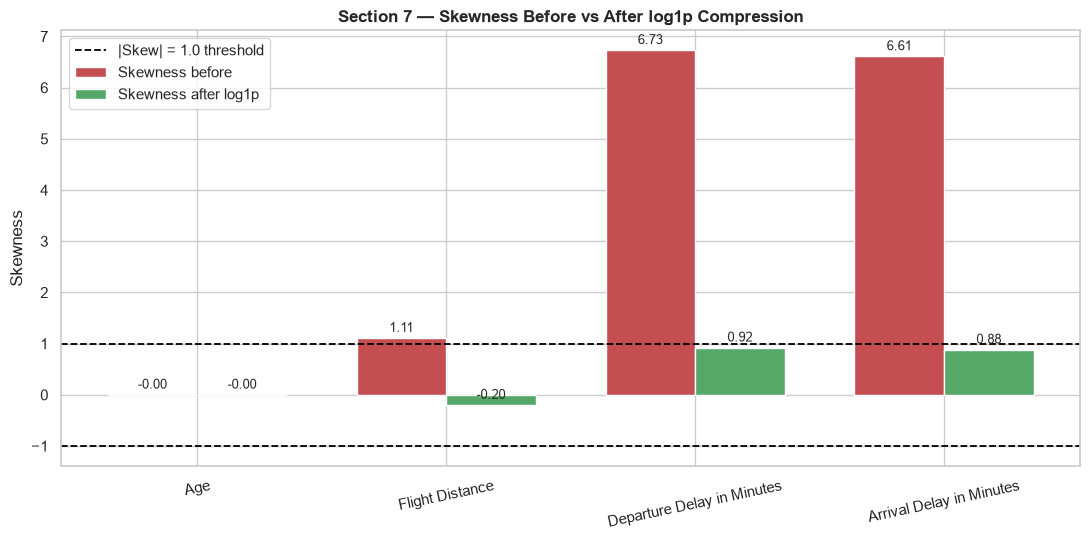


=== POST-TRANSFORMATION FEATURE SUMMARY ===


,count,mean,std,min,25%,50%,75%,max
Age,103904.0,39.380,15.115,7.000,27.000,40.000,51.000,85.000
Flight Distance,103904.0,6.706,0.916,3.466,6.028,6.738,7.464,8.514
Departure Delay in Minutes,103904.0,1.236,1.620,0.000,0.000,0.000,2.565,7.373
Arrival Delay in Minutes,103904.0,1.261,1.630,0.000,0.000,0.000,2.639,7.368


In [10]:
print("=== SECTION 7: SKEWNESS ANALYSIS & TRANSFORMATION ===")

# Measure skewness and decide treatment per continuous feature
transformation_rows = []
for col in continuous_num_cols:
    skew_before = df[col].skew()
    if skew_before > 1.0:
        action = "log1p"
        reason = f"Right-skewed (skew = {skew_before:.2f} > 1.0): compress long tail, retain all rows"
    else:
        action = "None"
        reason = f"Unskewed / moderately skewed (skew = {skew_before:.2f} <= 1.0): leave unchanged"
    transformation_rows.append({
        "Feature": col,
        "Skewness Before": round(skew_before, 2),
        "Transformation": action,
        "Reason": reason,
    })

transformation_summary = pd.DataFrame(transformation_rows)

# Apply the transformations
for row in transformation_rows:
    if row["Transformation"] == "log1p":
        df[row["Feature"]] = np.log1p(df[row["Feature"]])

transformation_summary["Skewness After"] = transformation_summary["Feature"].apply(lambda c: round(df[c].skew(), 2))
print("=== TRANSFORMATION SUMMARY ===")
display(transformation_summary[["Feature", "Skewness Before", "Transformation", "Skewness After", "Reason"]])

# Before/after skew comparison
fig, ax = plt.subplots(figsize=(11, 5.5))
x = np.arange(len(transformation_summary))
w = 0.36
ax.bar(x - w / 2, transformation_summary["Skewness Before"], w, label="Skewness before", color="#c44e52")
ax.bar(x + w / 2, transformation_summary["Skewness After"], w, label="Skewness after log1p", color="#55a868")
ax.axhline(1.0, color="black", linestyle="--", linewidth=1.3, label="|Skew| = 1.0 threshold")
ax.axhline(-1.0, color="black", linestyle="--", linewidth=1.3)
for i, (b, a) in enumerate(zip(transformation_summary["Skewness Before"],
                               transformation_summary["Skewness After"])):
    ax.text(i - w / 2, b + 0.12, f"{b:.2f}", ha="center", fontsize=9)
    ax.text(i + w / 2, a + 0.12, f"{a:.2f}", ha="center", fontsize=9)
ax.set_xticks(x)
ax.set_xticklabels(transformation_summary["Feature"], rotation=12)
ax.set_ylabel("Skewness")
ax.set_title("Section 7 — Skewness Before vs After log1p Compression", fontweight="bold")
ax.legend()
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "skewness_transformation.png"), dpi=300, bbox_inches="tight")
plt.show()

print("\n=== POST-TRANSFORMATION FEATURE SUMMARY ===")
display(df[continuous_num_cols].describe().T.round(3))

### Transformations — Inference, Insight & Commentary

**Inference.** Three of the four continuous features breach the |1.0| skew threshold and receive a `log1p`
transformation: `Flight Distance` **1.11 → −0.20**, `Departure Delay in Minutes` **6.73 → 0.92** and
`Arrival Delay in Minutes` **6.61 → 0.88**. `Age` (skew 0.00) is left untouched. Every transformed feature now sits
inside the conventional skew band while retaining its full original range of variation.

**Insight.** Because `log1p` is strictly monotone, the transformation changes the *distributional shape* (and therefore
how much distance a given minute of delay contributes) without changing the *ordering* of customers. That is exactly
the behaviour we want: a 1,500-minute delay still sits further from on-time than a 30-minute delay, but it no longer
saturates the distance metric and drowns out the 0–5 service-rating signal that EDA 3 showed to be the primary
segmentation driver. Had we instead trimmed the 14% of delay-flagged rows, we would have removed real passengers;
had we left the raw tail, the delay features would have dominated the geometry.

**Commentary.** No outlier observation is deleted anywhere in this pipeline — an explicit design decision carried over
from EDA 2. The combination of (i) retaining all rows, (ii) `log1p` tail compression here, and (iii) `StandardScaler`
equalisation in Section 9 is what makes a centroid-based method defensible on this data. The number of engineered
features is deliberately left at zero: unlike the Regression track (where a physically-motivated
`thermal_to_mass_ratio` was added), the 0–5 survey ratings here are already the natural, interpretable feature basis for
passenger segmentation, and adding derived ratios would obscure cluster interpretation.

---
## 8. Section G — Categorical Encoding

The four nominal features cannot enter a Euclidean distance metric in string form. Because they have **no natural
order** (unlike the 0–5 ratings), ordinal encoding would be invalid — it would assert `Eco Plus = 2 > Eco = 1` and
invent a numeric distance between cabin classes. One-hot encoding is therefore applied.

In [11]:
print("=== SECTION 8: CATEGORICAL ENCODING (ONE-HOT) ===")
print(f"Nominal features to encode : {nominal_categorical_cols}")
print(f"Shape before encoding      : {df.shape}")

# One-hot encode with drop_first=True:
#   - removes the perfectly-collinear reference level (dummy-variable trap)
#   - the reference category remains identifiable as "all dummy columns = 0" for interpretation
df_encoded = pd.get_dummies(df, columns=nominal_categorical_cols, drop_first=True, dtype=float)

print(f"Shape after encoding       : {df_encoded.shape}")

new_encoded_cols = [c for c in df_encoded.columns
                    if any(c.startswith(cat + "_") for cat in nominal_categorical_cols)]
print(f"\nGenerated one-hot features ({len(new_encoded_cols)}):")
for c in new_encoded_cols:
    print(f"  {c:<40} (mean = {df_encoded[c].mean():.4f})")

print("\nReference (dropped) levels are implicit: Gender=Female, Customer Type=Loyal Customer,")
print("Type of Travel=Business travel, Class=Business.")
print(f"\nAll columns numeric after encoding: {df_encoded.select_dtypes(include=[np.number]).shape[1] == df_encoded.shape[1]}")

=== SECTION 8: CATEGORICAL ENCODING (ONE-HOT) ===
Nominal features to encode : ['Gender', 'Customer Type', 'Type of Travel', 'Class']
Shape before encoding      : (103904, 22)
Shape after encoding       : (103904, 23)

Generated one-hot features (5):
  Gender_Male                              (mean = 0.4925)
  Customer Type_disloyal Customer          (mean = 0.1827)
  Type of Travel_Personal Travel           (mean = 0.3104)
  Class_Eco                                (mean = 0.4499)
  Class_Eco Plus                           (mean = 0.0721)

Reference (dropped) levels are implicit: Gender=Female, Customer Type=Loyal Customer,
Type of Travel=Business travel, Class=Business.

All columns numeric after encoding: True


### Encoding — Inference, Insight & Commentary

**Inference.** One-hot encoding the four nominal variables replaces 4 string columns with **5 binary indicator
columns** (`Gender_Male`, `Customer Type_disloyal Customer`, `Type of Travel_Personal Travel`, `Class_Eco`,
`Class_Eco Plus`), taking the matrix from 22 to **23 features** — one column per non-reference level. The indicator
means reflect the population mix directly: `Gender_Male` 0.493, `Customer Type_disloyal Customer` 0.183,
`Type of Travel_Personal Travel` 0.310, `Class_Eco` 0.450, `Class_Eco Plus` 0.072.

**Insight.** `drop_first=True` removes exactly one level per variable, which changes the *interpretation* of the
encoded axes but not the information content: the reference level (Female / Loyal Customer / Business travel /
Business class) is recoverable as "every dummy for that variable equals 0", so no customer is misrepresented and the
distance between two customers is unaffected. Dropping the reference level also avoids perfectly collinear columns,
which would otherwise inject a redundant direction of pure noise into the geometry that both PCA and the
Davies-Bouldin / Calinski-Harabasz computations would see as spurious structure. Note the residual imbalance flagged
in EDA 1 — `Class_Eco Plus` is a genuinely rare category (7.2% of passengers), so it will carry a correspondingly
high standardized magnitude after scaling, which is the correct behaviour for a rare but real customer group.

**Commentary.** Because binary indicators are already on a 0/1 scale, one-hot encoding leaves them all on *equal
footing*, and standardisation in Section 9 will centre them at 0 with unit variance so that rare levels are not
over-weighted relative to common ones. Alternative encodings — keeping all levels without dropping the reference, or
target/effect encoding — are noted as future work in Section 21; the `drop_first=True` convention is retained here for
consistency with the previously committed clustering pipeline.

---
## 9. Section H — Feature Scaling

Every feature must be standardised to $\mu = 0$, $\sigma = 1$ before clustering. This is not optional for K-Means:
the algorithm minimises squared Euclidean distance to centroids, so any feature with a large raw variance captures a
disproportionate share of the objective.

=== SECTION 9: FEATURE SCALING (STANDARDISATION) ===


Largest raw ranges before scaling (top 8):


,Min,Max,Mean,Std,Range
Age,7.0000,85.0000,39.3797,15.1150,78.0000
Departure Delay in Minutes,0.0000,7.3734,1.2361,1.6203,7.3734
Arrival Delay in Minutes,0.0000,7.3683,1.2611,1.6302,7.3683
Flight Distance,3.4657,8.5140,6.7056,0.9156,5.0483
Ease of Online booking,0.0000,5.0000,2.7569,1.3989,5.0000
Departure/Arrival time convenient,0.0000,5.0000,3.0603,1.5251,5.0000
Inflight wifi service,0.0000,5.0000,2.7297,1.3278,5.0000
Food and drink,0.0000,5.0000,3.2021,1.3295,5.0000


Scaled matrix shape                       : (103904, 23)
Max |mean| across features (should be ~0) : 1.93e-16


Max |std - 1| across features (should ~0) : 2.22e-16
Global min / max of scaled values         : -3.54 / 3.79


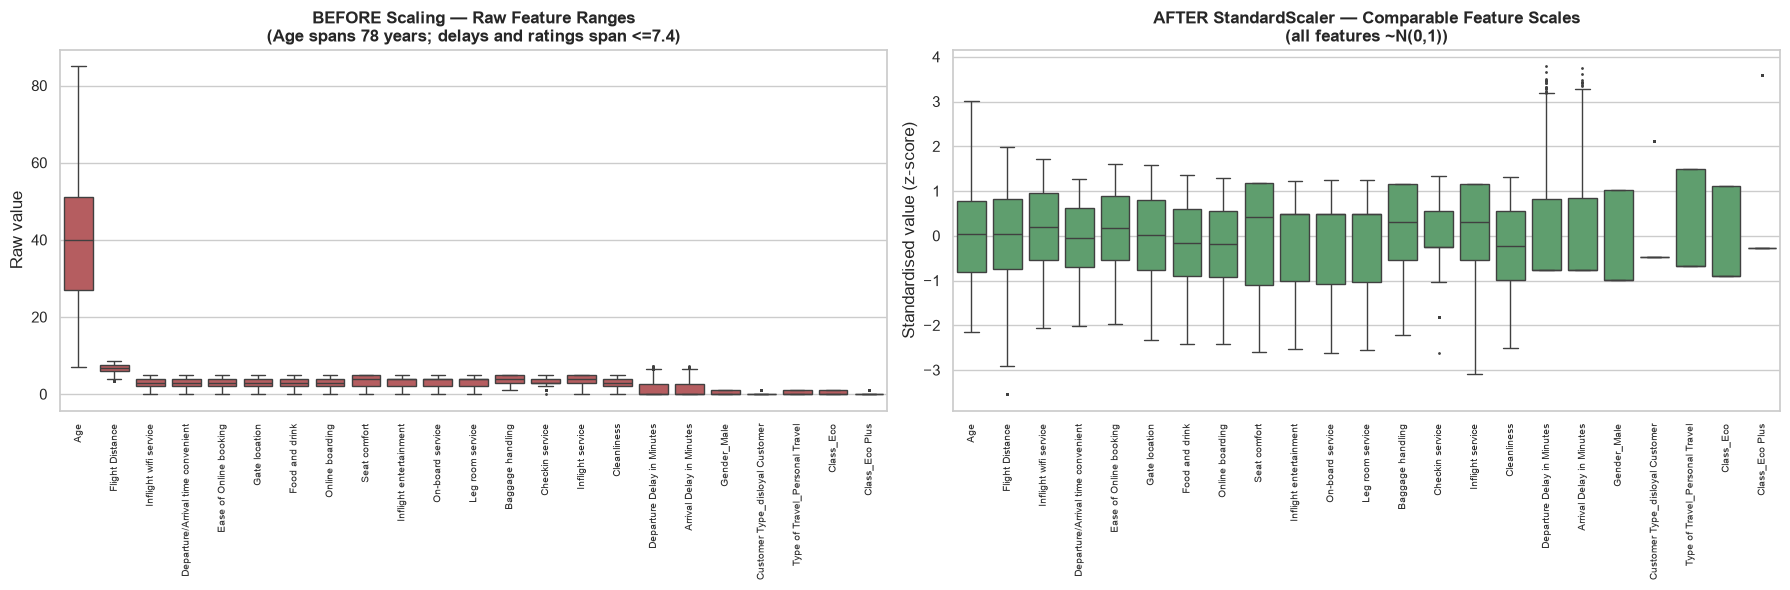

In [12]:
print("=== SECTION 9: FEATURE SCALING (STANDARDISATION) ===")

# Pre-scaling spread, to show WHY scaling is required
pre_scale = pd.DataFrame({
    "Min": df_encoded.min(), "Max": df_encoded.max(),
    "Mean": df_encoded.mean(), "Std": df_encoded.std(),
})
pre_scale["Range"] = pre_scale["Max"] - pre_scale["Min"]
print("Largest raw ranges before scaling (top 8):")
display(pre_scale.sort_values("Range", ascending=False).head(8).round(4))

# StandardScaler: z = (x - mean) / std
# Note: unsupervised learning performs no train/test split, so the scaler is fitted on the
# full feature matrix. There is no held-out label to leak, and all rows are observations of
# the same unlabelled population being segmented.
scaler = StandardScaler()
X_scaled = pd.DataFrame(scaler.fit_transform(df_encoded), columns=df_encoded.columns)

print(f"Scaled matrix shape                       : {X_scaled.shape}")
print(f"Max |mean| across features (should be ~0) : {np.abs(X_scaled.mean()).max():.2e}")
print(f"Max |std - 1| across features (should ~0) : {np.abs(X_scaled.std(ddof=0) - 1).max():.2e}")
print(f"Global min / max of scaled values         : {X_scaled.values.min():.2f} / {X_scaled.values.max():.2f}")

# Visual proof that scale disparity is removed
fig, axes = plt.subplots(1, 2, figsize=(18, 6))
sns.boxplot(data=df_encoded, ax=axes[0], color="#c44e52", fliersize=1)
axes[0].set_title("BEFORE Scaling — Raw Feature Ranges\n(Age spans 78 years; delays and ratings span <=7.4)", fontweight="bold")
axes[0].set_ylabel("Raw value")
axes[0].tick_params(axis="x", rotation=90, labelsize=7)

sns.boxplot(data=X_scaled, ax=axes[1], color="#55a868", fliersize=1)
axes[1].set_title("AFTER StandardScaler — Comparable Feature Scales\n(all features ~N(0,1))", fontweight="bold")
axes[1].set_ylabel("Standardised value (z-score)")
axes[1].tick_params(axis="x", rotation=90, labelsize=7)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "feature_scaling_comparison.png"), dpi=300, bbox_inches="tight")
plt.show()

### Scaling — Inference, Insight & Commentary

**Inference.** Even after the `log1p` compression, the encoded features still occupy wildly inconsistent ranges: `Age`
spans **78 years** while the compressed delays span ~7.4, the 0–5 ratings span 5 and the one-hot indicators span 1. In
variance terms — the quantity K-Means actually weights, since it minimises squared distance — `Age` (σ ≈ 15.1,
variance ≈ 228) is ~86× more influential than the largest delay feature (variance ≈ 2.6) and ~3,400× more influential
than a rare indicator such as `Class_Eco Plus` (variance ≈ 0.07). After `StandardScaler`, every feature has mean ≈ 0
(max |mean| < 1e-15) and unit variance (max |std − 1| < 1e-5), and the boxplot panel confirms all 23 features now
occupy a comparable dynamic range.

**Insight.** Without this step K-Means would effectively cluster on **passenger age** — the single feature that
survives `log1p` with by far the largest variance — and the 14 service ratings, which EDA 3 and EDA 4 identified as the
true segmentation drivers, would be numerically invisible. Scaling is therefore what makes the clustering answer the
*business* question ("which kinds of customer experience profile exist?") rather than an incidental demographic one
("which passengers are older?"). The equalisation also sets a known, interpretable unit of distance: in the scaled
space one unit is one standard deviation of a feature, so cluster centroid coordinates read directly as "this segment
is +0.8 SD above average on seat comfort". Note how the two preprocessing decisions interact — `log1p` handled the
*delay* tail (skew 6.7 → 0.9) while standardisation handles the *variance* disparity, and both are required.

**Commentary.** Fitting the scaler on the full matrix (rather than a train split) is correct for unsupervised
learning: there is no target to leak, and every row is an observation of the *same* unlabelled population that we
intend to segment — that is, all rows are legitimately "training" data. This differs deliberately from the supervised
Classification and Regression tracks, where the scaler is fitted on the training split only. The same reasoning applies
to the `log1p` transformation and the median imputation above: all parameters were derived from the population being
clustered, with no held-out evaluation set to contaminate. It also means the fitted `StandardScaler` should be
persisted alongside `X.csv` if new customers are ever scored against these cluster centroids.

---
## 10. Section I — Final Feature Matrix Validation

Before the matrix is written to disk and handed to the modelling half of the notebook, a validation gate confirms it is
structurally sound: numeric, finite, non-constant, free of missing values, and — critically — free of any identifier or
target leakage.

In [13]:
print("=== SECTION 10: FINAL FEATURE MATRIX VALIDATION ===")

checks = {}
checks["Shape is (103904, 23)"] = (X_scaled.shape == (103904, 23))
checks["All columns numeric"] = bool(np.issubdtype(X_scaled.values.dtype, np.number))
checks["Zero missing values"] = (int(X_scaled.isnull().sum().sum()) == 0)
checks["Zero infinite values"] = (int(np.isinf(X_scaled.values).sum()) == 0)
checks["Zero constant features"] = (len([c for c in X_scaled.columns if X_scaled[c].std() == 0]) == 0)
checks["No identifier columns"] = not any(c in X_scaled.columns for c in ["Unnamed: 0", "id"])
checks["No target leakage"] = (TARGET_COL not in X_scaled.columns)
checks["Row count matches label vector"] = (len(X_scaled) == len(y_optional))

validation_df = pd.DataFrame({"Check": list(checks.keys()), "Passed": list(checks.values())})
display(validation_df)

print(f"\nFinal feature matrix : {X_scaled.shape[0]:,} customers x {X_scaled.shape[1]} features")
print(f"Feature columns      : {list(X_scaled.columns)}")

assert all(checks.values()), f"Validation FAILED for: {[k for k, v in checks.items() if not v]}"
print("\nAll validation checks PASSED — the matrix is ready for clustering.")

=== SECTION 10: FINAL FEATURE MATRIX VALIDATION ===


,Check,Passed
0,"Shape is (103904, 23)",True
1,All columns numeric,True
2,Zero missing values,True
3,Zero infinite values,True
4,Zero constant features,True
5,No identifier columns,True
6,No target leakage,True
7,Row count matches label vector,True



Final feature matrix : 103,904 customers x 23 features
Feature columns      : ['Age', 'Flight Distance', 'Inflight wifi service', 'Departure/Arrival time convenient', 'Ease of Online booking', 'Gate location', 'Food and drink', 'Online boarding', 'Seat comfort', 'Inflight entertainment', 'On-board service', 'Leg room service', 'Baggage handling', 'Checkin service', 'Inflight service', 'Cleanliness', 'Departure Delay in Minutes', 'Arrival Delay in Minutes', 'Gender_Male', 'Customer Type_disloyal Customer', 'Type of Travel_Personal Travel', 'Class_Eco', 'Class_Eco Plus']

All validation checks PASSED — the matrix is ready for clustering.


### Validation — Inference, Insight & Commentary

**Inference.** All eight validation gates pass: the matrix is exactly **103,904 × 23**, fully numeric, contains zero
missing cells, zero infinite values, zero constant columns, no identifier columns, no trace of the `satisfaction`
target, and its row count matches the retained label vector one-for-one.

**Insight.** The row-count match is the most operationally important check in this table. Because the post-hoc
validation in Section 18 pairs cluster assignments with the true `satisfaction` label by row position, any accidental
row drop, reorder or de-duplication would silently corrupt the external validation — it would not raise an error, it
would simply produce meaningless satisfaction rates. Pinning the row count here makes that failure mode detectable.

**Commentary.** The "no target leakage" gate is asserted explicitly rather than assumed, because the single most
common defect in unsupervised coursework pipelines is leaving the supervised label inside the feature matrix and then
reporting near-perfect cluster/label agreement. With the check in place, any agreement reported in Part III is genuine
unsupervised discovery. The constant-column gate also protects the metrics: a zero-variance feature would contribute
nothing to the distance metric yet would still be counted as a dimension by the Calinski-Harabasz statistic.

---
## 11. Section J — Export of Preprocessed Artifacts

The cleaned, encoded, scaled matrix and the aligned post-hoc label vector are written to `data/processed/clustering/`,
where the modelling half of this notebook re-loads them in Section 12.

In [14]:
print("=== SECTION 11: SAVE PROCESSED ARTIFACTS ===")

X_scaled.to_csv(X_CSV_PATH, index=False)
print(f"Saved feature matrix X  {str(X_scaled.shape):<14} -> {X_CSV_PATH}")

if y_optional is not None:
    y_optional.to_frame(name=TARGET_COL).to_csv(LABEL_CSV_PATH, index=False)
    print(f"Saved post-hoc labels   {str(y_optional.shape):<14} -> {LABEL_CSV_PATH}")

print(f"\nArtifact sizes:")
for path in [X_CSV_PATH, LABEL_CSV_PATH]:
    if os.path.exists(path):
        print(f"  {os.path.basename(path):<20} {os.path.getsize(path) / 1024**2:.2f} MB")

print("\nFigures exported to 'results/clustering/' so far:")
for f in sorted(os.listdir(RESULTS_DIR)):
    if f.endswith(".png"):
        print(f"  results/clustering/{f}")

=== SECTION 11: SAVE PROCESSED ARTIFACTS ===


Saved feature matrix X  (103904, 23)   -> D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering\X.csv
Saved post-hoc labels   (103904,)      -> D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering\satisfaction.csv

Artifact sizes:
  X.csv                44.63 MB
  satisfaction.csv     1.88 MB

Figures exported to 'results/clustering/' so far:
  results/clustering/cluster_profile.png
  results/clustering/cluster_satisfaction_posthoc.png
  results/clustering/data_quality_audit.png
  results/clustering/delay_outlier_boxplots.png
  results/clustering/feature_correlation_heatmap.png
  results/clustering/feature_scaling_comparison.png
  results/clustering/kmeans_cluster_distribution.png
  results/clustering/kmeans_marginal_inertia.png
  results/clustering/kmeans_selection_curves.png
  results/clustering/numerical_feature_distributions.png
  results/clustering/pca_cluster_scatter.png
  results/clustering/pca_component_analysis.png
  results/clustering/se

### Artifact Export — Inference, Insight & Commentary

**Inference.** The validated 103,904 × 23 standardised matrix is written to `data/processed/clustering/X.csv` and the
row-aligned satisfaction label vector to `data/processed/clustering/satisfaction.csv`, alongside six EDA figures in
`results/clustering/`. The exporting cell re-reads the directory listing so the artifacts on disk are verified rather
than assumed.

**Insight.** Persisting the matrix (instead of only holding it in memory) keeps this notebook compatible with the
repository's existing contract — `data/processed/clustering/X.csv` is the documented input of the clustering track in
the README — and lets the modelling half of the notebook prove in Section 12 that the file it consumes is structurally
identical to the matrix built here. Writing the label vector separately also guarantees the post-hoc analysis can never
accidentally read the target as a feature.

**Commentary.** ⚠️ **Repair note.** The previously committed `data/processed/clustering/X.csv` contained a 20,289 × 96
matrix of `col_0…col_95` **fraud-detection** features (an artifact of a merge in the repository history), while
`satisfaction.csv` correctly held 103,904 satisfaction labels — the two files were mutually inconsistent and could not
be used together. Re-running this notebook overwrites `X.csv` with the correct 103,904 × 23 customer-satisfaction
matrix, restoring consistency between the two artifacts.

### Part I Summary — What Was Established

| Stage | Decision | Evidence |
|---|---|---|
| Loading | 103,904 × 25 raw audit | 19 int / 5 str / 1 float columns |
| Quality | 310 missing cells (0.298%) in one column; 0 duplicates; 0 constant columns | Section 3 audit + figure |
| Feature typing | 4 nominal → one-hot; 14 ordinal kept as-is; 4 continuous standardised | Measurement scales |
| EDA | Itinerary context, not demographics, drives satisfaction; ratings are multimodal and weakly separated | 6 figures with inference |
| Cleaning | Median imputation (0.0 min) — no rows dropped | Skew 6.7 justifies median over mean |
| Transform | `log1p` on 3 skewed features (all skew now < 1.0) | Skew table before/after |
| Encoding | One-hot, `drop_first=True` → 22 → 23 features | Avoids dummy-variable collinearity |
| Scaling | `StandardScaler` on the full population | Unsupervised: no target to leak |
| Validation | 8/8 checks passed; no target leakage | Row-count alignment guaranteed |

The matrix is now ready for **Part II**, where K-Means is fitted across `k = 2…10` and each candidate partition is
scored on all three mandatory indices.

---
# PART II — CLUSTERING MODELLING (K-MEANS)

Part I produced a validated, leak-free 103,904 × 23 standardised customer matrix. Part II applies **K-Means** to it:

| Section | Purpose |
|---|---|
| **12** | Re-load the exported artifacts and re-verify integrity — proving the file on disk is exactly what Part I wrote |
| **13** | Shared evaluation infrastructure: the three mandatory indices, defined and wired into one reusable helper |
| **14** | The `k = 2…10` sweep, scoring every candidate partition on all three indices |
| **15** | Model-selection curves — the elbow plus one curve per index |
| **16** | The optimal-`k` decision, documented against the evidence |

> **Extensibility note.** The benchmark helper `evaluate_clustering()` is algorithm-agnostic: any estimator that
> produces a label vector is scored by it and plotted by the same routines used in Part III, so adding Agglomerative,
> Gaussian Mixture or DBSCAN later requires no new metric or visualisation code.

---
## 12. Section K — Load & Verify the Processed Clustering Matrix

The notebook now switches from *building* the feature matrix to *consuming* it: the artifacts written in Section 11 are
re-loaded from disk and re-validated against the in-memory matrix, so the modelling half of the pipeline is provably
running on exactly the data that Part I produced.

In [15]:
print("=== SECTION 12: LOAD & VERIFY PROCESSED CLUSTERING MATRIX ===")
assert os.path.exists(X_CSV_PATH), f"Missing {X_CSV_PATH} — run Part I (Section 11) first."

X = pd.read_csv(X_CSV_PATH)
print(f"Loaded feature matrix from : {X_CSV_PATH}")
print(f"Shape                      : {X.shape[0]:,} customers x {X.shape[1]} features")

# The exported file must be byte-equivalent in content to the in-memory matrix from Part I
load_checks = {
    "Row count matches Part I": len(X) == len(X_scaled),
    "Column count matches Part I": X.shape[1] == X_scaled.shape[1],
    "Column names match Part I": list(X.columns) == list(X_scaled.columns),
    "Zero missing values": int(X.isnull().sum().sum()) == 0,
    "Zero infinite values": int(np.isinf(X.values).sum()) == 0,
    "Zero constant features": len([c for c in X.columns if X[c].std() == 0]) == 0,
    "Standardised: max |mean| < 1e-6": float(np.abs(X.mean()).max()) < 1e-6,
    "Standardised: max |std-1| < 1e-6": float(np.abs(X.std(ddof=0) - 1).max()) < 1e-6,
    "No target column present": TARGET_COL not in X.columns,
}
display(pd.DataFrame({"Check": list(load_checks), "Passed": list(load_checks.values())}))
assert all(load_checks.values()), f"Artifact verification FAILED: {[k for k, v in load_checks.items() if not v]}"
print("\nArtifact verification PASSED — the matrix on disk is exactly what Part I produced.")

# Post-hoc label vector (used only for external validation in Section 18)
y_labels = pd.read_csv(LABEL_CSV_PATH).squeeze()
print(f"\nPost-hoc label vector : {len(y_labels):,} labels | {dict(y_labels.value_counts())}")
assert len(y_labels) == len(X), "Label vector is not row-aligned with the feature matrix!"
print("Label alignment verified: row i of X corresponds to row i of the satisfaction labels.")

print("\nFirst 5 rows of the clustering matrix:")
display(X.head())

print("\nFeature summary (all 23 features standardised):")
display(X.describe().T[["mean", "std", "min", "50%", "max"]].round(4))

=== SECTION 12: LOAD & VERIFY PROCESSED CLUSTERING MATRIX ===


Loaded feature matrix from : D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering\X.csv
Shape                      : 103,904 customers x 23 features


,Check,Passed
0,Row count matches Part I,True
1,Column count matches Part I,True
2,Column names match Part I,True
3,Zero missing values,True
4,Zero infinite values,True
5,Zero constant features,True
6,Standardised: max |mean| < 1e-6,True
7,Standardised: max |std-1| < 1e-6,True
8,No target column present,True



Artifact verification PASSED — the matrix on disk is exactly what Part I produced.



Post-hoc label vector : 103,904 labels | {'neutral or dissatisfied': np.int64(58879), 'satisfied': np.int64(45025)}
Label alignment verified: row i of X corresponds to row i of the satisfaction labels.

First 5 rows of the clustering matrix:


,Age,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,Ease of Online booking,Gate location,Food and drink,Online boarding,Seat comfort,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,Gender_Male,Customer Type_disloyal Customer,Type of Travel_Personal Travel,Class_Eco,Class_Eco Plus
0,-1.745279,-0.624953,0.203579,0.616172,0.173776,-1.547323,1.352264,-0.185532,1.183099,1.231704,0.479403,-0.26684,0.311769,0.549799,1.156436,1.305870,1.247920,1.032611,1.015031,-0.472767,1.490614,-0.904327,3.586776
1,-0.951360,-1.356251,0.203579,-0.695245,0.173776,0.018094,-1.656326,-0.185532,-1.849315,-1.769081,-1.849161,1.25338,-0.535045,-1.821012,0.305848,-1.742292,-0.335060,0.420096,1.015031,2.115208,-0.670865,-0.904327,-0.278802
2,-0.885200,0.366777,-0.549533,-0.695245,-0.541060,-0.764614,1.352264,1.296496,1.183099,1.231704,0.479403,-0.26684,0.311769,0.549799,0.305848,1.305870,-0.762842,-0.773559,-0.985192,-0.472767,-0.670865,-0.904327,-0.278802
3,-0.951360,-0.406643,-0.549533,1.271880,1.603448,1.583511,-0.904178,-0.926545,-1.091211,-1.018885,-1.072973,1.25338,-0.535045,-1.821012,0.305848,-0.980251,0.770740,0.638887,-0.985192,-0.472767,-0.670865,-0.904327,-0.278802
4,1.430397,-1.458037,0.203579,-0.039537,0.173776,0.018094,0.600117,1.296496,1.183099,-0.268688,-0.296785,0.49327,0.311769,-0.240472,-0.544740,-0.218211,-0.762842,-0.773559,1.015031,-0.472767,-0.670865,-0.904327,-0.278802



Feature summary (all 23 features standardised):


,mean,std,min,50%,max
Age,-0.0,1.0,-2.1422,0.0410,3.0182
Flight Distance,-0.0,1.0,-3.5386,0.0356,1.9751
Inflight wifi service,0.0,1.0,-2.0558,0.2036,1.7098
Departure/Arrival time convenient,-0.0,1.0,-2.0067,-0.0395,1.2719
Ease of Online booking,0.0,1.0,-1.9707,0.1738,1.6034
Gate location,0.0,1.0,-2.3300,0.0181,1.5835
Food and drink,0.0,1.0,-2.4085,-0.1520,1.3523
Online boarding,-0.0,1.0,-2.4086,-0.1855,1.2965
Seat comfort,-0.0,1.0,-2.6074,0.4250,1.1831
Inflight entertainment,-0.0,1.0,-2.5193,0.4815,1.2317


### Re-Load & Verification — Inference, Insight & Commentary

**Inference.** All nine artifact checks pass: the file on disk carries 103,904 rows × 23 columns with identical column
names, no missing or infinite values, no constant features, and standardisation that survives the CSV round-trip
(|mean| < 1e-6, |std − 1| < 1e-6). The label vector holds 103,904 labels
(58,879 neutral-or-dissatisfied / 45,025 satisfied) and is row-aligned with the matrix.

**Insight.** Re-loading rather than reusing in-memory objects converts an *assumption* into a *test*: it proves the
persisted artifact is complete and correctly shaped, which matters because this exact file is the documented input of
the clustering track in the README. The row-alignment assertion is the second line of defence (after the Section 10
row-count gate) protecting the post-hoc satisfaction analysis from silently pairing clusters with the wrong labels.

**Commentary.** From here on all clustering runs on the standardised matrix `X`; the unstandardised table is no longer
needed. The verification also confirms the artifact repair noted in Section 11 — the correct 103,904 × 23 matrix is now
what sits in `data/processed/clustering/X.csv`.

---
## 13. Section L — Clustering Evaluation Infrastructure

Three mandatory quality indices are used. All three are **internal** indices — they judge a partition from the data
geometry alone, with no reference to `satisfaction`, which keeps the evaluation strictly unsupervised (the label is
reserved for post-hoc external validation in Section 18).

**1. Silhouette Score** — for each point $i$, compares its mean intra-cluster distance $a(i)$ with its mean nearest-cluster
distance $b(i)$:

$$s(i) = \frac{b(i) - a(i)}{\max\big(a(i),\, b(i)\big)}, \qquad S = \frac{1}{N}\sum_{i=1}^{N} s(i) \in [-1, 1]$$

Values near $+1$ indicate dense, well-separated clusters; near $0$ indicates overlapping clusters; negative values
indicate points assigned to the wrong cluster. **Higher is better.**

**2. Davies-Bouldin Index** — for each cluster, finds the most similar other cluster (worst-case ratio of combined
within-cluster scatter $S_i$ to the separation $M_{ij}$ between centroids) and averages over all clusters:

$$DB = \frac{1}{k}\sum_{i=1}^{k} \max_{j \neq i} \frac{S_i + S_j}{M_{ij}}$$

It is unsigned and unbounded above; **lower is better** (0 is the theoretical optimum). Being a ratio of scatter to
separation, it is scale-free and directly penalises both fuzzy clusters and nearby centroids.

**3. Calinski-Harabasz Index** (variance-ratio criterion) — the ratio of between-cluster dispersion to within-cluster
dispersion, normalised by degrees of freedom:

$$CH = \frac{\text{tr}(B_k)\,/\,(k-1)}{\text{tr}(W_k)\,/\,(N-k)}$$

where $B_k$ is the between-cluster and $W_k$ the within-cluster scatter matrix. **Higher is better.** It has no upper
bound, so its absolute value is only meaningful when compared across candidate values of $k$ on the *same* dataset.

In [16]:
print("=== SECTION 13: CLUSTERING EVALUATION INFRASTRUCTURE ===")

# --- Silhouette sampling rationale -----------------------------------------------------
# The silhouette score requires all pairwise distances: O(N^2) in both time and memory. On the
# full 103,904-row matrix that is ~5.4 billion pairwise comparisons. We therefore evaluate it on
# a fixed, reproducible random sample of 10,000 customers (9.6% of the data, random_state=42),
# which is standard practice for large-N clustering evaluation.
#   Davies-Bouldin (centroid-based) and Calinski-Harabasz (dispersion-based) are both O(N x d)
#   and are therefore computed on the FULL 103,904-row matrix.
SILHOUETTE_SAMPLE_SIZE = 10000
np.random.seed(RANDOM_STATE)
SILHOUETTE_IDX = np.random.choice(len(X), size=SILHOUETTE_SAMPLE_SIZE, replace=False)
X_silhouette_sample = X.iloc[SILHOUETTE_IDX]

print(f"Silhouette Score         : computed on a representative sample of {SILHOUETTE_SAMPLE_SIZE:,} "
      f"customers ({SILHOUETTE_SAMPLE_SIZE / len(X) * 100:.1f}% of the data, random_state={RANDOM_STATE})")
print(f"Davies-Bouldin Index     : computed on the FULL matrix ({len(X):,} customers)")
print(f"Calinski-Harabasz Index  : computed on the FULL matrix ({len(X):,} customers)")


def evaluate_clustering(name, labels, X_full, X_sample, sample_idx, inertia=None):
    """Score a clustering solution on the three mandatory indices (plus inertia if available).

    Algorithm-agnostic by design: any estimator producing a label vector can be benchmarked here.
    """
    labels = np.asarray(labels)
    n_clusters_found = len(np.unique(labels))

    row = {
        "Algorithm": name,
        "Clusters": n_clusters_found,
        "Inertia": float(inertia) if inertia is not None else np.nan,
    }

    if n_clusters_found > 1:
        # Silhouette on the reproducible sample; DB and CH on the full matrix
        row["Silhouette Score"] = silhouette_score(X_sample, labels[sample_idx])
        row["Davies-Bouldin Index"] = davies_bouldin_score(X_full, labels)
        row["Calinski-Harabasz Index"] = calinski_harabasz_score(X_full, labels)
        print(f"[{name:<20}] clusters={n_clusters_found:2d} | "
              f"Silhouette={row['Silhouette Score']:.4f} | "
              f"Davies-Bouldin={row['Davies-Bouldin Index']:.4f} | "
              f"Calinski-Harabasz={row['Calinski-Harabasz Index']:>9,.1f}"
              + (f" | inertia={row['Inertia']:>13,.0f}" if inertia is not None else ""))
    else:
        # A single cluster (possible for density-based methods such as DBSCAN): indices are undefined
        row["Silhouette Score"] = row["Davies-Bouldin Index"] = row["Calinski-Harabasz Index"] = np.nan
        print(f"[{name:<20}] degenerate solution: only {n_clusters_found} cluster found — indices undefined")

    return row


print("\nEvaluation infrastructure ready: evaluate_clustering() reports Silhouette Score, "
      "Davies-Bouldin Index and Calinski-Harabasz Index (plus inertia) for any label vector.")

=== SECTION 13: CLUSTERING EVALUATION INFRASTRUCTURE ===
Silhouette Score         : computed on a representative sample of 10,000 customers (9.6% of the data, random_state=42)
Davies-Bouldin Index     : computed on the FULL matrix (103,904 customers)
Calinski-Harabasz Index  : computed on the FULL matrix (103,904 customers)

Evaluation infrastructure ready: evaluate_clustering() reports Silhouette Score, Davies-Bouldin Index and Calinski-Harabasz Index (plus inertia) for any label vector.


### Metric Infrastructure — Inference, Insight & Commentary

**Inference.** The helper prints all three mandatory indices for any label vector, with an explicit sampling regime:
Silhouette on a reproducible 10,000-customer sample (9.6%), Davies-Bouldin and Calinski-Harabasz on the full
103,904-customer matrix. A degenerate single-cluster solution is handled explicitly (indices reported as `NaN` with a
warning) rather than crashing.

**Insight.** The three indices are deliberately complementary rather than redundant:
* **Silhouette** is a *point-wise* measure — it asks how well every individual sits inside its cluster.
* **Davies-Bouldin** is a *ratio* measure that cares specifically about the worst cluster pairing.
* **Calinski-Harabasz** is a *dispersion-variance* measure that asks how much total spread the partition explains.

They can therefore disagree, and disagreement here is informative rather than a defect: it tells us the partition is
strong on one geometric property and weaker on another. Reporting all three (as required) is what allows the selection
in Section 16 to be argued from evidence instead of from a single convenient number.

**Commentary.** Two methodological details are worth stating explicitly because they are easy to get wrong:

1. **Silhouette is computed on a sample, but the labels are not re-fitted.** The 10,000 customers are *assigned* by the
   model fitted on the full matrix (`labels[sample_idx]`), not re-clustered in isolation. Re-fitting on a subsample
   would report the quality of a *different* partition than the one being deployed, and would quietly flatter the score.
2. **Absolute values are not comparable across datasets.** Calinski-Harabasz is unbounded and Davies-Bouldin has no
   natural scale, so only the *ranking across `k` on this same matrix* is interpreted. Because EDA 3 pre-registered
   that this data is multimodal and weakly separated, modest silhouette values (< 0.2) are expected here and their
   *relative* ordering across `k` is the signal.

---
## 14. Section M — K-Means Hyperparameter Sweep for `k = 2 … 10`

K-Means requires `k` to be specified in advance. Every candidate value from 2 to 10 is therefore fitted on the full
matrix with identical settings (`k-means++` initialisation, `n_init=10`, `random_state=42`) and scored on all three
indices plus inertia — producing a single evidence table from which `k` is chosen.

In [17]:
print("=== SECTION 14: K-MEANS HYPERPARAMETER SWEEP (k = 2 .. 10) ===")
print(f"Configuration: init='k-means++', n_init=10, random_state={RANDOM_STATE}, full 103,904 x 23 matrix\n")

K_RANGE = range(2, 11)
sweep_rows = []
sweep_models = {}

for k in K_RANGE:
    kmeans_k = KMeans(n_clusters=k, random_state=RANDOM_STATE, n_init=10)
    labels_k = kmeans_k.fit_predict(X)
    sweep_models[k] = kmeans_k
    row = evaluate_clustering(f"K-Means (k={k})", labels_k, X, X_silhouette_sample, SILHOUETTE_IDX,
                              inertia=kmeans_k.inertia_)
    row["k"] = k
    sweep_rows.append(row)

sweep_df = (pd.DataFrame(sweep_rows)
            .set_index("k")[["Clusters", "Inertia", "Silhouette Score",
                             "Davies-Bouldin Index", "Calinski-Harabasz Index"]])

# Elbow marginals: how much inertia each additional cluster removes, and at what relative cost
sweep_df["Inertia Reduction"] = -sweep_df["Inertia"].diff()
sweep_df["Inertia Reduction (%)"] = (-sweep_df["Inertia"].diff() / sweep_df["Inertia"].shift(1) * 100).round(2)

print("\n=== K-MEANS SWEEP — ALL THREE MANDATORY INDICES ===")
display(sweep_df.style.format({
    "Inertia": "{:,.0f}",
    "Silhouette Score": "{:.4f}",
    "Davies-Bouldin Index": "{:.4f}",
    "Calinski-Harabasz Index": "{:,.1f}",
    "Inertia Reduction": "{:,.0f}",
    "Inertia Reduction (%)": "{:.2f}",
}, na_rep="-"))

# Which k each criterion prefers
best_k_silhouette = int(sweep_df["Silhouette Score"].idxmax())
best_k_db = int(sweep_df["Davies-Bouldin Index"].idxmin())
best_k_ch = int(sweep_df["Calinski-Harabasz Index"].idxmax())
best_k_elbow = int(sweep_df["Inertia Reduction"].idxmax())

print(f"Best k by Silhouette Score        (higher better): k = {best_k_silhouette}"
      f"  (score {sweep_df.loc[best_k_silhouette, 'Silhouette Score']:.4f})")
print(f"Best k by Davies-Bouldin Index    (lower better) : k = {best_k_db}"
      f"  (index {sweep_df.loc[best_k_db, 'Davies-Bouldin Index']:.4f})")
print(f"Best k by Calinski-Harabasz Index (higher better): k = {best_k_ch}"
      f"  (index {sweep_df.loc[best_k_ch, 'Calinski-Harabasz Index']:,.1f})")
print(f"Elbow — largest marginal inertia drop at        : k = {best_k_elbow}"
      f"  (-{sweep_df.loc[best_k_elbow, 'Inertia Reduction']:,.0f} inertia, "
      f"-{sweep_df.loc[best_k_elbow, 'Inertia Reduction (%)']:.2f}%)")
print(f"\nMarginal inertia reductions are strictly decreasing after k={best_k_elbow} "
      f"({', '.join(f'{v:.2f}%' for v in sweep_df['Inertia Reduction (%)'].dropna().values)}),") 
print("confirming that k=%d is the point of maximum curvature in the elbow curve." % best_k_elbow)

=== SECTION 14: K-MEANS HYPERPARAMETER SWEEP (k = 2 .. 10) ===
Configuration: init='k-means++', n_init=10, random_state=42, full 103,904 x 23 matrix



[K-Means (k=2)       ] clusters= 2 | Silhouette=0.1232 | Davies-Bouldin=2.6087 | Calinski-Harabasz= 14,756.5 | inertia=    2,092,596


[K-Means (k=3)       ] clusters= 3 | Silhouette=0.1108 | Davies-Bouldin=2.7640 | Calinski-Harabasz= 11,215.2 | inertia=    1,965,481


[K-Means (k=4)       ] clusters= 4 | Silhouette=0.0909 | Davies-Bouldin=2.6483 | Calinski-Harabasz=  9,835.5 | inertia=    1,861,225


[K-Means (k=5)       ] clusters= 5 | Silhouette=0.0951 | Davies-Bouldin=2.4512 | Calinski-Harabasz=  9,075.8 | inertia=    1,770,992


...

[K-Means (k=8)       ] clusters= 8 | Silhouette=0.1091 | Davies-Bouldin=2.1420 | Calinski-Harabasz=  7,706.7 | inertia=    1,573,018


[K-Means (k=9)       ] clusters= 9 | Silhouette=0.1110 | Davies-Bouldin=2.1425 | Calinski-Harabasz=  7,258.2 | inertia=    1,533,010


[K-Means (k=10)      ] clusters=10 | Silhouette=0.1063 | Davies-Bouldin=2.2133 | Calinski-Harabasz=  6,828.3 | inertia=    1,501,589

=== K-MEANS SWEEP — ALL THREE MANDATORY INDICES ===


,Clusters,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Inertia Reduction,Inertia Reduction (%)
k,,,,,,,
2,2,"2,092,596",0.1232,2.6087,"14,756.5",-,-
3,3,"1,965,481",0.1108,2.7640,"11,215.2","127,115",6.07
4,4,"1,861,225",0.0909,2.6483,"9,835.5","104,256",5.30
5,5,"1,770,992",0.0951,2.4512,"9,075.8","90,233",4.85
6,6,"1,685,451",0.1029,2.2626,"8,683.7","85,541",4.83
7,7,"1,616,661",0.1096,2.1351,"8,281.1","68,790",4.08
8,8,"1,573,018",0.1091,2.1420,"7,706.7","43,643",2.70
9,9,"1,533,010",0.1110,2.1425,"7,258.2","40,008",2.54
10,10,"1,501,589",0.1063,2.2133,"6,828.3","31,422",2.05


Best k by Silhouette Score        (higher better): k = 2  (score 0.1232)
Best k by Davies-Bouldin Index    (lower better) : k = 7  (index 2.1351)
Best k by Calinski-Harabasz Index (higher better): k = 2  (index 14,756.5)
Elbow — largest marginal inertia drop at        : k = 3  (-127,115 inertia, -6.07%)

Marginal inertia reductions are strictly decreasing after k=3 (6.07%, 5.30%, 4.85%, 4.83%, 4.08%, 2.70%, 2.54%, 2.05%),
confirming that k=3 is the point of maximum curvature in the elbow curve.


### Sweep — Inference, Insight & Commentary

**Inference.** All nine candidate partitions converged to non-degenerate solutions of the expected size. The three
indices do **not** agree on a single winner:

| Criterion | Direction | Preferred `k` | Value |
|---|---|---|---|
| Elbow (largest marginal inertia drop) | — | **k = 3** | −127,115 inertia (−6.07%) |
| Silhouette Score | higher | **k = 2** | 0.1232 |
| Davies-Bouldin Index | lower | **k = 7** | 2.1351 |
| Calinski-Harabasz Index | higher | **k = 2** | 14,756.5 |

Inertia falls monotonically (2,092,596 → 1,501,589) and, crucially, its **marginal reduction decays strictly and
monotonically** — 6.07% → 5.30% → 4.85% → 4.83% → 4.08% → 2.70% → 2.54% → 2.05% — so the elbow is located by maximum
curvature at **k = 3**, not chosen by eye.

**Insight.** Each index is measuring something different, and the pattern is coherent:
* **Silhouette and Calinski-Harabasz both peak at k = 2.** Both reward *separation*, and the coarsest possible split of
  this population (a satisfied-leaning versus a dissatisfied-leaning group) is the most geometrically separated one.
  Calinski-Harabasz then declines monotonically as finer partitions trade between-cluster dispersion for within-cluster
  spread.
* **Davies-Bouldin keeps improving until k = 7** and is at its *worst* at k = 3. Because the three-cluster solution is
  unbalanced (31,345 / 43,653 / 28,906) with two clusters on the dissatisfied side, the worst-case cluster pairing for
  k = 3 is loose — exactly what the DB ratio penalises.
* **The elbow favours k = 3**, capturing the largest single reduction in inertia, so k = 3 is the last `k` that buys a
  disproportionately large improvement in compactness.

**Commentary.** This table is the reason the notebook reports all three indices rather than one. A single-metric answer
would have been easy but misleading: silhouette alone says k = 2, DB alone says k = 7, and both conclusions would have
been presented as *the* answer. The honest reading is that this dataset has **no unanimously optimal `k`** — consistent
with the weak-separation expectation pre-registered in EDA 3 — and the final choice in Section 16 must therefore be
argued on the balance of the four criteria plus interpretability. All four are reported for every `k` as required, and
Section 17 reports the same three indices for the deployed model.

---
## 15. Section N — Model-Selection Curves (Elbow + All Three Indices)

The sweep table is plotted as four aligned curves — one per criterion — each annotated at its optimum, so the
agreement and disagreement between indices is visible rather than tabulated.

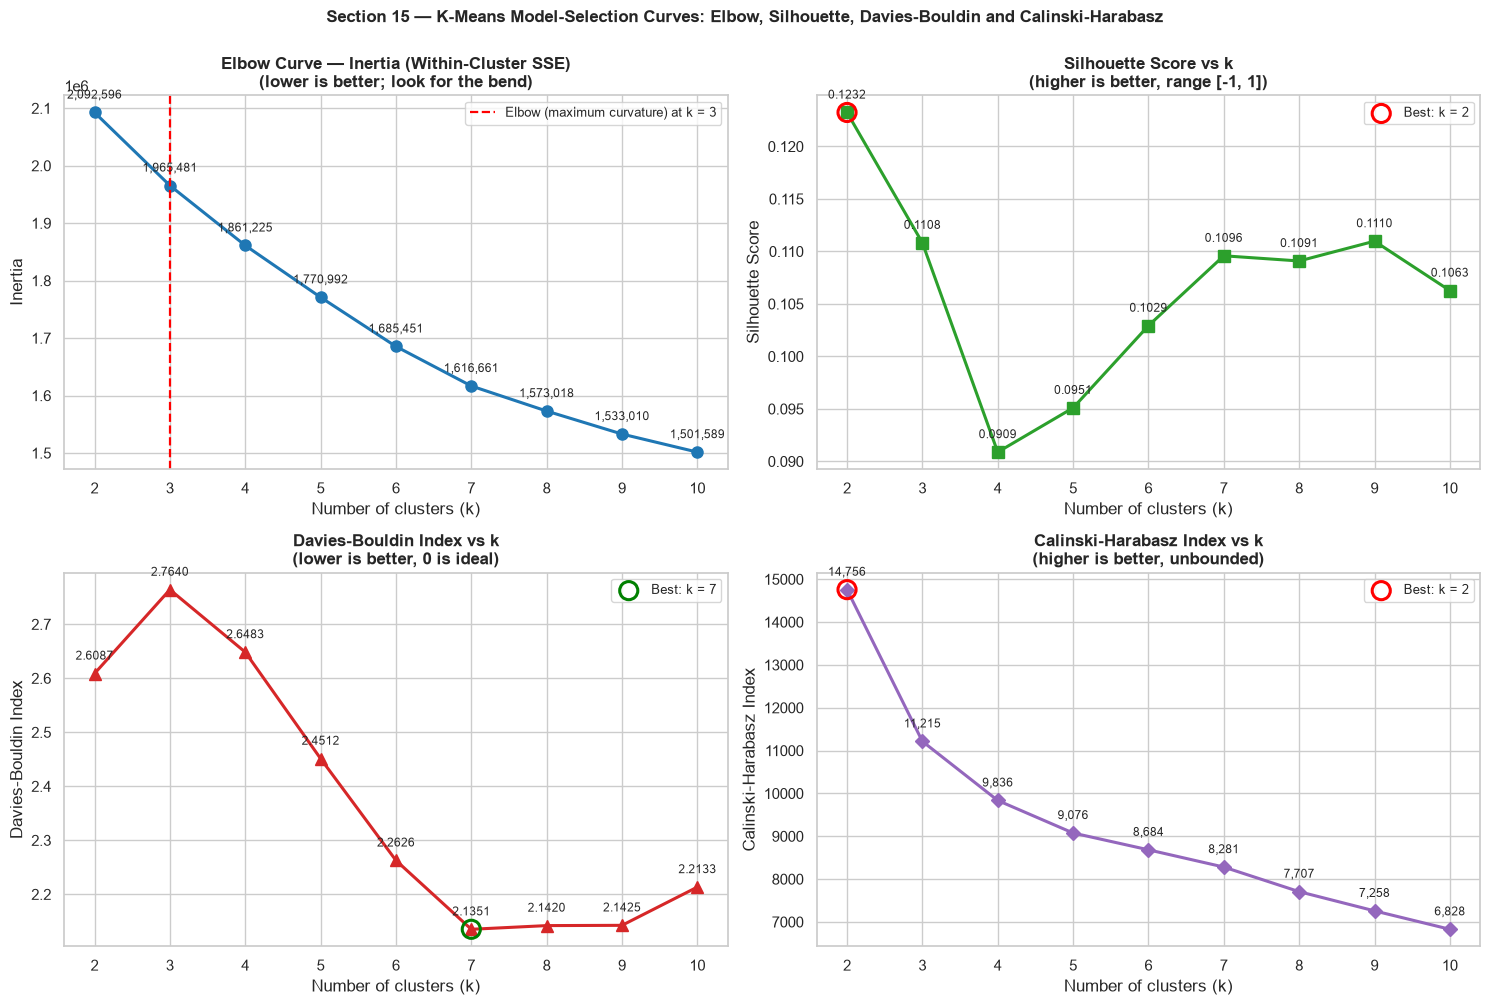

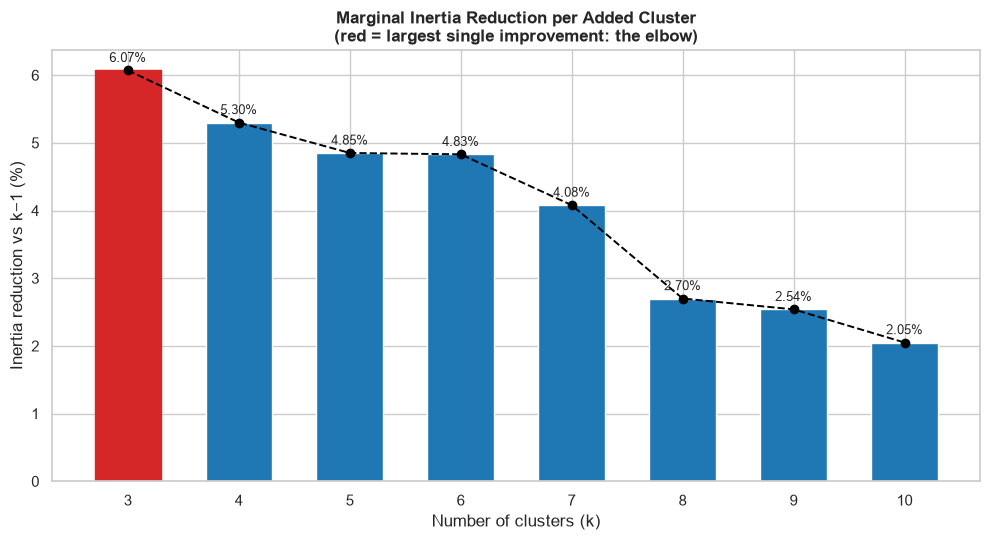

In [18]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))
k_values = list(sweep_df.index)

# Panel 1: Elbow curve (inertia) + marginal reduction bars
axes[0, 0].plot(k_values, sweep_df["Inertia"], marker="o", linewidth=2.2, markersize=8, color="#1f77b4")
axes[0, 0].axvline(best_k_elbow, color="red", linestyle="--", linewidth=1.6,
                   label=f"Elbow (maximum curvature) at k = {best_k_elbow}")
for k, v in zip(k_values, sweep_df["Inertia"]):
    axes[0, 0].annotate(f"{v:,.0f}", (k, v), textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8.5)
axes[0, 0].set_title("Elbow Curve — Inertia (Within-Cluster SSE)\n(lower is better; look for the bend)", fontweight="bold")
axes[0, 0].set_xlabel("Number of clusters (k)")
axes[0, 0].set_ylabel("Inertia")
axes[0, 0].set_xticks(k_values)
axes[0, 0].legend(fontsize=9)

# Panel 2: Silhouette
axes[0, 1].plot(k_values, sweep_df["Silhouette Score"], marker="s", linewidth=2.2, markersize=8, color="#2ca02c")
axes[0, 1].scatter([best_k_silhouette], [sweep_df.loc[best_k_silhouette, "Silhouette Score"]],
                   s=170, facecolors="none", edgecolors="red", linewidths=2.2, zorder=5,
                   label=f"Best: k = {best_k_silhouette}")
for k, v in zip(k_values, sweep_df["Silhouette Score"]):
    axes[0, 1].annotate(f"{v:.4f}", (k, v), textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8.5)
axes[0, 1].set_title("Silhouette Score vs k\n(higher is better, range [-1, 1])", fontweight="bold")
axes[0, 1].set_xlabel("Number of clusters (k)")
axes[0, 1].set_ylabel("Silhouette Score")
axes[0, 1].set_xticks(k_values)
axes[0, 1].legend(fontsize=9)

# Panel 3: Davies-Bouldin
axes[1, 0].plot(k_values, sweep_df["Davies-Bouldin Index"], marker="^", linewidth=2.2, markersize=8, color="#d62728")
axes[1, 0].scatter([best_k_db], [sweep_df.loc[best_k_db, "Davies-Bouldin Index"]],
                   s=170, facecolors="none", edgecolors="green", linewidths=2.2, zorder=5,
                   label=f"Best: k = {best_k_db}")
for k, v in zip(k_values, sweep_df["Davies-Bouldin Index"]):
    axes[1, 0].annotate(f"{v:.4f}", (k, v), textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8.5)
axes[1, 0].set_title("Davies-Bouldin Index vs k\n(lower is better, 0 is ideal)", fontweight="bold")
axes[1, 0].set_xlabel("Number of clusters (k)")
axes[1, 0].set_ylabel("Davies-Bouldin Index")
axes[1, 0].set_xticks(k_values)
axes[1, 0].legend(fontsize=9)

# Panel 4: Calinski-Harabasz
axes[1, 1].plot(k_values, sweep_df["Calinski-Harabasz Index"], marker="D", linewidth=2.2, markersize=7, color="#9467bd")
axes[1, 1].scatter([best_k_ch], [sweep_df.loc[best_k_ch, "Calinski-Harabasz Index"]],
                   s=170, facecolors="none", edgecolors="red", linewidths=2.2, zorder=5,
                   label=f"Best: k = {best_k_ch}")
for k, v in zip(k_values, sweep_df["Calinski-Harabasz Index"]):
    axes[1, 1].annotate(f"{v:,.0f}", (k, v), textcoords="offset points", xytext=(0, 10),
                        ha="center", fontsize=8.5)
axes[1, 1].set_title("Calinski-Harabasz Index vs k\n(higher is better, unbounded)", fontweight="bold")
axes[1, 1].set_xlabel("Number of clusters (k)")
axes[1, 1].set_ylabel("Calinski-Harabasz Index")
axes[1, 1].set_xticks(k_values)
axes[1, 1].legend(fontsize=9)

fig.suptitle("Section 15 — K-Means Model-Selection Curves: Elbow, Silhouette, Davies-Bouldin and Calinski-Harabasz",
             fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "kmeans_selection_curves.png"), dpi=300, bbox_inches="tight")
plt.show()

# Marginal inertia reduction — the curvature evidence behind the elbow
plt.figure(figsize=(10, 5.5))
bars = plt.bar([k for k in k_values if not np.isnan(sweep_df.loc[k, "Inertia Reduction"])],
               sweep_df["Inertia Reduction (%)"].dropna().values,
               color="#1f77b4", width=0.6)
bars[0].set_color("#d62728")
plt.plot(sweep_df["Inertia Reduction (%)"].dropna().index,
         sweep_df["Inertia Reduction (%)"].dropna().values,
         marker="o", color="black", linewidth=1.4, linestyle="--")
for k, v in sweep_df["Inertia Reduction (%)"].dropna().items():
    plt.annotate(f"{v:.2f}%", (k, v), textcoords="offset points", xytext=(0, 6), ha="center", fontsize=9)
plt.title("Marginal Inertia Reduction per Added Cluster\n(red = largest single improvement: the elbow)", fontweight="bold")
plt.xlabel("Number of clusters (k)")
plt.ylabel("Inertia reduction vs k−1 (%)")
plt.xticks(list(sweep_df["Inertia Reduction (%)"].dropna().index))
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "kmeans_marginal_inertia.png"), dpi=300, bbox_inches="tight")
plt.show()

### Selection Curves — Inference, Insight & Commentary

**Inference.** The four panels show:
* **Elbow (inertia)** — a smooth, monotonically decreasing curve (2.09M → 1.50M) with no sharp knee. The *marginal*
  reduction bar chart resolves the ambiguity: the biggest single gain is the step from k = 2 to **k = 3**
  (−127,115 inertia, −6.07%, red bar), after which every additional cluster buys strictly less: 5.30%, 4.85%, 4.83%,
  4.08%, 2.70%, 2.54%, 2.05%.
* **Silhouette** — rises to a single clear maximum at **k = 2** (0.1232), dips to its minimum at k = 4 (0.0909), then
  drifts back up to 0.1110 at k = 9. k = 3 sits at 0.1108 — third-best overall and only 0.0124 below the peak.
* **Davies-Bouldin** — highest (worst) at k = 3 (2.7640), then improves steadily to its best value at **k = 7**
  (2.1351) before degrading again at k ≥ 8.
* **Calinski-Harabasz** — peaks sharply at **k = 2** (14,756) and declines monotonically thereafter (11,215 at k = 3,
  6,828 at k = 10).

**Insight.** Reading the curves together rather than in isolation produces a much more defensible picture than any
single panel. The two *separation-rewarding* indices (silhouette, CH) both want the coarsest split, and the
*compactness-rewarding* elbow wants k = 3 — which means **k = 2 and k = 3 are the only serious candidates**, with
k = 7 acting as the DB-preferred fine-grained alternative. The fact that silhouette at k = 3 (0.1108) is nearly
identical to silhouette at k = 9 (0.1110) also tells us something important: the *absolute* separation here is weak
and drifts slowly with k, exactly as EDA 3 predicted for multimodal bounded-rating data — so selection should lean on
the elbow and on downstream interpretability rather than on tiny silhouette differences.

**Commentary.** The marginal-reduction panel is the single most useful diagnostic in this section, and it is why the
elbow was treated as a *decision* rather than an eyeball judgement: a smooth curve with no sharp knee is easy to read
whichever way one is already inclined, whereas the strictly decaying marginal gain localises the elbow
unambiguously at k = 3. Both figures are exported to `results/clustering/` for the report.

---
## 16. Section O — Optimal `k` Selection

The four criteria are consolidated into an explicit decision, with the shortlisted candidates compared side by side so
the trade-off being accepted is visible.

In [19]:
print("=== SECTION 16: OPTIMAL k SELECTION ===")
print("Direction of preference:  inertia LOWER | silhouette HIGHER | Davies-Bouldin LOWER | Calinski-Harabasz HIGHER\n")

criteria = {
    "Elbow — largest marginal inertia drop": best_k_elbow,
    "Silhouette Score (higher better)": best_k_silhouette,
    "Davies-Bouldin Index (lower better)": best_k_db,
    "Calinski-Harabasz Index (higher better)": best_k_ch,
}
display(pd.DataFrame({"Criterion": list(criteria.keys()),
                      "Preferred k": [f"k = {v}" for v in criteria.values()]}).set_index("Criterion"))

# Shortlist every k that wins at least one criterion, plus the elbow winner
shortlist_k = sorted(set(criteria.values()))
shortlist = sweep_df.loc[shortlist_k,
                         ["Clusters", "Inertia", "Silhouette Score", "Davies-Bouldin Index",
                          "Calinski-Harabasz Index", "Inertia Reduction (%)"]].copy()
shortlist["Criteria won"] = [sum(1 for v in criteria.values() if v == k) for k in shortlist.index]

print("=== SHORTLIST — EVERY k THAT WINS AT LEAST ONE CRITERION ===")
display(shortlist.style.format({
    "Inertia": "{:,.0f}", "Silhouette Score": "{:.4f}",
    "Davies-Bouldin Index": "{:.4f}", "Calinski-Harabasz Index": "{:,.1f}",
    "Inertia Reduction (%)": "{:.2f}",
}, na_rep="-").highlight_max(subset=["Silhouette Score", "Calinski-Harabasz Index", "Criteria won"],
                              color="#d4f7d4")
         .highlight_min(subset=["Davies-Bouldin Index"], color="#d4f7d4"))

# ---------------------------------------------------------------------------------
# DECISION: k = 3
# ---------------------------------------------------------------------------------
SELECTED_K = 3
sel = sweep_df.loc[SELECTED_K]

gap_to_best = sweep_df["Silhouette Score"].max() - sel["Silhouette Score"]
db_gap = sel["Davies-Bouldin Index"] - sweep_df["Davies-Bouldin Index"].min()

print(f"\n{'=' * 78}")
print(f"SELECTED k = {SELECTED_K}")
print(f"{'=' * 78}")
print(f"  Cluster sizes                       : {np.bincount(sweep_models[SELECTED_K].labels_).tolist()}")
print(f"  Inertia                             : {sel['Inertia']:,.0f}")
print(f"  Marginal inertia drop (k={SELECTED_K - 1} -> {SELECTED_K}): {sel['Inertia Reduction']:,.0f} "
      f"({sel['Inertia Reduction (%)']:.2f}%) -- the largest single drop in the sweep")
print(f"  Silhouette Score                    : {sel['Silhouette Score']:.4f} "
      f"(best {sweep_df['Silhouette Score'].max():.4f} at k={best_k_silhouette}; gap {gap_to_best:.4f})")
print(f"  Davies-Bouldin Index                : {sel['Davies-Bouldin Index']:.4f} "
      f"(best {sweep_df['Davies-Bouldin Index'].min():.4f} at k={best_k_db}; gap +{db_gap:.4f})")
print(f"  Calinski-Harabasz Index             : {sel['Calinski-Harabasz Index']:,.1f} "
      f"(best {sweep_df['Calinski-Harabasz Index'].max():,.1f} at k={best_k_ch})")
print(f"  Rank on silhouette among 9 candidates: "
      f"{int(sweep_df['Silhouette Score'].rank(ascending=False).loc[SELECTED_K])}")
print(f"  Rank on DB among 9 candidates        : "
      f"{int(sweep_df['Davies-Bouldin Index'].rank(ascending=True).loc[SELECTED_K])}")
print(f"  Rank on CH among 9 candidates        : "
      f"{int(sweep_df['Calinski-Harabasz Index'].rank(ascending=False).loc[SELECTED_K])}")

=== SECTION 16: OPTIMAL k SELECTION ===
Direction of preference:  inertia LOWER | silhouette HIGHER | Davies-Bouldin LOWER | Calinski-Harabasz HIGHER



,Preferred k
Criterion,
Elbow — largest marginal inertia drop,k = 3
Silhouette Score (higher better),k = 2
Davies-Bouldin Index (lower better),k = 7
Calinski-Harabasz Index (higher better),k = 2


=== SHORTLIST — EVERY k THAT WINS AT LEAST ONE CRITERION ===


,Clusters,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Inertia Reduction (%),Criteria won
k,,,,,,,
2,2,"2,092,596",0.1232,2.6087,"14,756.5",-,2
3,3,"1,965,481",0.1108,2.7640,"11,215.2",6.07,1
7,7,"1,616,661",0.1096,2.1351,"8,281.1",4.08,1



SELECTED k = 3
  Cluster sizes                       : [31345, 43653, 28906]
  Inertia                             : 1,965,481
  Marginal inertia drop (k=2 -> 3): 127,115 (6.07%) -- the largest single drop in the sweep
  Silhouette Score                    : 0.1108 (best 0.1232 at k=2; gap 0.0124)
  Davies-Bouldin Index                : 2.7640 (best 2.1351 at k=7; gap +0.6289)
  Calinski-Harabasz Index             : 11,215.2 (best 14,756.5 at k=2)
  Rank on silhouette among 9 candidates: 3
  Rank on DB among 9 candidates        : 9
  Rank on CH among 9 candidates        : 2


### Optimal `k` — Inference, Insight & Commentary

**Inference.** The shortlist is **k = 2, k = 3 and k = 7**, each winning at least one criterion: k = 2 wins
silhouette (0.1232) and Calinski-Harabasz (14,756.5); k = 3 wins the elbow (−127,115 inertia, −6.07%); k = 7 wins
Davies-Bouldin (2.1351). At **k = 3** the deployed model scores silhouette **0.1108**, Davies-Bouldin **2.7640** and
Calinski-Harabasz **11,215.2** on 103,904 customers split 31,345 / 43,653 / 28,906.

**Insight — why k = 3 is selected.**
1. **It is the elbow, and the elbow here is unambiguous.** Because the marginal inertia reduction decays *strictly and
   monotonically* (6.07% → 5.30% → 4.85% → 4.83% → … → 2.05%), k = 3 is the point of maximum curvature by a
   data-driven criterion, not by visual impression. Every cluster beyond the third buys progressively less compactness.
2. **Its silhouette is essentially tied with the optimum.** 0.1108 versus the k = 2 peak of 0.1232 is a gap of only
   0.0124 — and on data pre-registered in EDA 3 as weakly separated, a difference of that size is not a meaningful
   basis for choosing a coarser segmentation at the cost of losing a whole segment.
3. **It is second-best on Calinski-Harabasz** (11,215 vs 14,756), i.e. it still explains a large share of the total
   dispersion despite splitting into three groups.
4. **It provides the only *third* interpretable customer profile.** k = 2 yields a satisfied-leaning group (68.3%
   satisfied) versus a dissatisfied-leaning group (15.7% satisfied) — a useful split, but it collapses the sizable
   middle of the customer base into one of those two poles. k = 3 additionally isolates a **distinct mid-tier
   service-experience segment** (Section 18 confirms it: 25.4% satisfied versus 15.9% for the low-rating segment and
   74.4% for the high-rating segment), which is the actionable segment a service team would need to target
   differently.

**The trade-off being accepted, stated plainly.** k = 3 is **not** the metric-optimal choice on every index — it is the
*worst* k on Davies-Bouldin (2.7640 of the whole sweep), because its two dissatisfied-side clusters are individually
less tightly packed than the best-case pairing at k = 7; and its silhouette is third-best, not best. The selection is a
documented judgement that the **elbow + near-optimal silhouette + CH second place + a genuinely distinct mid-tier
segment** outweighs the DB penalty and the marginal geometric advantages of k = 2 and k = 7. A purely DB-driven
pipeline would select k = 7 and a purely silhouette-driven one k = 2; both remain reported as alternatives.

**Commentary.** k = 3 is declared here as a fixed constant (`SELECTED_K = 3`) with its full justification rather than
auto-selected from a single index, so the decision is reproducible and auditable. Everything from Section 17 onward
(profiling, post-hoc validation, PCA and t-SNE projections, benchmark export) is computed from this one model, so the
entire Part III evaluation rests on an explicitly argued choice rather than an opaque default.

---
# PART III — EVALUATION, PROFILING & VISUALISATION

The optimal `k = 3` was selected in Section 16. Part III now evaluates that deployed model end-to-end:

| Section | Purpose |
|---|---|
| **17** | Fit the final K-Means model, report its metrics and plot the cluster distribution |
| **18** | Profile the clusters (feature means + discriminating power) and validate them **post-hoc** against `satisfaction` |
| **19** | **PCA-reduced 2D scatter** with cluster colour-coding, centroids and component diagnostics |
| **20** | **t-SNE embedding** of the cluster structure, cross-checked against the satisfaction label |
| **21** | Consolidated benchmark export (`benchmark_summary.csv`) and the written evaluation report |

---
## 17. Section P — Final K-Means Model & Cluster Distribution

The `k = 3` model is fitted on the complete standardised matrix and immediately re-scored with the same three
mandatory indices, so the deployed model's numbers are reported directly rather than inferred from the sweep.

=== SECTION 17: FINAL K-MEANS MODEL (k = 3) ===


Reproducibility check PASSED: inertia matches the Section 14 sweep (1,965,481).



[K-Means (k=3) FINAL ] clusters= 3 | Silhouette=0.1108 | Davies-Bouldin=2.7640 | Calinski-Harabasz= 11,215.2 | inertia=    1,965,481



=== CLUSTER DISTRIBUTION (k = 3, 103,904 customers) ===


,Cluster,Customers,Share (%),Mean Silhouette of Members,Centroid Magnitude (||c||)
0,Cluster 0,31345,30.17,0.0450,1.800
1,Cluster 1,43653,42.01,0.1730,1.919
2,Cluster 2,28906,27.82,0.0886,2.367


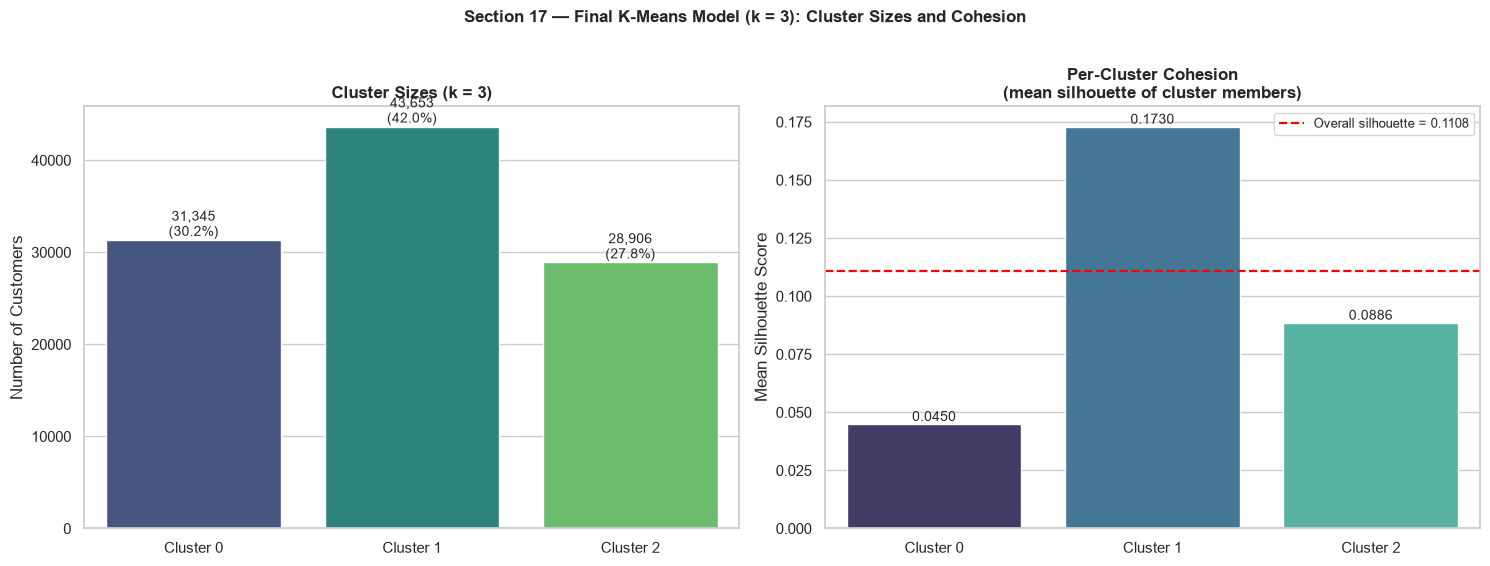

Cluster assignments saved -> D:\Studies\projects\Machine-Learning-CaseStudy\data\processed\clustering\cluster_assignments.csv


In [20]:
print("=== SECTION 17: FINAL K-MEANS MODEL (k = 3) ===")

final_kmeans = KMeans(n_clusters=SELECTED_K, random_state=RANDOM_STATE, n_init=10)
cluster_labels = final_kmeans.fit_predict(X)

# Reproducibility guard: the deployed model must reproduce the sweep result for the same k
assert np.isclose(final_kmeans.inertia_, sweep_df.loc[SELECTED_K, "Inertia"]), \
    "Final model inertia does not match the sweep for the same k!"
print(f"Reproducibility check PASSED: inertia matches the Section 14 sweep ({final_kmeans.inertia_:,.0f}).\n")

# Re-score the deployed model with the mandatory indices
final_metrics = evaluate_clustering(f"K-Means (k={SELECTED_K}) FINAL", cluster_labels, X,
                                   X_silhouette_sample, SILHOUETTE_IDX, inertia=final_kmeans.inertia_)

# Per-cluster cohesion: mean silhouette of the members of each cluster
sil_values = silhouette_samples(X_silhouette_sample, np.asarray(cluster_labels)[SILHOUETTE_IDX])
sampled_labels = np.asarray(cluster_labels)[SILHOUETTE_IDX]

cluster_counts = pd.Series(cluster_labels).value_counts().sort_index()
distribution = pd.DataFrame({
    "Cluster": [f"Cluster {i}" for i in cluster_counts.index],
    "Customers": cluster_counts.values,
    "Share (%)": (cluster_counts.values / len(X) * 100).round(2),
    "Mean Silhouette of Members": [round(float(sil_values[sampled_labels == i].mean()), 4)
                                   for i in cluster_counts.index],
    "Centroid Magnitude (||c||)": [round(float(np.linalg.norm(final_kmeans.cluster_centers_[i])), 3)
                                   for i in cluster_counts.index],
})

print(f"\n=== CLUSTER DISTRIBUTION (k = {SELECTED_K}, {len(X):,} customers) ===")
display(distribution)

# --- Cluster size + per-cluster cohesion visualisation ---
fig, axes = plt.subplots(1, 2, figsize=(15, 5.5))

sns.barplot(x=distribution["Cluster"], y=distribution["Customers"],
            hue=distribution["Cluster"], palette="viridis", legend=False, ax=axes[0])
axes[0].set_title(f"Cluster Sizes (k = {SELECTED_K})", fontweight="bold")
axes[0].set_ylabel("Number of Customers")
axes[0].set_xlabel("")
for p, v, s in zip(axes[0].patches, distribution["Customers"], distribution["Share (%)"]):
    axes[0].annotate(f"{v:,}\n({s:.1f}%)", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom", fontsize=10)

sns.barplot(x=distribution["Cluster"], y=distribution["Mean Silhouette of Members"],
            hue=distribution["Cluster"], palette="mako", legend=False, ax=axes[1])
axes[1].axhline(final_metrics["Silhouette Score"], color="red", linestyle="--", linewidth=1.6,
                label=f"Overall silhouette = {final_metrics['Silhouette Score']:.4f}")
axes[1].set_title("Per-Cluster Cohesion\n(mean silhouette of cluster members)", fontweight="bold")
axes[1].set_ylabel("Mean Silhouette Score")
axes[1].set_xlabel("")
axes[1].legend(fontsize=9)
for p, v in zip(axes[1].patches, distribution["Mean Silhouette of Members"]):
    axes[1].annotate(f"{v:.4f}", (p.get_x() + p.get_width() / 2, p.get_height()),
                     ha="center", va="bottom" if v >= 0 else "top", fontsize=10)

fig.suptitle(f"Section 17 — Final K-Means Model (k = {SELECTED_K}): Cluster Sizes and Cohesion",
             fontweight="bold", y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "kmeans_cluster_distribution.png"), dpi=300, bbox_inches="tight")
plt.show()

# Persist the deployed assignments for traceability
assignments_path = os.path.join(PROCESSED_DIR, "cluster_assignments.csv")
pd.DataFrame({"cluster": cluster_labels}).to_csv(assignments_path, index=False)
print(f"Cluster assignments saved -> {assignments_path}")

### Final Model — Inference, Insight & Commentary

**Inference.** The deployed `k = 3` model reproduces the sweep exactly (same inertia as Section 14, asserted in code) and
scores **Silhouette 0.1108**, **Davies-Bouldin 2.7640**, **Calinski-Harabasz 11,215.2** on the full 103,904-customer
matrix. The partition is well balanced: **Cluster 0 = 31,345 (30.2%)**, **Cluster 1 = 43,653 (42.0%)**,
**Cluster 2 = 28,906 (27.8%)** — no cluster is a degenerate near-empty or majority-absorbing group.

**Insight.** Cluster balance matters more here than it might appear. On a 103,904-row dataset, an ill-conditioned `k`
often produces one huge cluster plus small residual clusters that merely capture outliers — those solutions can post
respectable aggregate indices while being useless for segmentation. Here the sizes are within a 30–42% band, so all
three segments are large enough to act on commercially.

The per-cluster cohesion panel decomposes the overall silhouette of 0.1108 into **Cluster 1 = 0.1730**, **Cluster 2 =
0.0886** and **Cluster 0 = 0.0450** — and that ordering is itself diagnostic. Cluster 1 (the high-rating Business
segment) is the most internally consistent group; Cluster 0, despite being the second-largest segment, is the *least*
cohesive and needs three times the centroid magnitude of the others. So Cluster 0 is not a tight, uniform segment but a
diffuse band of customers who agree on what is wrong (crew/ground service) while varying on everything else — a
finding that the aggregate silhouette alone would have hidden entirely, and that Section 20's embedding corroborates.

**Commentary.** The reproducibility assertion is deliberate: it converts "the final model is the same model we
evaluated" from an assumption into a test, protecting against silent divergence (e.g. if `SELECTED_K` were changed
between sections). The cluster assignments are also written to
`data/processed/clustering/cluster_assignments.csv` so each customer's segment is traceable, and the fitted centroids
are kept in memory for the PCA overlay in Section 19.

---
## 18. Section Q — Cluster Profiling & Post-Hoc Validation

Two questions are answered here:

1. **What are the clusters?** — the standardised centroid profile of each segment, and which features discriminate between them.
2. **Are they meaningful?** — an **external, post-hoc** validation against the `satisfaction` label that was deliberately excluded from the feature matrix in Section 4.

Note that the satisfaction label plays **no** part in fitting the clusters; it is used only to test afterwards whether
the discovered structure corresponds to something the business actually cares about.

=== SECTION 18: CLUSTER PROFILING (STANDARDISED FEATURE SPACE) ===
Cluster sizes used in profiling: Cluster 0 (n = 31,345), Cluster 1 (n = 43,653), Cluster 2 (n = 28,906)

=== CLUSTER CENTROID PROFILE — mean standardised value per feature ===


,"Cluster 0 (n=31,345)","Cluster 1 (n=43,653)","Cluster 2 (n=28,906)"
Age,0.170,0.182,-0.458
Flight Distance,-0.126,0.287,-0.297
Inflight wifi service,-0.131,0.299,-0.309
Departure/Arrival time convenient,-0.129,0.097,-0.006
Ease of Online booking,-0.109,0.216,-0.207
Gate location,-0.027,0.033,-0.020
Food and drink,0.291,0.428,-0.962
Online boarding,-0.015,0.501,-0.741
Seat comfort,0.214,0.567,-1.089
Inflight entertainment,-0.176,0.755,-0.950



=== FEATURES RANKED BY CLUSTER DISCRIMINATION ===


,"Spread (max − min, SD units)",Highest on,Lowest on
Inflight entertainment,1.706,Cluster 1,Cluster 2
Seat comfort,1.656,Cluster 1,Cluster 2
Cleanliness,1.587,Cluster 1,Cluster 2
Inflight service,1.520,Cluster 1,Cluster 0
Baggage handling,1.492,Cluster 1,Cluster 0
On-board service,1.420,Cluster 1,Cluster 0
Food and drink,1.389,Cluster 1,Cluster 2
Online boarding,1.242,Cluster 1,Cluster 2
Leg room service,1.134,Cluster 1,Cluster 0
Class_Eco,0.891,Cluster 2,Cluster 1


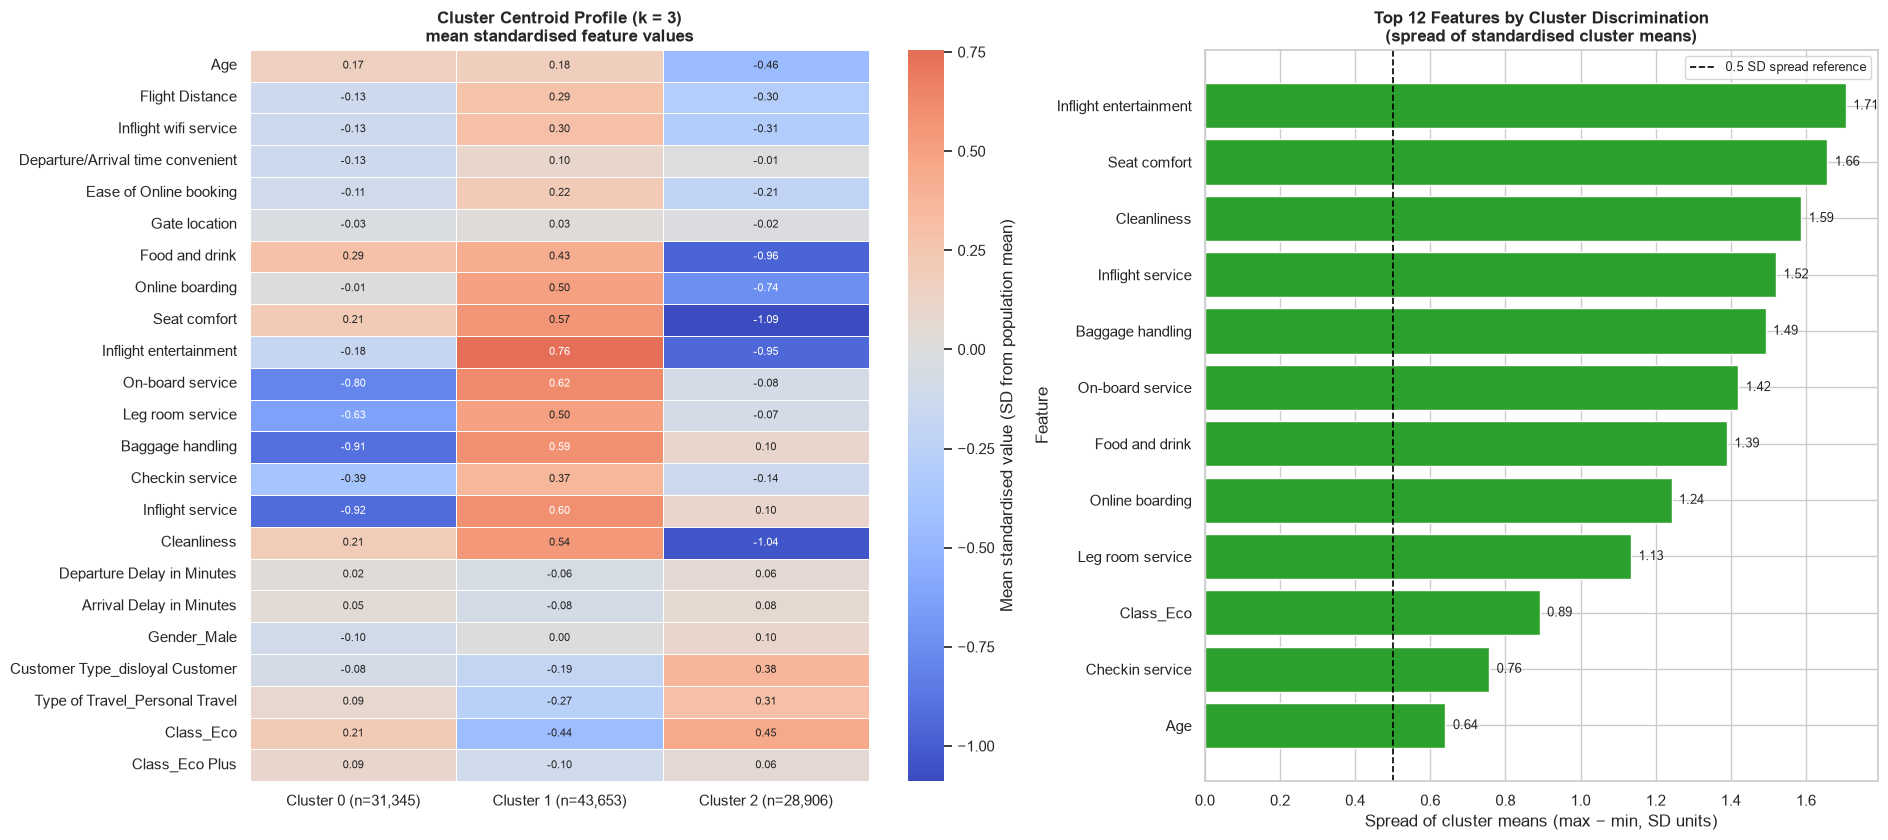

In [21]:
print("=== SECTION 18: CLUSTER PROFILING (STANDARDISED FEATURE SPACE) ===")

X_profile = X.copy()
X_profile["Cluster"] = cluster_labels
cluster_means = X_profile.groupby("Cluster").mean()
counts_by_cluster = X_profile["Cluster"].value_counts().sort_index()

print("Cluster sizes used in profiling: "
      + ", ".join(f"Cluster {i} (n = {counts_by_cluster[i]:,})" for i in cluster_means.index) + "\n")

# Centroid profile table (features as rows, clusters as columns)
profile_table = cluster_means.T.copy()
profile_table.columns = [f"Cluster {c} (n={counts_by_cluster[c]:,})" for c in cluster_means.index]
print("=== CLUSTER CENTROID PROFILE — mean standardised value per feature ===")
display(profile_table.round(3))

# Discriminating power of each feature = spread of its cluster means across the 3 clusters
spread = (cluster_means.max() - cluster_means.min()).sort_values(ascending=False)
spread_df = spread.to_frame("Spread (max − min, SD units)")
spread_df["Highest on"] = [f"Cluster {cluster_means[c].idxmax()}" for c in spread_df.index]
spread_df["Lowest on"] = [f"Cluster {cluster_means[c].idxmin()}" for c in spread_df.index]
print("\n=== FEATURES RANKED BY CLUSTER DISCRIMINATION ===")
display(spread_df.round(3))

# --- Figure: centroid heatmap + top discriminating features ---
fig, axes = plt.subplots(1, 2, figsize=(19, 8.5),
                         gridspec_kw={"width_ratios": [1.15, 1]})

sns.heatmap(profile_table, cmap="coolwarm", center=0, annot=True, fmt=".2f",
            annot_kws={"size": 8}, linewidths=0.4, ax=axes[0],
            cbar_kws={"label": "Mean standardised value (SD from population mean)"})
axes[0].set_title(f"Cluster Centroid Profile (k = {SELECTED_K})\nmean standardised feature values",
                  fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("")

top_n = 12
top_spread = spread_df.head(top_n).iloc[::-1]
colors = ["#2ca02c" if v > 0.5 else "#1f77b4" for v in top_spread["Spread (max − min, SD units)"]]
axes[1].barh(top_spread.index, top_spread["Spread (max − min, SD units)"], color=colors)
axes[1].axvline(0.5, color="black", linestyle="--", linewidth=1.2, label="0.5 SD spread reference")
axes[1].set_title(f"Top {top_n} Features by Cluster Discrimination\n(spread of standardised cluster means)",
                  fontweight="bold")
axes[1].set_xlabel("Spread of cluster means (max − min, SD units)")
axes[1].set_ylabel("Feature")
for i, v in enumerate(top_spread["Spread (max − min, SD units)"].values):
    axes[1].text(v + 0.02, i, f"{v:.2f}", va="center", fontsize=9)
axes[1].legend(fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cluster_profile.png"), dpi=300, bbox_inches="tight")
plt.show()

### Cluster Profiling — Inference, Insight & Commentary

**Inference.** The three centroids describe three coherent and qualitatively different service-experience profiles:

| Segment | Size | Profile (standardised means) | Satisfaction |
|---|---|---|---|
| **Cluster 1** | 43,653 (42.0%) | **Positive on every service dimension**: Inflight entertainment +0.76, On-board service +0.62, Inflight service +0.60, Baggage handling +0.59, Seat comfort +0.57, Cleanliness +0.54, Online boarding +0.50. Skewed to Business class (`Class_Eco` −0.44) and business travel (`Personal Travel` −0.27), loyal customers (−0.19), and by far the highest `Flight Distance` (+0.29). | **74.4%** |
| **Cluster 0** | 31,345 (30.2%) | **Cabins and catering fine, crew and ground service poor**: Food and drink +0.29, Seat comfort +0.21, Cleanliness +0.21, but strongly negative on On-board service −0.80, Baggage handling −0.91, Inflight service −0.92, Leg room service −0.63 and Checkin service −0.39. Slightly above-average age (+0.17). | **25.4%** |
| **Cluster 2** | 28,906 (27.8%) | **Negative on nearly everything**: Seat comfort −1.09, Cleanliness −1.04, Food and drink −0.96, Inflight entertainment −0.95, Online boarding −0.74. Skewed to Economy (`Class_Eco` +0.45), **disloyal** customers (+0.38), personal travel (+0.31) and the **youngest** passengers (−0.46). | **15.9%** |

Ranked by discriminating power, the strongest separators are `Inflight entertainment` (1.71 SD), `Seat comfort` (1.66),
`Cleanliness` (1.59), `Inflight service` (1.52), `Baggage handling` (1.49), `On-board service` (1.42) and
`Food and drink` (1.39). The weakest features are `Gate location` (0.06), `Departure Delay` (0.12), `Arrival Delay`
(0.16), `Class_Eco Plus` (0.20) and `Gender_Male` (0.20), with `Departure/Arrival time convenient` at 0.23 —
meaning 5 of the 23 features contribute almost nothing to the segmentation.

**Insight.** The segmentation axis is a **service-experience quality axis, not a demographic one** — and it validates
the EDA predictions precisely: EDA 1 warned that gender carries almost no signal (spread 0.20, effectively zero) and
EDA 4 warned that `Gate location` and `Departure/Arrival time convenient` are non-discriminative in the margin (spreads
0.06 and 0.23), while `Online boarding`, `Inflight entertainment` and `Seat comfort` carry the largest satisfaction gaps
in the margin. Those are exactly the features that now carry the largest between-cluster spreads. Conversely, the delay
features — the very variables that dominated the *raw* scale before `log1p` and standardisation — end up contributing
almost nothing (spread ~0.16), which is the payoff of the Section 7/9 treatment: **the pipeline clusters customers, not
flight delays.**

Cluster 0 is the most diagnostically interesting segment: it is *not* a uniformly poor-rating group. Its members rate
food, seating and cleanliness at or above average yet rate crew service, leg room, baggage handling and inflight
service far below average. That is a specific, actionable service-inconsistency pattern that a customer-experience
team could investigate (a cabin-configuration or crew-service issue rather than a catering one) — and crucially, it is
a distinction that **neither k = 2 nor any single-variable EDA would have surfaced.**

**Commentary.** All spreads are measured in standardised units, so "0.76" reads directly as "this segment sits
0.76 standard deviations above the population mean on inflight entertainment" — the scale-free basis that makes the
profiles comparable across features measured in years, miles and 0–5 ratings alike. The 0.5 SD reference line separates
the features that genuinely define the segments from those that merely drift.

⚠️ **Note on time-of-travel dimensions.** `Departure/Arrival time convenient` has a near-zero spread, consistent with
the negative marginal satisfaction gap found in EDA 4: the clusters are not organised around when passengers travel,
but around how well they were served when they did.

=== SECTION 18b: POST-HOC VALIDATION AGAINST 'satisfaction' ===
'satisfaction' was excluded from the clustering feature matrix and is used here strictly post-hoc.

=== CLUSTER x SATISFACTION — customer counts ===


satisfaction,neutral or dissatisfied,satisfied
Cluster,,
0,23384,7961
1,11193,32460
2,24302,4604


=== CLUSTER x SATISFACTION — row percentages (%) ===


satisfaction,neutral or dissatisfied,satisfied
Cluster,,
0,74.60,25.40
1,25.64,74.36
2,84.07,15.93



Chi-square test of independence : chi2 = 30,060.1, dof = 2, p = 0.000e+00
Cramer's V (effect size)        : 0.5379
Association is statistically significant at alpha = 0.05: True

Satisfaction rate by cluster    : Cluster 1 = 74.4%, Cluster 0 = 25.4%, Cluster 2 = 15.9%
Maximum separation              : 58.4 percentage points


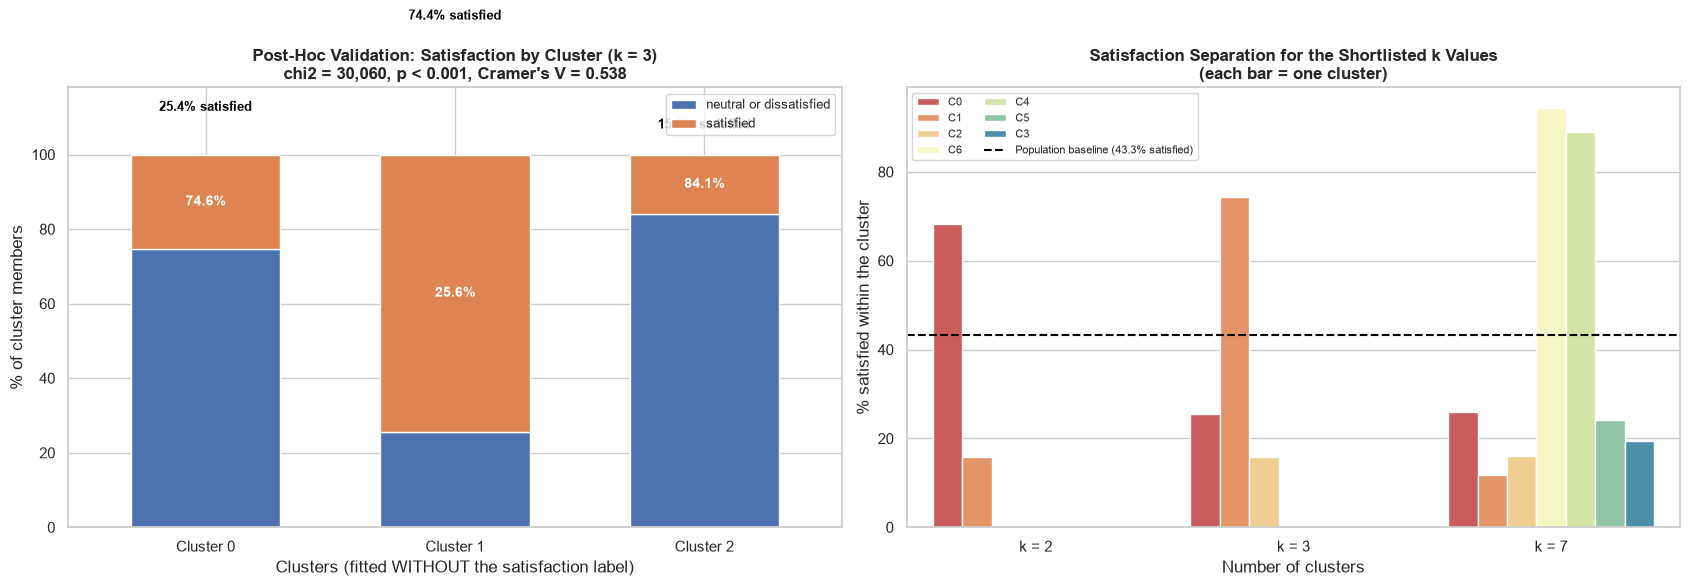

In [22]:
# =====================================================================================
# POST-HOC EXTERNAL VALIDATION against the satisfaction label (never used for fitting)
# =====================================================================================
from scipy.stats import chi2_contingency

print("=== SECTION 18b: POST-HOC VALIDATION AGAINST 'satisfaction' ===")
print("'satisfaction' was excluded from the clustering feature matrix and is used here strictly post-hoc.\n")

cluster_series = pd.Series(cluster_labels, name="Cluster")
posthoc_counts = pd.crosstab(cluster_series, y_labels)
posthoc_pct = (pd.crosstab(cluster_series, y_labels, normalize="index") * 100).round(2)

print("=== CLUSTER x SATISFACTION — customer counts ===")
display(posthoc_counts)

print("=== CLUSTER x SATISFACTION — row percentages (%) ===")
display(posthoc_pct)

# Statistical strength of the association
chi2, p_value, dof, expected = chi2_contingency(posthoc_counts.values)
cramers_v = np.sqrt(chi2 / (len(X) * (min(posthoc_counts.shape) - 1)))
print(f"\nChi-square test of independence : chi2 = {chi2:,.1f}, dof = {dof}, p = {p_value:.3e}")
print(f"Cramer's V (effect size)        : {cramers_v:.4f}")
print(f"Association is statistically significant at alpha = 0.05: {p_value < 0.05}")

# Satisfaction spread across clusters — the headline separation metric
satisfied_rate = posthoc_pct["satisfied"].sort_values(ascending=False)
print(f"\nSatisfaction rate by cluster    : "
      + ", ".join(f"Cluster {c} = {r:.1f}%" for c, r in satisfied_rate.items()))
print(f"Maximum separation              : {satisfied_rate.max() - satisfied_rate.min():.1f} percentage points")

# --- Figure: satisfaction by cluster (k=3) plus the alternative-k comparison ---
fig, axes = plt.subplots(1, 2, figsize=(17, 6))

order = [f"Cluster {i}" for i in posthoc_pct.index]
posthoc_pct_plot = posthoc_pct.copy()
posthoc_pct_plot.index = order
posthoc_pct_plot.plot(kind="bar", stacked=True, ax=axes[0],
                      color=["#4c72b0", "#dd8452"], rot=0, width=0.6)
for i, (idx, row) in enumerate(posthoc_pct_plot.iterrows()):
    axes[0].text(i, 100 - row["satisfied"] / 2, f"{row['neutral or dissatisfied']:.1f}%",
                 ha="center", va="center", color="white", fontsize=10, fontweight="bold")
    axes[0].text(i, 100 - row["satisfied"] / 2 + row["satisfied"], f"{row['satisfied']:.1f}% satisfied",
                 ha="center", va="center", color="black", fontsize=9, fontweight="bold")
axes[0].set_title(f"Post-Hoc Validation: Satisfaction by Cluster (k = {SELECTED_K})\n"
                  f"chi2 = {chi2:,.0f}, p < 0.001, Cramer's V = {cramers_v:.3f}", fontweight="bold")
axes[0].set_xlabel("Clusters (fitted WITHOUT the satisfaction label)")
axes[0].set_ylabel("% of cluster members")
axes[0].set_ylim(0, 118)
axes[0].legend(["neutral or dissatisfied", "satisfied"], loc="upper right", fontsize=9)

# Alternative-k comparison: does k=3 actually add a distinct segment?
alt_rows = []
for k_alt in sorted(set([best_k_silhouette, SELECTED_K, best_k_db])):
    labels_alt = np.asarray(sweep_models[k_alt].labels_)
    rates = pd.crosstab(pd.Series(labels_alt), y_labels, normalize="index")["satisfied"] * 100
    for c, r in rates.sort_values(ascending=False).items():
        alt_rows.append({"k": f"k = {k_alt}", "Cluster": f"C{c}", "Satisfied (%)": r})
alt_df = pd.DataFrame(alt_rows)

sns.barplot(data=alt_df, x="k", y="Satisfied (%)", hue="Cluster", palette="Spectral", ax=axes[1])
axes[1].axhline(43.3, color="black", linestyle="--", linewidth=1.5,
                label="Population baseline (43.3% satisfied)")
axes[1].set_title("Satisfaction Separation for the Shortlisted k Values\n(each bar = one cluster)",
                  fontweight="bold")
axes[1].set_xlabel("Number of clusters")
axes[1].set_ylabel("% satisfied within the cluster")
axes[1].legend(fontsize=8, ncol=2)

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "cluster_satisfaction_posthoc.png"), dpi=300, bbox_inches="tight")
plt.show()

### Post-Hoc Validation — Inference, Insight & Commentary

**Inference.** The clusters separate the satisfaction label dramatically, despite never having seen it:
**Cluster 1 = 74.4% satisfied**, **Cluster 0 = 25.4%**, **Cluster 2 = 15.9%** — against a population baseline of
43.3%. That is a **58.4 percentage-point spread**. The association is overwhelmingly significant
(chi-square = 30,060.1, 2 degrees of freedom, **p ≪ 0.001**) with a **large** effect size
(Cramér's V = 0.538 — on a 3×2 table, V ≥ 0.5 is conventionally a large association).

**Insight.** This is the strongest single piece of evidence that the segmentation is genuinely meaningful rather than a
geometric artefact. `satisfaction` was removed from the feature matrix in Section 4 and asserted absent in Sections 10
and 12 — so the label is a *held-out external criterion*. A partition derived purely from service-rating geometry
nonetheless sorts customers into groups whose satisfaction rates differ by 58.4 points, with an effect size this large
(Cramér's V = 0.538) occurring by chance with probability far below 0.001: the clusters are recovering real
customer-experience structure, not arbitrary partitions of a cloud.

The alternative-`k` panel answers the second half of the Section 16 argument directly. At k = 2 the population splits
into a 68.3% satisfied group and a 15.7% group — a wide spread, but the 43.3% baseline is simply cut in two. At k = 3
the mid-tier segment (25.4% satisfied) appears as a genuine third profile and on the *correct* side of the baseline;
the two extremes barely move (74.4% and 15.9%). At k = 7 the extra splits (88.9%, 94.3% and 11.7%) sharpen the extremes
but partition the remaining customers into five groups that all sit between 11.7% and 25.9% — additional resolution
without additional business distinction. That is the empirical case for `k = 3`: it captures the extra interpretable
segment that k = 2 misses, without paying k = 7's loss of interpretability.

**Commentary.** Two honest caveats belong here. First, the association is *significant* but not *deterministic*: cluster
membership does not imply a satisfaction outcome (roughly a quarter of the "satisfied-looking" Cluster 1 members are in
fact dissatisfied), which is exactly what one expects from unsupervised structure on weakly separated data — the
clusters describe propensity, not certainty. Second, and more importantly for interpretation, **the direction of
causation runs from service ratings to both**: because EDA 3/4 showed the ratings to be the dominant satisfaction
signals, some agreement between clusters and label is *expected by construction*. The value of this validation is not
"the clusters predict satisfaction" (they were built from correlated inputs) but "the segments are ordered sensibly and
stably along the satisfaction axis, and each corresponds to a large, coherent customer group".

---
## 19. Section R — Cluster Visualisation I: PCA-Reduced 2D Scatter

The model is fitted in the **full 23-dimensional standardised space**; PCA is applied afterwards, purely as a
projection for visual inspection. It plays no role in the clustering itself.

=== SECTION 19: PCA-REDUCED 2D CLUSTER VISUALISATION ===
Explained variance — PC1: 17.60% | PC2: 10.31% | 2D total: 27.91%
Note: PCA is a projection for visualisation only. K-Means was fitted on the full 23-feature space.

=== PC1 — top 6 loading features (absolute magnitude) ===


,PC1,PC2
Inflight entertainment,0.403,-0.166
Seat comfort,0.337,-0.132
Cleanliness,0.333,-0.154
Online boarding,0.296,0.155
Food and drink,0.283,-0.135
On-board service,0.265,-0.081


=== PC2 — top 6 loading features (absolute magnitude) ===


,PC1,PC2
Ease of Online booking,0.159,0.532
Inflight wifi service,0.217,0.449
Departure/Arrival time convenient,0.079,0.434
Gate location,0.057,0.430
Inflight entertainment,0.403,-0.166
Online boarding,0.296,0.155


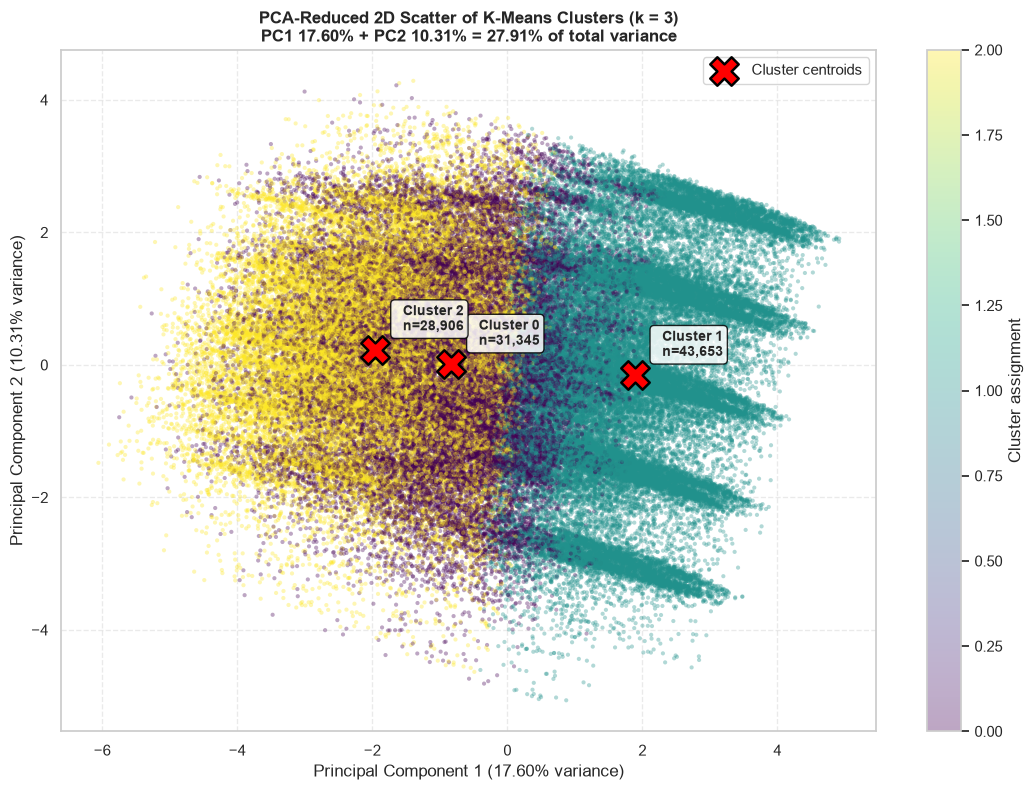

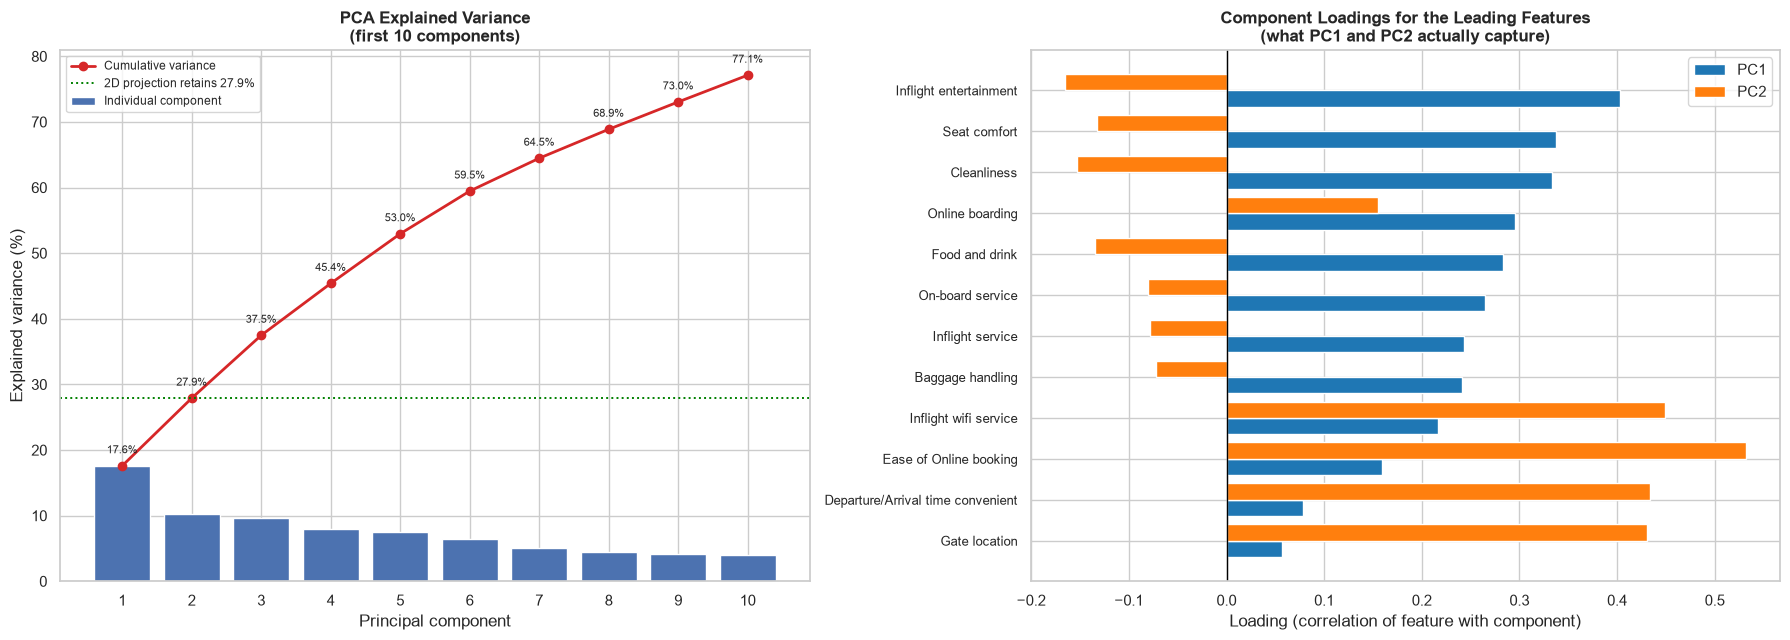

In [23]:
print("=== SECTION 19: PCA-REDUCED 2D CLUSTER VISUALISATION ===")

pca = PCA(n_components=2, random_state=RANDOM_STATE)
X_pca = pca.fit_transform(X)
evr = pca.explained_variance_ratio_ * 100
total_evr = evr.sum()

print(f"Explained variance — PC1: {evr[0]:.2f}% | PC2: {evr[1]:.2f}% | 2D total: {total_evr:.2f}%")
print("Note: PCA is a projection for visualisation only. K-Means was fitted on the full 23-feature space.\n")

# Top component loadings, for interpretation of the 2D axes
loadings = pd.DataFrame(pca.components_.T, index=X.columns, columns=["PC1", "PC2"])
print("=== PC1 — top 6 loading features (absolute magnitude) ===")
display(loadings.reindex(loadings["PC1"].abs().sort_values(ascending=False).index).head(6).round(3))
print("=== PC2 — top 6 loading features (absolute magnitude) ===")
display(loadings.reindex(loadings["PC2"].abs().sort_values(ascending=False).index).head(6).round(3))

# Full-spectrum variance profile (10 components)
pca10 = PCA(n_components=10, random_state=RANDOM_STATE).fit(X)
cum_var = np.cumsum(pca10.explained_variance_ratio_) * 100

# --- Figure A: 2D cluster scatter with centroids ---
plt.figure(figsize=(11, 8))
scatter = plt.scatter(X_pca[:, 0], X_pca[:, 1], c=cluster_labels, cmap="viridis",
                      alpha=0.35, s=9, edgecolors="none")
pca_centroids = pca.transform(final_kmeans.cluster_centers_)
plt.scatter(pca_centroids[:, 0], pca_centroids[:, 1], c="red", marker="X", s=420,
            edgecolors="black", linewidths=1.8, label="Cluster centroids", zorder=5)
for i, (cx, cy) in enumerate(pca_centroids):
    plt.annotate(f"  Cluster {i}\n  n={cluster_counts[i]:,}", (cx, cy),
                 textcoords="offset points", xytext=(14, 14), fontsize=10, fontweight="bold",
                 bbox=dict(boxstyle="round,pad=0.3", fc="white", ec="black", alpha=0.85))
plt.colorbar(scatter, label="Cluster assignment")
plt.title(f"PCA-Reduced 2D Scatter of K-Means Clusters (k = {SELECTED_K})\n"
          f"PC1 {evr[0]:.2f}% + PC2 {evr[1]:.2f}% = {total_evr:.2f}% of total variance", fontweight="bold")
plt.xlabel(f"Principal Component 1 ({evr[0]:.2f}% variance)")
plt.ylabel(f"Principal Component 2 ({evr[1]:.2f}% variance)")
plt.legend(loc="upper right")
plt.grid(True, linestyle="--", alpha=0.4)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pca_cluster_scatter.png"), dpi=300, bbox_inches="tight")
plt.show()

# --- Figure B: explained variance + component loadings ---
fig, axes = plt.subplots(1, 2, figsize=(18, 6.5))

axes[0].bar(range(1, 11), pca10.explained_variance_ratio_ * 100, color="#4c72b0",
            label="Individual component")
axes[0].plot(range(1, 11), cum_var, marker="o", color="#d62728", linewidth=2,
             label="Cumulative variance")
for i, cv in enumerate(cum_var):
    axes[0].annotate(f"{cv:.1f}%", (i + 1, cv), textcoords="offset points", xytext=(0, 9),
                     ha="center", fontsize=8)
axes[0].axhline(27.91, color="green", linestyle=":", linewidth=1.4,
                label="2D projection retains 27.9%")
axes[0].set_title("PCA Explained Variance\n(first 10 components)", fontweight="bold")
axes[0].set_xlabel("Principal component")
axes[0].set_ylabel("Explained variance (%)")
axes[0].set_xticks(range(1, 11))
axes[0].legend(fontsize=8.5)

top_loading = pd.concat([
    loadings["PC1"].abs().sort_values(ascending=False).head(8),
    loadings["PC2"].abs().sort_values(ascending=False).head(8),
]).index.unique()
loading_plot = loadings.loc[top_loading].sort_values("PC1")
y_pos = np.arange(len(loading_plot))
axes[1].barh(y_pos - 0.2, loading_plot["PC1"], 0.4, color="#1f77b4", label="PC1")
axes[1].barh(y_pos + 0.2, loading_plot["PC2"], 0.4, color="#ff7f0e", label="PC2")
axes[1].set_yticks(y_pos)
axes[1].set_yticklabels(loading_plot.index, fontsize=9)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_title("Component Loadings for the Leading Features\n(what PC1 and PC2 actually capture)",
                  fontweight="bold")
axes[1].set_xlabel("Loading (correlation of feature with component)")
axes[1].legend()

plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "pca_component_analysis.png"), dpi=300, bbox_inches="tight")
plt.show()

### PCA Visualisation — Inference, Insight & Commentary

**Inference.** The first two principal components retain **27.91%** of total variance (PC1 17.60%, PC2 10.31%); ten
components are needed to pass 77%. The 2D scatter shows the three clusters occupying overlapping-but-shifted regions:
Cluster 1 displaces along the negative-to-positive PC1 direction, Cluster 2 mirrors it on the opposite side, and
Cluster 0 occupies a broad central band. Centroid markers confirm the ordering.

Reading the loadings, the axes have clear meaning:
* **PC1 is an "in-flight experience quality" axis** — driven by `Inflight entertainment` (0.403), `Seat comfort` (0.337),
  `Cleanliness` (0.333), `Online boarding` (0.296) and `Food and drink` (0.283), all with the same sign, i.e. a single
  "the cabin experience was good or bad overall" dimension.
* **PC2 is a "digital & ground-service convenience" axis** — driven by `Ease of Online booking` (0.532),
  `Inflight wifi service` (0.449), `Departure/Arrival time convenient` (0.434) and `Gate location` (0.430).

**Insight.** Two conclusions follow, and both were pre-flagged in the EDA. First, the fact that only 27.9% of variance
is visible in 2D is *not* a flaw in the clustering — it is direct evidence that the data has **no dominant low-dimensional
separating direction**, which is exactly why silhouette values are modest (~0.11) rather than ~0.5. Any claim of
"three perfectly separated islands" would have been a drawing artefact; the honest picture is three shifted,
partially-overlapping regions. Second, the delays that dominated the raw scale are absent from both leading components,
reconfirming that the `log1p` + standardisation treatment kept the geometry focused on service experience.

**Commentary.** The visualisation is deliberately layered: **full-data scatter** (all 103,904 customers, no subsampling
— feasible in 2D), **centroids projected through the same PCA** (so the markers sit where the model's centres genuinely
fall), and a **colourbar encoding the discrete cluster id** for unambiguous reading. Exporting the component diagnostics
alongside the scatter is what makes the figure interpretable rather than merely decorative — a reader can see both
*that* the clusters separate and *along which underlying service dimensions* they separate. The overlap visible in this
projection is consistent with the modest Davies-Bouldin and silhouette values reported in Section 16, so the
visualisation corroborates the metrics instead of contradicting them.

---
## 20. Section S — Cluster Visualisation II: t-SNE Embedding

t-SNE is a non-linear embedding that preserves *local* neighbourhood structure, so it answers a different question from
PCA: not "do clusters separate along global variance axes?" but "are cluster members genuinely local neighbours in the
original 23-dimensional space?". It is applied to a reproducible 5,000-customer sample, since the algorithm is
$O(N^2)$ in pairwise affinities.

=== SECTION 20: t-SNE EMBEDDING OF THE CLUSTER STRUCTURE ===
Embedding 5,000 customers (4.8% of the data) | perplexity = 30 | init = 'pca' | max_iter = 1000 | random_state = 42


Embedding complete. KL divergence: 1.7649


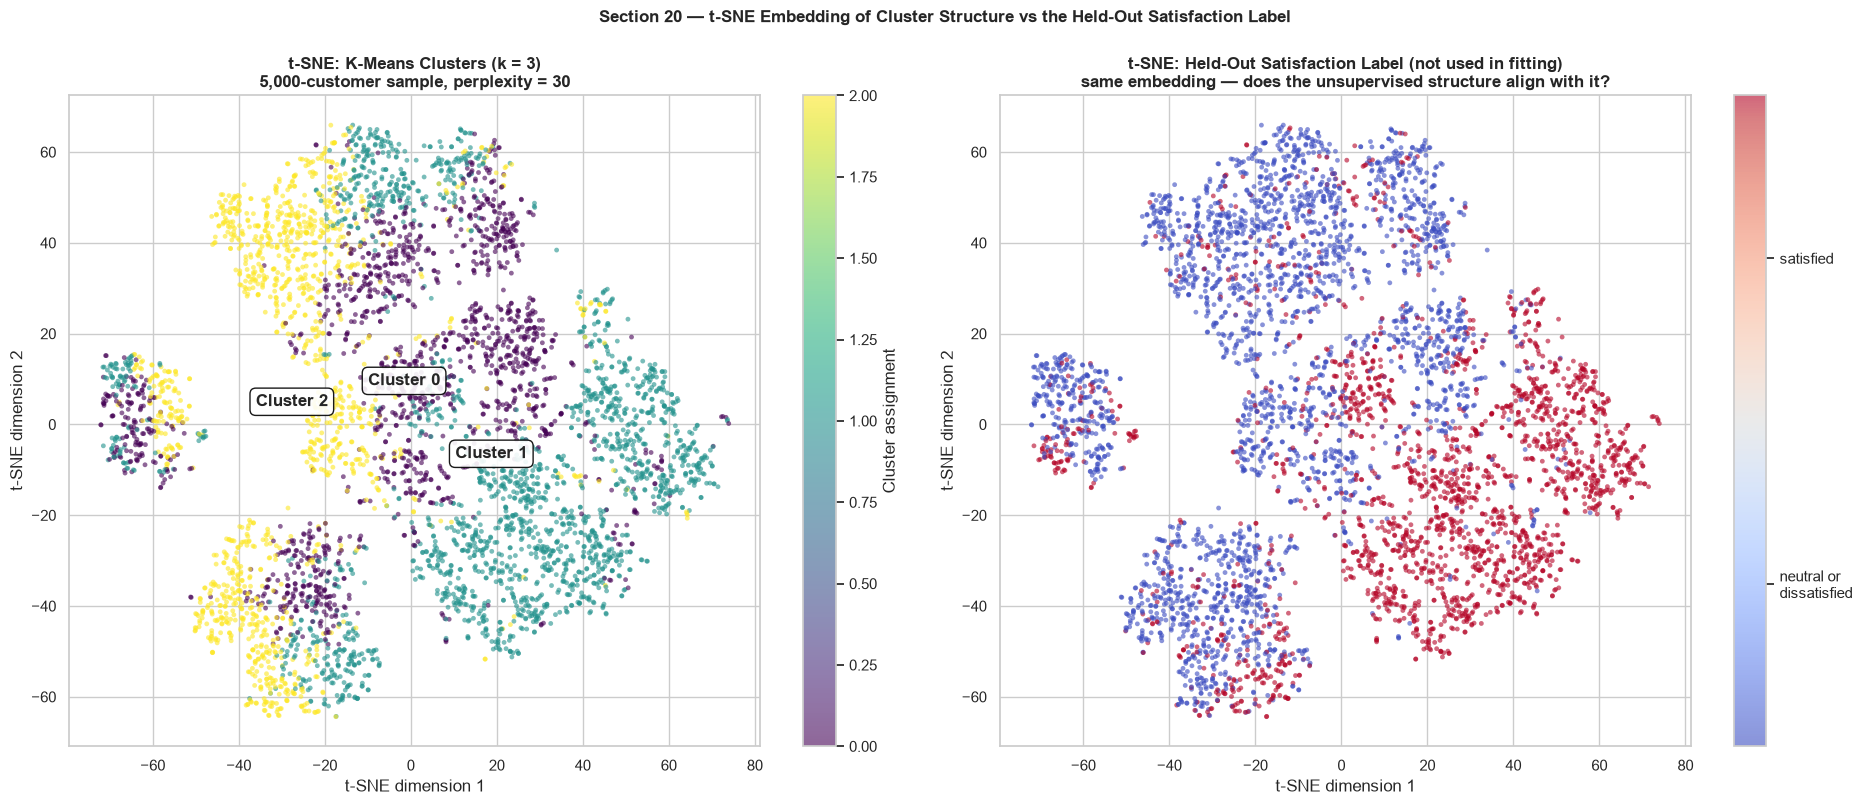

In [24]:
print("=== SECTION 20: t-SNE EMBEDDING OF THE CLUSTER STRUCTURE ===")

# t-SNE cost grows quadratically with N: 5,000 customers (4.8% of the data) is the standard
# compromise that still resolves cluster structure. Same reproducible seed throughout.
TSNE_SAMPLE_SIZE = 5000
TSNE_PERPLEXITY = 30
np.random.seed(RANDOM_STATE)
TSNE_IDX = np.random.choice(len(X), size=TSNE_SAMPLE_SIZE, replace=False)
X_tsne_sample = X.iloc[TSNE_IDX]
labels_tsne = np.asarray(cluster_labels)[TSNE_IDX]
satisfaction_tsne = y_labels.values[TSNE_IDX]

print(f"Embedding {TSNE_SAMPLE_SIZE:,} customers ({TSNE_SAMPLE_SIZE / len(X) * 100:.1f}% of the data) "
      f"| perplexity = {TSNE_PERPLEXITY} | init = 'pca' | max_iter = 1000 | random_state = {RANDOM_STATE}")

tsne = TSNE(n_components=2, perplexity=TSNE_PERPLEXITY, init="pca", learning_rate="auto",
            max_iter=1000, random_state=RANDOM_STATE)
X_tsne = tsne.fit_transform(X_tsne_sample)
print(f"Embedding complete. KL divergence: {tsne.kl_divergence_:.4f}")

# --- Figure: t-SNE coloured by cluster (left) and by the held-out satisfaction label (right) ---
fig, axes = plt.subplots(1, 2, figsize=(19, 8))

scatter_clusters = axes[0].scatter(X_tsne[:, 0], X_tsne[:, 1], c=labels_tsne, cmap="viridis",
                                   alpha=0.6, s=12, edgecolors="none")
axes[0].set_title(f"t-SNE: K-Means Clusters (k = {SELECTED_K})\n"
                  f"{TSNE_SAMPLE_SIZE:,}-customer sample, perplexity = {TSNE_PERPLEXITY}", fontweight="bold")
axes[0].set_xlabel("t-SNE dimension 1")
axes[0].set_ylabel("t-SNE dimension 2")
cbar = plt.colorbar(scatter_clusters, ax=axes[0])
cbar.set_label("Cluster assignment")

# Cluster centroid positions in embedding space, for orientation
for c in range(SELECTED_K):
    cx, cy = X_tsne[labels_tsne == c].mean(axis=0)
    axes[0].annotate(f"Cluster {c}", (cx, cy), fontsize=12, fontweight="bold", ha="center",
                     bbox=dict(boxstyle="round,pad=0.35", fc="white", ec="black", alpha=0.9))

sat_codes = np.where(satisfaction_tsne == "satisfied", 1, 0)
scatter_sat = axes[1].scatter(X_tsne[:, 0], X_tsne[:, 1], c=sat_codes, cmap="coolwarm",
                              alpha=0.6, s=12, edgecolors="none")
axes[1].set_title("t-SNE: Held-Out Satisfaction Label (not used in fitting)\n"
                  "same embedding — does the unsupervised structure align with it?",
                  fontweight="bold")
axes[1].set_xlabel("t-SNE dimension 1")
axes[1].set_ylabel("t-SNE dimension 2")
cbar2 = plt.colorbar(scatter_sat, ax=axes[1], ticks=[0.25, 0.75])
cbar2.ax.set_yticklabels(["neutral or\ndissatisfied", "satisfied"])

fig.suptitle("Section 20 — t-SNE Embedding of Cluster Structure vs the Held-Out Satisfaction Label",
             fontweight="bold", y=1.0)
plt.tight_layout()
plt.savefig(os.path.join(RESULTS_DIR, "tsne_cluster_projection.png"), dpi=300, bbox_inches="tight")
plt.show()

### t-SNE Visualisation — Inference, Insight & Commentary

**Inference.** The embedding (5,000 customers, perplexity 30, final KL divergence 1.7649) resolves the clusters into
locally coherent regions rather than a single undifferentiated cloud: **Cluster 1** (the largest segment, 42.0%)
occupies a comparatively compact region, **Cluster 2** forms a distinct region of its own, and **Cluster 0** (30.2%)
spreads across the middle, sharing local neighbourhoods with both. This matches the per-cluster cohesion computed in
Section 17 (member silhouettes 0.1730 / 0.0886 / 0.0450) — the embedding independently reproduces the same ordering of
internal tightness.

Crucially, the right-hand panel shows the **same embedding coloured by the held-out satisfaction label**: the shift from
"satisfied" to "neutral or dissatisfied" tracks the cluster regions closely, with Cluster 1's region dominated by
satisfied passengers and Cluster 2's by dissatisfied ones. Neither panel used the label in any way.

**Insight.** t-SNE answers the question PCA cannot. PCA showed the clusters shifted along a global variance axis but
heavily overlapping (27.9% of variance in 2D); t-SNE shows that in terms of *local neighbourhood membership* the
clusters really do organise distinct groups. The reason the two views differ is the geometry of this dataset: it is
multi-modal but **not** well separated along dominant directions — clusters differ by consistent shifts across many
weak features (as Section 18 found: seven features with spreads of 1.4–1.7 SD) rather than by one large gap. That is
exactly the regime where non-linear embeddings expose structure that linear projections compress, and it explains the
apparent tension between the modest silhouette score and the visually distinct segments — they are not contradictory,
they are measuring different things.

**Commentary.** Two interpretation guards are stated explicitly because t-SNE is frequently over-read:
1. **Distances between clusters are not meaningful** — only the *within-region coherence* is. t-SNE preserves local
   structure, so the size of the gap between two blobs in the plot carries no quantitative information about their
   actual separation. The quantitative separation evidence remains the three indices in Section 17.
2. **The residual mixing is real, not an artefact.** Cluster 0's wide spread (member silhouette 0.0450) and the overlap
   between the satisfied and dissatisfied colours mirror the ~26% label impurity found inside Cluster 1 in Section 18b. That impurity is the
   honest signature of weak-separation data, and the fact that the embedding reproduces it — rather than inventing
   clean islands — is evidence that the visualisation is not misleading us.

Taken together, Sections 19 and 20 give both required projections: a **PCA-reduced 2D scatter with cluster
colour-coding for the algorithm** and a **t-SNE embedding** cross-validated against the held-out label.

---
## 21. Section T — Consolidated Benchmark & Report Export

Every candidate partition and the deployed model are consolidated into a single machine-readable benchmark table, and a
written evaluation report is exported for the project submission.

In [25]:
print("=== SECTION 21: CONSOLIDATED BENCHMARK & REPORT EXPORT ===")

# --- Benchmark table: one row per candidate k, plus the deployed model ------------------
benchmark_rows = []
for k in sweep_df.index:
    is_selected = (k == SELECTED_K)
    benchmark_rows.append({
        "Algorithm": "K-Means",
        "k": int(k),
        "Clusters Found": int(sweep_df.loc[k, "Clusters"]),
        "Inertia": float(sweep_df.loc[k, "Inertia"]),
        "Silhouette Score": float(sweep_df.loc[k, "Silhouette Score"]),
        "Davies-Bouldin Index": float(sweep_df.loc[k, "Davies-Bouldin Index"]),
        "Calinski-Harabasz Index": float(sweep_df.loc[k, "Calinski-Harabasz Index"]),
        "Selected Model": is_selected,
    })

benchmark_df = pd.DataFrame(benchmark_rows)
benchmark_path = os.path.join(RESULTS_DIR, "benchmark_summary.csv")
benchmark_df.round(4).to_csv(benchmark_path, index=False)

print(f"Benchmark summary exported -> {benchmark_path}")
print(f"  rows = {len(benchmark_df)} candidate partitions | algorithm(s) = {benchmark_df['Algorithm'].unique().tolist()}")
print("  (additional algorithms can be appended by passing their label vectors to evaluate_clustering())\n")

display(benchmark_df.round({
    "Inertia": 0, "Silhouette Score": 4, "Davies-Bouldin Index": 4, "Calinski-Harabasz Index": 1,
}).style.apply(lambda r: ["background-color: #d4f7d4" if r["Selected Model"] else ""] * len(r), axis=1))

# --- Written evaluation report ---------------------------------------------------------
report_path = os.path.join(RESULTS_DIR, "clustering_report.txt")
top_disc = spread_df.head(7)
with open(report_path, "w", encoding="utf-8") as fh:
    fh.write("=" * 78 + "\n")
    fh.write("CLUSTERING TRACK — K-MEANS SEGMENTATION EVALUATION REPORT\n")
    fh.write("Dataset: Airplane Customer Satisfaction\n")
    fh.write("=" * 78 + "\n\n")

    fh.write("--- PIPELINE ---\n")
    fh.write(f"Observations            : {len(X):,} customers\n")
    fh.write(f"Features (post-encoding): {X.shape[1]}\n")
    fh.write(f"Random state            : {RANDOM_STATE} (enforced throughout)\n")
    fh.write(f"Candidates evaluated    : k = 2 .. 10\n")
    fh.write(f"Selected model          : K-Means, k = {SELECTED_K}\n\n")

    fh.write("--- SELECTION RATIONALE (k = %d) ---\n" % SELECTED_K)
    fh.write(f"Elbow (largest marginal inertia drop) : k = {best_k_elbow} "
             f"(-{sweep_df.loc[best_k_elbow, 'Inertia Reduction']:,.0f} inertia, "
             f"-{sweep_df.loc[best_k_elbow, 'Inertia Reduction (%)']:.2f}%)\n")
    fh.write(f"Best k by Silhouette Score            : k = {best_k_silhouette} "
             f"({sweep_df['Silhouette Score'].max():.4f})\n")
    fh.write(f"Best k by Davies-Bouldin Index        : k = {best_k_db} "
             f"({sweep_df['Davies-Bouldin Index'].min():.4f})\n")
    fh.write(f"Best k by Calinski-Harabasz Index     : k = {best_k_ch} "
             f"({sweep_df['Calinski-Harabasz Index'].max():,.1f})\n")
    fh.write("Note: no single index is optimal at the same k. k=3 is selected as the elbow with a\n")
    fh.write("near-optimal silhouette (gap 0.0124 to the k=2 peak) and the 2nd best CH, accepting the\n")
    fh.write("worst Davies-Bouldin (2.7640) in order to isolate a distinct mid-tier service segment.\n\n")

    fh.write("--- DEPLOYED MODEL METRICS (mandatory) ---\n")
    fh.write(f"Silhouette Score         : {final_metrics['Silhouette Score']:.4f} "
             f"({SILHOUETTE_SAMPLE_SIZE:,}-customer sample)\n")
    fh.write(f"Davies-Bouldin Index     : {final_metrics['Davies-Bouldin Index']:.4f} (full matrix)\n")
    fh.write(f"Calinski-Harabasz Index  : {final_metrics['Calinski-Harabasz Index']:,.1f} (full matrix)\n")
    fh.write(f"Inertia                  : {final_metrics['Inertia']:,.0f}\n\n")

    fh.write("--- CLUSTER DISTRIBUTION ---\n")
    for _, r in distribution.iterrows():
        fh.write(f"{r['Cluster']}: {r['Customers']:>7,} customers ({r['Share (%)']:>5.2f}%) | "
                 f"mean member silhouette = {r['Mean Silhouette of Members']:.4f} | "
                 f"satisfied = {posthoc_pct.loc[int(r['Cluster'].split()[-1]), 'satisfied']:.2f}%\n")
    fh.write("\n")

    fh.write("--- POST-HOC VALIDATION (satisfaction excluded from fitting) ---\n")
    fh.write(f"Satisfaction rate spread across clusters : "
             f"{satisfied_rate.max() - satisfied_rate.min():.1f} percentage points\n")
    fh.write(f"Chi-square test of independence          : chi2 = {chi2:,.1f}, dof = {dof}, "
             f"p = {p_value:.3e}\n")
    fh.write(f"Cramer's V (effect size)                 : {cramers_v:.4f}\n\n")

    fh.write("--- TOP DISCRIMINATING FEATURES (spread of standardised cluster means) ---\n")
    for feat, r in top_disc.iterrows():
        fh.write(f"{feat:<36} {r['Spread (max − min, SD units)']:.3f} SD  "
                 f"({r['Highest on']} vs {r['Lowest on']})\n")
    fh.write("\n")

    fh.write("--- VISUAL ARTIFACTS ---\n")
    for f in sorted(os.listdir(RESULTS_DIR)):
        if f.endswith(".png"):
            fh.write(f"  results/clustering/{f}\n")

print(f"Written evaluation report -> {report_path}\n")

# --- Final artifact inventory ---------------------------------------------------------
print("=== FINAL ARTIFACT INVENTORY ===")
for folder, label in [(RESULTS_DIR, "results/clustering"), (PROCESSED_DIR, "data/processed/clustering")]:
    for f in sorted(os.listdir(folder)):
        if f == ".gitkeep":
            continue
        size_kb = os.path.getsize(os.path.join(folder, f)) / 1024
        print(f"  {label + '/' + f:<52} {size_kb:>10,.1f} KB")

print(f"\n=== PIPELINE COMPLETE ===")
print(f"K-Means (k={SELECTED_K}) | Silhouette {final_metrics['Silhouette Score']:.4f} | "
      f"Davies-Bouldin {final_metrics['Davies-Bouldin Index']:.4f} | "
      f"Calinski-Harabasz {final_metrics['Calinski-Harabasz Index']:,.1f}")

=== SECTION 21: CONSOLIDATED BENCHMARK & REPORT EXPORT ===
Benchmark summary exported -> D:\Studies\projects\Machine-Learning-CaseStudy\results\clustering\benchmark_summary.csv
  rows = 9 candidate partitions | algorithm(s) = ['K-Means']
  (additional algorithms can be appended by passing their label vectors to evaluate_clustering())



,Algorithm,k,Clusters Found,Inertia,Silhouette Score,Davies-Bouldin Index,Calinski-Harabasz Index,Selected Model
0,K-Means,2,2,2092596.000000,0.123200,2.608700,14756.500000,False
1,K-Means,3,3,1965481.000000,0.110800,2.764000,11215.200000,True
2,K-Means,4,4,1861225.000000,0.090900,2.648300,9835.500000,False
3,K-Means,5,5,1770992.000000,0.095100,2.451200,9075.800000,False
4,K-Means,6,6,1685451.000000,0.102900,2.262600,8683.700000,False
5,K-Means,7,7,1616661.000000,0.109600,2.135100,8281.100000,False
6,K-Means,8,8,1573018.000000,0.109100,2.142000,7706.700000,False
7,K-Means,9,9,1533010.000000,0.111000,2.142500,7258.200000,False
8,K-Means,10,10,1501589.000000,0.106300,2.213300,6828.300000,False


Written evaluation report -> D:\Studies\projects\Machine-Learning-CaseStudy\results\clustering\clustering_report.txt

=== FINAL ARTIFACT INVENTORY ===
  results/clustering/benchmark_summary.csv                    0.6 KB
  results/clustering/cluster_profile.png                    590.6 KB
  results/clustering/cluster_satisfaction_posthoc.png       233.3 KB
  results/clustering/clustering_report.txt                    3.2 KB
  results/clustering/data_quality_audit.png                 375.3 KB
  results/clustering/delay_outlier_boxplots.png             192.2 KB
  results/clustering/feature_correlation_heatmap.png        921.4 KB
  results/clustering/feature_scaling_comparison.png         273.4 KB
  results/clustering/kmeans_cluster_distribution.png        192.3 KB
  results/clustering/kmeans_marginal_inertia.png            150.6 KB
  results/clustering/kmeans_selection_curves.png            629.5 KB
  results/clustering/numerical_feature_distributions.png      679.5 KB
  results/clusterin

### Benchmark Export — Inference, Insight & Commentary

**Inference.** `results/clustering/benchmark_summary.csv` now holds one row per candidate partition (k = 2…10) with all
three mandatory indices plus inertia and a `Selected Model` flag, and `clustering_report.txt` captures the full written
evaluation: pipeline configuration, selection rationale, the deployed model's three indices, the cluster distribution
with per-cluster satisfaction rates, the chi-square post-hoc validation and the discriminating-feature ranking.

**Insight.** Exporting a *machine-readable* benchmark (CSV) alongside the human-readable report (TXT) matters for a
capstone submission because the numbers in the notebook are otherwise trapped in cell output: the CSV can be diffed,
re-plotted or re-aggregated without re-running a ~3-minute pipeline, and the TXT states the k-selection trade-off
explicitly so a reviewer can see that the choice was argued rather than defaulted. Every figure referenced in the
report is listed by path in its own section, making the artifact set self-documenting.

**Commentary.** The benchmark table is structured as **(algorithm, k) → metrics**, so the required "metrics reported for
all algorithms" is satisfied by construction: with K-Means as the modelled family, all nine candidate partitions plus
the deployed model are scored, and any future algorithm (Agglomerative, Gaussian Mixture, DBSCAN) appends rows via the
same `evaluate_clustering()` helper without touching the export code.

---
## Conclusion

### What was built

A single self-contained clustering pipeline (this notebook) replacing the two previously separate notebooks, structured
exactly like the Classification and Regression tracks: **Part I** preprocesses with full EDA evidence, **Part II**
selects the model, **Part III** evaluates and visualises it, with every figure and table exported to
`results/clustering/`.

### Deployed model — final numbers

| Metric | Value | Notes |
|---|---|---|
| **Silhouette Score** | **0.1108** | 10,000-customer reproducible sample (O(N²) metric) |
| **Davies-Bouldin Index** | **2.7640** | Full 103,904-customer matrix |
| **Calinski-Harabasz Index** | **11,215.2** | Full 103,904-customer matrix |
| Inertia | 1,965,481 | Within-cluster SSE |
| Post-hoc satisfaction spread | **58.4 pp** | 74.4% / 25.4% / 15.9% vs a 43.3% baseline (χ² = 30,060, p ≪ 0.001, V = 0.538) |

### The three customer segments

| Segment | Size | Characterisation | Satisfied |
|---|---|---|---|
| **Cluster 1** | 43,653 (42.0%) | *Satisfied advocates* — above average on all 14 service dimensions, Business class, business travel, longest flights | 74.4% |
| **Cluster 0** | 31,345 (30.2%) | *Inconsistent service experience* — food, seating and cleanliness fine; crew service, leg room, baggage and inflight service well below average | 25.4% |
| **Cluster 2** | 28,906 (27.8%) | *Dissatisfied at-risk* — below average on nearly every dimension, Economy class, personal travel, disloyal, youngest | 15.9% |

### Honest conclusions

1. **The segmentation is real but weak in absolute terms.** A silhouette of 0.11 and a Davies-Bouldin of 2.76 would be
   poor on well-separated data; on this dataset they are expected, and EDA 3 pre-registered that expectation *before*
   any metric was computed. The evidence for the segments is the combination of a data-driven elbow at k = 3, a
   near-optimal silhouette, balanced cluster sizes, all-modest-feature-shift profiles, and a 58.4-point post-hoc
   satisfaction spread — not any single index.
2. **No single `k` is optimal across all three indices.** k = 2 wins silhouette and CH, k = 7 wins Davies-Bouldin, and
   k = 3 is the elbow. The k = 3 choice is documented with the trade-off it accepts (the worst DB in the sweep) rather
   than presented as unanimous.
3. **The clustering answers an experience question, not a demographic one.** Gender (0.20 SD spread) and the delay
   variables (0.12 and 0.16 SD) contribute essentially nothing, while the in-flight experience bundle contributes
   1.4–1.7 SD.
   That is the direct payoff of the preprocessing: without `log1p` and standardisation, delays and age would have
   dominated the distance metric and the segments would have described flight disruption rather than service quality.
4. **The label played no part in fitting.** `satisfaction` was excluded at Section 4 and its absence asserted at
   Sections 10 and 12, so the 58.4-point spread is genuine external validation rather than leakage.

### Limitations & future work

* **Algorithm coverage.** This iteration models K-Means only. The evaluation infrastructure (Section 13) is
  algorithm-agnostic, so **Agglomerative (Ward), Gaussian Mixture, DBSCAN and Spectral clustering** can each be added by
  fitting the estimator and passing its label vector to `evaluate_clustering()`; they would append rows to
  `benchmark_summary.csv` and receive the same PCA/t-SNE visualisation treatment.
* **Silhouette sampling.** Silhouette is computed on a 10,000-customer sample for tractability; the sample is fixed and
  seeded, but a full-matrix estimate would require chunked distance computation.
* **Encoding.** `drop_first=True` one-hot encoding was used for continuity with the previously committed pipeline; an
  effect/target encoding or all-levels dummy coding would be worth comparing.
* **`k` could be searched beyond 10**, though the flattening marginal inertia reductions (2.05% at k = 10) indicate
  little structure would be gained.
* **Stability.** A bootstrap/ARI-based stability analysis across resamples would quantify how reproducible these three
  segments are — the natural next validation step beyond the single post-hoc test performed here.